In [5]:
import numpy as np
import pandas as pd
import scipy.sparse
import scipy.stats
import sklearn.linear_model
from scipy.special import binom
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from scipy.special import binom
from scipy.stats import hypergeom
from scipy.special import gammaln
from sklearn.utils.extmath import randomized_svd
import warnings
import time
import networkx as nx
from collections import defaultdict
from scipy.integrate import quad
from itertools import product
import networkx as nx

def mat2vec_ix(mat, directed, selfloops):
    """
    Returns indices to vectorize adjacency matrices, removing unused entries.
    """
    n = mat.shape[0]
    if mat.shape[0] == mat.shape[1]:
        if not directed:
            # For undirected graphs, take upper triangle
            mask = np.zeros_like(mat, dtype=bool)
            triu_ix = np.triu_indices(n, k=1 if not selfloops else 0)
            mask[triu_ix] = True
            return mask
        else:
            # For directed graphs, remove diagonal if no selfloops
            mask = np.ones_like(mat, dtype=bool)
            if not selfloops:
                np.fill_diagonal(mask, False)
            return mask
    else:
        # For bipartite graphs
        return np.ones_like(mat, dtype=bool)

def vec2mat(vec, directed, selfloops, n):
    """
    Generates adjacency matrix from vector.
    """
    if isinstance(n, tuple) and len(n) == 2:
        # Bipartite graph
        mat = np.zeros(n)
    else:
        # Unipartite graph
        mat = np.zeros((n, n))
    
    idx = mat2vec_ix(mat, directed, selfloops)
    mat[idx] = vec
    return mat

def compute_xi(A, directed, selfloops, regular=False):
    """
    Computes combinatorial matrix according to soft configuration model.
    """
    n = A.shape[0]  # define the node size
    
    if not directed and not np.allclose(A, A.T):
        warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
        A = A + A.T
    
    if regular:
        Kin = A.sum(axis=0)
        ix = mat2vec_ix(A, directed, selfloops)
        m = A[ix].sum()
        M = m**2
        if not directed:
            M *= 4
        n_edges = ix.sum()
        xiregular = np.full_like(A, M / n_edges, dtype=float)
        if not selfloops and directed:
            np.fill_diagonal(xiregular, 0)
        return np.ceil(xiregular)
    else:
        if not selfloops:
            np.fill_diagonal(A, 0)
        Kin = A.sum(axis=0)  # In-degrees
        Kout = A.sum(axis=1)  # Out-degrees
        xi = np.outer(Kout, Kin)
        
        if A.shape[0] == A.shape[1]:
            if not selfloops and directed:
                diagxi = np.diag(xi)
                vbas = np.floor(diagxi / (n - 1))
                diagxir = diagxi - vbas * (n - 1)
                np.fill_diagonal(xi, 0)
                # Redistribute diagonal values
                for i in range(n):
                    # Create a vector with zeros except for the current node
                    v = np.zeros(n)
                    # Indices excluding i
                    idx = np.concatenate([np.arange(i), np.arange(i+1, n)])
                    # Randomly distribute diagxir[i]
                    if diagxir[i] > 0:
                        chosen = np.random.choice(idx, size=int(diagxir[i]), replace=False)
                        v[chosen] = 1
                    v += vbas[i]
                    xi[i, :] += v
                    xi[:, i] += v
            else:
                if not directed:
                    xi = xi + xi.T - np.diag(np.diag(xi))
                    if not selfloops:
                        sdiag = np.diag(xi).sum()
                        Kin_total = Kin.sum()
                        toadd = np.ceil((sdiag / Kin_total) * Kin / (n - 1))
                        for i in range(n):
                            xi[i, :] += toadd[i]
                            xi[:, i] += toadd[i]
                        np.fill_diagonal(xi, 0)
        return xi

def soft_threshold(x, threshold):
    """
    Apply soft thresholding function to a matrix.
    
    Parameters:
    x : numpy.ndarray
        Input matrix to apply thresholding
    threshold : float
        Threshold parameter
        
    Returns:
    numpy.ndarray
        Thresholded matrix with the same dimensions as A
    """
    # Create a copy of the input matrix to avoid modifying original data
    s = np.copy(x)
    
    # Identify elements with absolute value less than or equal to threshold
    # and set them to zero
    abs_mask = np.abs(s) <= threshold
    s[abs_mask] = 0.0
    
    # For elements greater than threshold, subtract the threshold value
    pos_mask = s > threshold
    s[pos_mask] -= threshold
    
    # For elements less than negative threshold, add the threshold value
    neg_mask = s < -threshold
    s[neg_mask] += threshold
    
    return s

def compute_odds_matrices(R_list, theta):
    """
    Computes the combined odds matrix from multiple relation layers.
    """
    odds = np.ones_like(R_list[0])
    for i, R in enumerate(R_list):
        # Avoid negative exponents causing NaNs
        exp_val = np.clip(theta[i], -10, 10)
        # Avoid negative values
        R_safe = np.maximum(R, 1e-5)
        odds *= R_safe ** exp_val
    return odds

def logl_multinomial(adj, xi, omega, directed, selfloops):
    """
    Computes approximated log-likelihood using multinomial distribution.
    """
    ix = mat2vec_ix(adj, directed, selfloops)
    pp = np.sum(xi[ix] * omega[ix])
    p = (xi[ix] * omega[ix]) / pp
    counts = adj[ix].astype(int)
    
    # Multinomial log-likelihood
    total = counts.sum()
    log_fact_total = gammaln(total + 1)
    log_fact_counts = gammaln(counts + 1).sum()
    log_probs = counts * np.log(p)
    log_lik = log_fact_total - log_fact_counts + np.sum(log_probs)
    return log_lik

def compute_hessian(theta, R_list, xi, A, rho, directed, selfloops):
    """
    Computes Hessian matrix of the augmented Lagrangian at given theta.
    """
    n = len(theta)  # Number of parameters
    ix = mat2vec_ix(A, directed, selfloops)
    A_flat = A[ix]
    xi_flat = xi[ix]
    m = np.sum(A_flat)  # Total number of edges
    
    # Compute product of all relation layers raised to theta
    product = np.ones(len(A_flat))
    for i, R in enumerate(R_list):
        R_safe = np.maximum(R[ix], 1e-5)
        product *= R_safe ** theta[i]
    
    # Compute denominator S
    S = np.sum(xi_flat * product)
    
    # Precompute A_arr and B_mat
    A_arr = np.zeros(n)
    B_mat = np.zeros((n, n))
    
    # Compute A_arr and B_mat
    for l in range(n):
        logR_l = np.log(np.maximum(R_list[l][ix], 1e-5))
        A_arr[l] = np.sum(logR_l * xi_flat * product)
        
        for k in range(n):
            logR_k = np.log(np.maximum(R_list[k][ix], 1e-5))
            if k >= l:  # Only compute upper triangle
                B_mat[l, k] = np.sum(logR_l * logR_k * xi_flat * product)
            else:
                B_mat[l, k] = B_mat[k, l]  # Symmetric
    
    # Compute Hessian matrix
    H = np.zeros((n, n))
    for l in range(n):
        for k in range(n):
            if l == k:
                H[l, k] = (m * B_mat[l, k] / S) - (m * A_arr[l]**2 / S**2) + rho
            else:
                H[l, k] = (m * B_mat[l, k] / S) - (m * A_arr[l] * A_arr[k] / S**2)
    
    return H

def fnM(theta, R_list, xi, A, sigma, rho, z, directed, selfloops):
    """
    Computes partial derivatives for ADMM optimization.
    """
    ix = mat2vec_ix(A, directed, selfloops)
    A_flat = A[ix]
    xi_flat = xi[ix]
    
    # Compute product of all relation layers raised to theta
    product = np.ones(len(A_flat))
    for i, R in enumerate(R_list):
        R_safe = np.maximum(R[ix], 1e-5)  # Ensure positive values
        product *= R_safe ** theta[i]
    
    # Compute the gradient components
    grad = np.zeros(len(theta))
    for i in range(len(theta)):
        logR = np.log(np.maximum(R_list[i][ix], 1e-5))
        
        # Compute numerator and denominator for term1
        numerator = np.sum(logR * xi_flat * product)
        denominator = np.sum(xi_flat * product)
        term1 = numerator / denominator if denominator != 0 else 0
        
        term2 = np.sum(A_flat * logR) / np.sum(A_flat) if np.sum(A_flat) != 0 else 0
        
        term3 = (sigma[i] + rho * (theta[i] - z[i])) / np.sum(A_flat)
        
        grad[i] = term1 - term2 + term3
    
    return grad

def compute_ApproxObj(theta, R_list, xi, A, lambd, directed, selfloops):
    """
    Computes the approximate objective function value.
    """
    ix = mat2vec_ix(A, directed, selfloops)
    A_flat = A[ix]
    xi_flat = xi[ix]
    
    # Compute product of all relation layers raised to theta
    product = np.ones(len(A_flat))
    for i, R in enumerate(R_list):
        R_safe = np.maximum(R[ix], 1e-5)
        product *= R_safe ** theta[i]
    
    # Compute the probabilities
    p = xi_flat * product
    p_norm = p / p.sum()
    
    # Compute the log-likelihood part
    log_lik = np.sum(A_flat * np.log(p_norm))
    
    # Add L1 penalty
    obj = -log_lik + lambd * np.sum(np.abs(theta))
    return obj

def get_zero_dummy(dat, name=None, zero_values=None):
    """
    Converts adjacency matrix to handle zero values in relation layers.
    Returns two matrices:
        1. Original matrix with zeros replaced by 1
        2. Indicator matrix with 1 for non-zeros and natural constant for zeros
    
    Parameters:
    dat : ndarray
        Original adjacency matrix
    name : str, optional
        Base name for output matrices (not used in Python version)
    zero_values : float, optional
        Value to replace zeros (default: natural constant e)
    
    Returns:
    list: [adjusted_matrix, zero_dummy_matrix]
    """
    if zero_values is None:
        zero_values = np.exp(1)  # Natural constant e
    
    # Create adjusted matrix: replace 0 with 1
    adjusted_dat = np.where(dat == 0, 1.0, dat)
    
    # Create zero dummy matrix: 1 for non-zeros, zero_values for zeros
    zero_dummy = np.where(dat == 0, zero_values, 1.0)
    
    return [adjusted_dat, zero_dummy]

def SMNR_predict(train_adj, test_R_list, est_coef, directed=False, selfloops=False, method="exact"):
    """
    Predicts test set interaction network adjacency matrix using trained SMNR model.
    
    Parameters:
    train_adj : ndarray
        Training set interaction adjacency matrix
    test_R_list : list of ndarray
        List of test set relation matrices
    est_coef : ndarray
        Estimated coefficients (theta) from SMNR model
    directed : bool
        Whether the graph is directed
    selfloops : bool
        Whether self-loops are allowed
    method : str
        Prediction method ("exact" or "approximate")
    
    Returns:
    ndarray: Predicted test set adjacency matrix
    """
    # Calculate training set properties
    n_train = train_adj.shape[0]
    ix_train = mat2vec_ix(train_adj, directed, selfloops)
    m_train = np.sum(train_adj[ix_train])
    
    # Calculate number of possible edges in training set
    if directed:
        n_possible_train = n_train * n_train
        if not selfloops:
            n_possible_train -= n_train
    else:
        n_possible_train = n_train * (n_train - 1) // 2
        if selfloops:
            n_possible_train += n_train
    
    # Calculate edge density in training set
    edge_density = m_train / n_possible_train
    
    # Get test set properties
    n_test = test_R_list[0].shape[0]
    
    # Calculate number of possible edges in test set
    if directed:
        n_possible_test = n_test * n_test
        if not selfloops:
            n_possible_test -= n_test
    else:
        n_possible_test = n_test * (n_test - 1) // 2
        if selfloops:
            n_possible_test += n_test
    
    # Estimate total edges in test set
    m_test_est = edge_density * n_possible_test
    
    # Create combinatorial matrix for test set (uniform assumption)
    xi_test = np.full((n_test, n_test), m_test_est**2 / n_possible_test)
    
    # Calculate odds matrix for test set
    odds_mat = np.ones((n_test, n_test))
    for i, R in enumerate(test_R_list):
        odds_mat *= np.maximum(R, 1e-5) ** est_coef[i]
    
    # Get indices for valid edges in test set
    ix_test = mat2vec_ix(xi_test, directed, selfloops)
    
    if method == "exact":
        # Wallenius expectation method
        total_odds = np.sum(odds_mat[ix_test] * xi_test[ix_test])
        pred_adj = np.zeros((n_test, n_test))
        
        # Precompute indices for efficiency
        rows, cols = np.where(ix_test)
        for i in range(len(rows)):
            r, c = rows[i], cols[i]
            if total_odds > 0:
                pred_adj[r, c] = m_test_est * (odds_mat[r, c] * xi_test[r, c]) / total_odds
    else:
        # Approximate method (multivariate hypergeometric approximation)
        total_odds = np.sum(odds_mat[ix_test] * xi_test[ix_test])
        prob_mat = np.zeros((n_test, n_test))
        prob_mat[ix_test] = (odds_mat[ix_test] * xi_test[ix_test]) / total_odds
        pred_adj = m_test_est * prob_mat
    
    # Set invalid positions to zero
    pred_adj[~ix_test] = 0
    
    return pred_adj

def SMNR(R_list, A, xi=None, lambd=100, rho=100, tolerance=1e-4, 
          max_iter=10000, directed=False, selfloops=False, regular=False, 
          verbose=False, alpha=0.05, initial_theta=None):
    """
    Sparse Fused Multiplex Network Regression (SMNR)
    
    Parameters:
    R_list : list of ndarray
        List of relation matrices (covariates)
    A : ndarray
        Adjacency matrix of the interaction network
    xi : ndarray, optional
        Combinatorial matrix. If None, will be computed.
    lambd : float
        Regularization parameter for L1 penalty
    rho : float
        Augmented Lagrangian parameter
    tolerance : float
        Convergence tolerance
    max_iter : int
        Maximum number of iterations
    directed : bool
        Whether the graph is directed
    selfloops : bool
        Whether self-loops are allowed
    regular : bool
        Whether to use regular configuration model
    verbose : bool
        Whether to print progress
    alpha : float
        Significance level for confidence intervals (default 0.05)
    initial_theta : ndarray, optional
        Initial values for theta parameters
    
    Returns:
    dict with results:
        'theta': estimated parameters
        'std_errors': standard errors of parameters
        'p_values': p-values for parameters
        'conf_intervals': confidence intervals for parameters
        'cox_snell_R2': Cox Snell R-squared
        'omega': propensity matrix
        'loglikelihood': log-likelihood
        'AIC': Akaike Information Criterion
        'R2': McFadden R-squared
        'history': optimization history
    """
    # Initialize combinatorial matrix if not provided
    if xi is None:
        xi = compute_xi(A, directed, selfloops, regular)
    
    n = A.shape[0]
    ix = mat2vec_ix(A, directed, selfloops)
    m = np.sum(A[ix])
    
    # Initialize variables
    if initial_theta is not None:
        theta = np.array(initial_theta, dtype=float)
    else:
        theta = np.ones(len(R_list)) * 0.01  # Default initial parameter values
    z = theta.copy()
    sigma = np.ones(len(R_list)) * 100  # Dual variables
    
    # Optimization history
    history = {
        'theta': [theta.copy()],
        'z': [z.copy()],
        'sigma': [sigma.copy()],
        'obj': [compute_ApproxObj(theta, R_list, xi, A, lambd, directed, selfloops)]
    }
    
    # ADMM optimization
    for iter in range(max_iter):
        # Store previous values for convergence check
        theta_prev = theta.copy()
        
        # Update theta using gradient descent
        grad = fnM(theta, R_list, xi, A, sigma, rho, z, directed, selfloops)
        step_size = 0.5 / np.sqrt(iter + 1)  # Adaptive step size
        theta = theta - step_size * grad
        
        # Update z using soft thresholding
        z = soft_threshold(theta + sigma / rho, lambd / rho)
        
        # Update sigma
        sigma = sigma + rho * (theta - z)
        
        # Compute objective function value
        obj_val = compute_ApproxObj(z, R_list, xi, A, lambd, directed, selfloops)
        
        # Record history
        history['theta'].append(theta.copy())
        history['z'].append(z.copy())
        history['sigma'].append(sigma.copy())
        history['obj'].append(obj_val)
        
        # Check convergence
        theta_diff = np.linalg.norm(theta - theta_prev)
        if verbose:
            print(f"Iter {iter+1}: Obj={obj_val:.4f}, Diff={theta_diff:.6f}")
        
        if theta_diff < tolerance:
            if verbose:
                print(f"Converged at iteration {iter+1}")
            break
    
    # Compute final propensity matrix
    omega = compute_odds_matrices(R_list, z)
    
    # Compute log-likelihood
    loglik = logl(A, xi, omega, directed, selfloops, method='auto')
    
    # Compute degrees of freedom
    if regular:
        df = 2 * len(z) + 3
    else:
        if directed:
            df = 2 * len(z) + 2 * n + 2
        else:
            df = 2 * len(z) + n + 2
    
    # Compute AIC
    AIC = 2 * df - 2 * loglik
    
    # Compute R-squared (McFadden pseudo R-squared)
    # Null model: no covariates, only combinatorial effects
    R0_list = [np.ones_like(R_list[0])]  # Single all-ones relation
    theta0 = np.array([0.0])  # Single parameter for null model
    omega0 = compute_odds_matrices(R0_list, theta0)
    loglik_null = logl(A, xi, omega0, directed, selfloops)
    R2 = 1 - ((loglik - df) / loglik_null)
    
    # Compute Cox Snell R-squared
    cox_snell_R2 = 1 - np.exp((2 / m) * (loglik_null - loglik))
    
    # Compute Hessian matrix and standard errors
    H = compute_hessian(z, R_list, xi, A, rho, directed, selfloops)
    try:
        H_inv = np.linalg.inv(H)
        variances = np.diag(H_inv)
        std_errors = np.sqrt(variances)
        
        # Compute z-scores and p-values
        z_scores = z / std_errors
        p_values = 2 * (1 - scipy.stats.norm.cdf(np.abs(z_scores)))
        
        # Compute confidence intervals
        z_alpha = scipy.stats.norm.ppf(1 - alpha/2)
        conf_intervals = [
            [z[i] - z_alpha * std_errors[i], z[i] + z_alpha * std_errors[i]]
            for i in range(len(z))
        ]
    except np.linalg.LinAlgError:
        warnings.warn("Hessian matrix is singular. Cannot compute standard errors.")
        std_errors = np.full_like(z, np.nan)
        p_values = np.full_like(z, np.nan)
        conf_intervals = [[np.nan, np.nan]] * len(z)
    
    # Prepare results
    results = {
        'theta': theta,
        'z': z,
        'sigma': sigma,
        'std_errors': std_errors,
        'p_values': p_values,
        'conf_intervals': conf_intervals,
        'cox_snell_R2': cox_snell_R2,
        'omega': omega,
        'loglikelihood': loglik,
        'AIC': AIC,
        'R2': R2,
        'history': history,
        'n_iter': iter + 1,
        'converged': theta_diff < tolerance,
        'hessian': H
    }
    
    return results

def generate_multiplex_data(num_nodes=20, num_signals=3, num_noises=2, 
                            signal_strength=0.8, noise_strength=0.2,
                            edge_factor=10, seed=None, 
                            use_multiplex_threshold=50,
                            theta=None,
                            signal_structure='block',  # New parameter: specify signal layer structure
                            small_world_k=4,           # Small world parameter: number of neighbors
                            small_world_p=0.1,         # Small world parameter: rewiring probability
                            scale_free_m=2):           # Scale-free parameter: edges to add per node
    """
    Generates synthetic multiplex network data with various signal layer structures.
    
    Parameters:
    num_nodes : int
        Number of nodes in the network
    num_signals : int
        Number of signal relation layers
    num_noises : int
        Number of noise relation layers
    signal_strength : float
        Strength of signal relations
    noise_strength : float
        Strength of noise relations
    edge_factor : float
        Factor to determine number of edges (m = edge_factor * num_nodes)
    seed : int, optional
        Random seed for reproducibility
    use_multinomial_threshold : int
        Use multinomial approximation when num_nodes >= this threshold
    theta : list, optional
        Predefined theta values. If provided, overrides num_signals and num_noises.
        Theta length must be even (each base layer has two parameters)
    signal_structure : str or list
        'block' - Block community structure
        'small-world' - Small-world structure
        'scale-free' - Scale-free structure
        If list, length should match num_signals to specify structure per signal layer
    small_world_k : int
        Initial number of neighbors per node in small-world network
    small_world_p : float
        Rewiring probability (0-1) for small-world network
    scale_free_m : int
        Number of edges to add per new node in scale-free network

    Returns:
    dict with:
        'A': interaction network adjacency matrix
        'R_list': list of relation matrices (after zero-dummy transformation)
        'true_theta': true parameter values (expanded for zero-dummy matrices)
        'xi': combinatorial matrix
        'signal_mask': boolean mask indicating signal layers in R_list
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Process signal_structure parameter
    if isinstance(signal_structure, str):
        signal_structures = [signal_structure] * num_signals
    else:
        if len(signal_structure) != num_signals:
            raise ValueError("signal_structure list length must match num_signals")
        signal_structures = signal_structure
    
    # Use theta if provided, otherwise use num_signals and num_noises
    if theta is not None:
        if len(theta) % 2 != 0:
            raise ValueError("Theta length must be even (each base layer has two parameters)")
        num_base_layers = len(theta) // 2
        true_theta = np.array(theta)
        # Identify signal layers: where theta != 0 (excluding zero dummy layers)
        signal_mask = np.zeros(len(theta), dtype=bool)
        for i in range(num_base_layers):
            if theta[2*i] != 0:  # Only original matrix parameters can be non-zero
                signal_mask[2*i] = True
    else:
        num_base_layers = num_signals + num_noises
        true_theta = []
        signal_mask = []
        for i in range(num_signals):
            true_theta.append(signal_strength)  # Original signal matrix
            true_theta.append(0.0)              # Zero dummy matrix
            signal_mask.append(True)
            signal_mask.append(False)
        for i in range(num_noises):
            true_theta.append(0.0)              # Original noise matrix
            true_theta.append(0.0)              # Zero dummy matrix
            signal_mask.append(False)
            signal_mask.append(False)
        signal_mask = np.array(signal_mask)
    
    # Generate base relationship matrices
    base_R_list = []
    for i in range(num_base_layers):
        # Check if current layer is a signal layer
        is_signal = (theta is not None and true_theta[2*i] != 0) or (theta is None and i < num_signals)
        
        if is_signal:
            # Signal layer
            strength = signal_strength if theta is None else true_theta[2*i]
            struct_type = signal_structures[i] if theta is None else signal_structures[np.sum(signal_mask[:2*i])//2]
            
            if struct_type == 'block':
                # Block structure: create community structure
                mat = np.full((num_nodes, num_nodes), strength)
                
                # Add block structure (2-4 communities)
                n_blocks = np.random.randint(2, 5)
                block_size = num_nodes // n_blocks
                block_assignment = np.repeat(np.arange(n_blocks), block_size)
                if len(block_assignment) < num_nodes:
                    block_assignment = np.concatenate([
                        block_assignment, 
                        np.ones(num_nodes - len(block_assignment)) * (n_blocks - 1)
                    ])
                
                # Strengthen intra-community connections
                for i_idx in range(num_nodes):
                    for j_idx in range(num_nodes):
                        if i_idx < j_idx and block_assignment[i_idx] == block_assignment[j_idx]:
                            mat[i_idx, j_idx] = strength * np.random.uniform(1.5, 2.5)
            
            elif struct_type == 'small-world':
                # Small-world structure (Watts-Strogatz model)
                k = small_world_k  # Number of neighbors per node
                p = small_world_p  # Rewiring probability
                
                # Create small-world network
                G = nx.watts_strogatz_graph(num_nodes, k, p)
                mat = nx.to_numpy_array(G)
                
                # Set edge weights to signal strength
                mat = mat.astype(float) * strength
                
                # Randomly strengthen some edges (10%)
                n_edges = np.sum(mat > 0) // 2
                n_enhance = max(1, int(0.1 * n_edges))
                edge_indices = np.argwhere(np.triu(mat) > 0)
                enhance_indices = edge_indices[np.random.choice(len(edge_indices), n_enhance, replace=False)]
                
                for idx in enhance_indices:
                    i, j = idx
                    mat[i, j] = mat[j, i] = strength * np.random.uniform(1.5, 2.5)
            
            elif struct_type == 'scale-free':
                # Scale-free structure (Barabási-Albert model)
                m = scale_free_m  # Edges to add per new node
                
                # Create scale-free network
                G = nx.barabasi_albert_graph(num_nodes, m)
                mat = nx.to_numpy_array(G)
                
                # Set edge weights to signal strength
                mat = mat.astype(float) * strength
                
                # Strengthen hub connections (top 10% nodes by degree)
                degrees = dict(G.degree())
                sorted_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)
                hub_nodes = [node for node, deg in sorted_nodes[:max(1, num_nodes//10)]]
                
                for node in hub_nodes:
                    neighbors = list(G.neighbors(node))
                    for neighbor in neighbors:
                        mat[node, neighbor] = mat[neighbor, node] = strength * np.random.uniform(1.5, 2.5)
            
            else:
                raise ValueError(f"Unknown signal structure: {struct_type}")
                
            # Symmetrize and remove self-loops
            mat = np.triu(mat) + np.triu(mat, 1).T
            np.fill_diagonal(mat, 0)
        
        else:
            # Noise layer: uniform random values
            strength = noise_strength if theta is None else true_theta[2*i]
            mat = np.random.uniform(0, strength, (num_nodes, num_nodes))
            mat = np.triu(mat) + np.triu(mat, 1).T
            np.fill_diagonal(mat, 0)
        
        base_R_list.append(mat)
    
    # Apply zero dummy transformation to each relationship matrix
    R_list = []
    for mat in base_R_list:
        # Get zero dummy matrix
        adj_mat, zero_dummy = get_zero_dummy(mat)
        
        # Add to relationship list
        R_list.append(adj_mat)
        R_list.append(zero_dummy)
    
    # If theta is provided, we already have signal_mask
    if theta is None:
        signal_mask = np.array(signal_mask)
    
    # Compute combined advantage matrix using true_theta
    odds = np.ones((num_nodes, num_nodes))
    for i, mat in enumerate(R_list):
        odds *= mat ** true_theta[i]
    
    # Calculate expected number of edges
    m = int(edge_factor * num_nodes)
    
    # Create combination matrix (regular configuration)
    xi = np.full((num_nodes, num_nodes), m**2 / (num_nodes * (num_nodes - 1)))
    np.fill_diagonal(xi, 0)  # No self-loops
    
    # Generate interaction network
    ix = mat2vec_ix(xi, directed=False, selfloops=False)
    
    # Flatten relevant arrays
    xi_flat = xi[ix]
    odds_flat = odds[ix]
    
    # Convert xi to integers for Wallenius distribution
    xi_flat_int = np.round(xi_flat).astype(int)
    
    # Ensure non-negative values
    xi_flat_int = np.maximum(xi_flat_int, 0)
    odds_flat = np.maximum(odds_flat, 1e-10)
    
    # Total number of edges to sample
    n = m
    
    # Use Wallenius for small networks, multinomial for large networks
    if num_nodes < use_multiplex_threshold:
        try:
            # Sample from Wallenius distribution
            sample = rMWNCHypergeo(1, xi_flat_int, n, odds_flat)[0]
        except Exception as e:
            warnings.warn(f"Wallenius sampling failed: {str(e)}, using multinomial instead")
            p = xi_flat * odds_flat
            p = p / p.sum()
            sample = np.random.multinomial(n, p)
    else:
        # Use multinomial approximation for large networks
        p = xi_flat * odds_flat
        p = p / p.sum()
        sample = np.random.multinomial(n, p)
    
    # Create adjacency matrix
    A = np.zeros_like(xi)
    A[ix] = sample
    
    return {
        'A': A,
        'R_list': R_list,
        'true_theta': true_theta,
        'xi': xi,
        'signal_mask': signal_mask
    }

def cross_validate_SMNR(R_list, A, xi, lambd_values, rho_values, tolerance=1e-4,
                         directed=False, selfloops=False, n_folds=5, 
                         seed=None, initial_theta=None, apply_zero_dummy=True):
    """
    Performs grid search cross-validation to select the best lambda and rho for SMNR.
    
    Parameters:
    R_list : list of ndarray
        Relation matrices
    A : ndarray
        Interaction adjacency matrix
    xi : ndarray
        Combinatorial matrix
    lambd_values : list of float
        Lambda values to test
    rho_values : list of float
        Rho values to test
    n_folds : int
        Number of cross-validation folds
    seed : int, optional
        Random seed
    initial_theta : ndarray, optional
        Initial values for theta parameters
    apply_zero_dummy : bool
        Whether to apply zero-dummy transformation to relation matrices
    
    Returns:
    dict with:
        'best_lambda': best lambda value
        'best_rho': best rho value
        'best_val_mse': best validation MSE
        'results': dictionary of results for each (lambda, rho) pair
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Apply zero-dummy transformation if requested
    if apply_zero_dummy:
        new_R_list = []
        new_initial_theta = []
        
        # Apply transformation to each relation matrix
        for i, R in enumerate(R_list):
            adj_mat, zero_dummy = get_zero_dummy(R)
            new_R_list.append(adj_mat)
            new_R_list.append(zero_dummy)
            
            # Adjust initial theta if provided
            if initial_theta is not None:
                orig_theta = initial_theta[i]
                new_initial_theta.append(orig_theta)
                new_initial_theta.append(0.0)  # Zero-dummy matrix should have theta=0
        
        # If no initial theta provided, create default for new R_list
        if initial_theta is None:
            new_initial_theta = np.ones(len(new_R_list)) * 0.01
        else:
            new_initial_theta = np.array(new_initial_theta)
        
        R_list = new_R_list
        initial_theta = new_initial_theta
    
    # Prepare indices for cross-validation
    ix = mat2vec_ix(A, directed, selfloops)
    n_edges = A[ix].sum()
    edge_indices = np.where(ix)
    
    # Randomly permute edges
    perm = np.random.permutation(len(edge_indices[0]))
    fold_size = len(perm) // n_folds
    
    # Initialize results dictionary
    results = {}
    for lambd in lambd_values:
        for rho in rho_values:
            results[(lambd, rho)] = {
                'train_ll': [],
                'val_mse': []
            }
    
    best_lambda = None
    best_rho = None
    best_val_mse = float('inf')
    
    for fold in range(n_folds):
        # Create mask for validation set
        val_start = fold * fold_size
        val_end = (fold + 1) * fold_size if fold < n_folds - 1 else len(perm)
        val_indices = perm[val_start:val_end]
        
        # Create training and validation masks
        train_ix = np.copy(ix)
        # Get indices for validation edges
        val_rows = edge_indices[0][val_indices]
        val_cols = edge_indices[1][val_indices]
        train_ix[val_rows, val_cols] = False
        
        val_ix = np.zeros_like(ix, dtype=bool)
        val_ix[val_rows, val_cols] = True
        
        # Create training and validation adjacency matrices
        A_train = np.copy(A)
        A_train[val_ix] = 0
        
        A_val = np.zeros_like(A)
        A_val[val_ix] = A[val_ix]
        
        # Compute xi for training set (or use provided xi)
        # In practice, we should recompute xi based on training set degrees
        # But for simplicity, we'll use the provided xi
        xi_train = xi
        
        # Train SMNR for each (lambda, rho) pair
        for lambd, rho in product(lambd_values, rho_values):
            try:
                # Train model
                model = SMNR(
                    R_list, A_train, xi=xi_train, lambd=lambd, 
                    rho=rho, tolerance=tolerance, directed=directed, 
                    selfloops=selfloops, initial_theta=initial_theta
                )
                
                # Compute training log-likelihood
                train_ll = model['loglikelihood']
                
                # Predict validation set using trained model
                pred_val = SMNR_predict(
                    A_train,  # Training adjacency
                    R_list,   # Same relations for validation
                    model['z'],  # Estimated coefficients
                    directed=directed,
                    selfloops=selfloops,
                    method="approximate"
                )
                
                # Calculate MSE on validation set
                val_mse = np.mean((pred_val[val_ix] - A_val[val_ix])**2)
                
                # Store results
                results[(lambd, rho)]['train_ll'].append(train_ll)
                results[(lambd, rho)]['val_mse'].append(val_mse)
                
                # Update best parameters if current MSE is better
                if val_mse < best_val_mse:
                    best_val_mse = val_mse
                    best_lambda = lambd
                    best_rho = rho
                
            except Exception as e:
                print(f"Error for lambda={lambd}, rho={rho}, fold={fold}: {str(e)}")
                results[(lambd, rho)]['train_ll'].append(-np.inf)
                results[(lambd, rho)]['val_mse'].append(np.inf)
    
    # Compute average metrics for each parameter pair
    for params in results:
        results[params]['avg_train_ll'] = np.mean(results[params]['train_ll'])
        results[params]['avg_val_mse'] = np.mean(results[params]['val_mse'])
    
    return {
        'best_lambda': best_lambda,
        'best_rho': best_rho,
        'best_val_mse': best_val_mse,
        'results': results
    }

def dMWNCHypergeo(x, m, n, odds, precision=1e-7):
    """
    Probability mass function for Multivariate Wallenius' Noncentral Hypergeometric distribution
    
    Parameters:
    x : list[int] - Number of balls drawn of each color
    m : list[int] - Number of balls of each color in urn
    n : int       - Total number of balls drawn from urn
    odds : list[float] - Odds for each color
    precision : float  - Precision for numerical integration
    
    Returns:
    float - Probability of observing x
    """
    # Validate input dimensions
    k = len(m)
    if len(x) != k or len(odds) != k:
        raise ValueError("x, m, and odds must have the same length")
    if sum(x) != n:
        raise ValueError(f"Sum of x ({sum(x)}) must equal n ({n})")
    if any(xi < 0 for xi in x) or any(mi < 0 for mi in m):
        raise ValueError("Negative values not allowed")
    if n < 0 or n > sum(m):
        raise ValueError(f"n ({n}) must be between 0 and sum(m) ({sum(m)})")
    if any(wi < 0 for wi in odds):
        raise ValueError("Odds must be non-negative")
    
    # Calculate denominator D for the integral
    D = sum(odds[i] * (m[i] - x[i]) for i in range(k))
    if D <= 0:
        return 0.0  # Probability is zero when D is non-positive
    
    # Define the integrand function for numerical integration
    def integrand(t):
        product = 1.0
        for i in range(k):
            if odds[i] > 0 and m[i] > x[i]:
                exponent = odds[i] / D
                term = 1 - t**exponent
                product *= term**x[i]
        return product
    
    # Perform numerical integration using adaptive quadrature
    integral, _ = quad(integrand, 0, 1, epsabs=precision)
    return max(0.0, integral)  # Ensure non-negative probability

def rMWNCHypergeo(nran, m, n, odds, precision=1e-7):
    """
    Random variate generator for Multivariate Wallenius' Noncentral Hypergeometric distribution
    
    Parameters:
    nran : int      - Number of random variates to generate
    m : list[int]   - Number of balls of each color in urn
    n : int         - Total number of balls to draw
    odds : list[float] - Odds for each color
    precision : float  - Precision parameter (not used in this implementation)
    
    Returns:
    list[list[int]] - List of generated samples
    """
    k = len(m)  # Number of colors
    samples = []
    
    for _ in range(nran):
        # Initialize sample vector and remaining balls
        sample = [0] * k
        remaining = m.copy()
        to_draw = n
        
        # Sequential drawing process
        while to_draw > 0:
            # Calculate total remaining weight
            total_weight = sum(odds[i] * remaining[i] for i in range(k))
            if total_weight <= 0:
                break  # Stop if no valid draws remain
                
            # Calculate drawing probabilities for each color
            probs = [odds[i] * remaining[i] / total_weight for i in range(k)]
            
            # Draw one ball according to probabilities
            chosen_color = np.random.choice(k, p=probs)
            
            # Update counts
            sample[chosen_color] += 1
            remaining[chosen_color] -= 1
            to_draw -= 1
            
        samples.append(sample)
    
    return samples


def logl_wallenius(adj, xi, omega, directed, selfloops):
    """
    Computes log-likelihood using Wallenius' noncentral hypergeometric distribution.
    
    Parameters:
    adj : ndarray
        Adjacency matrix of the interaction network
    xi : ndarray
        Combinatorial matrix
    omega : ndarray
        Propensity matrix
    directed : bool
        Whether the graph is directed
    selfloops : bool
        Whether self-loops are allowed
        
    Returns:
    float: log-likelihood value
    """
    # Get vectorization indices
    ix = mat2vec_ix(adj, directed, selfloops)
    
    # Flatten the relevant arrays
    A_flat = adj[ix]
    xi_flat = xi[ix]
    omega_flat = omega[ix]
    
    # Total number of edges
    n = int(np.sum(A_flat))
    
    # Convert xi to integers for Wallenius distribution
    xi_flat_int = np.round(xi_flat).astype(int)
    
    # Ensure non-negative values
    xi_flat_int = np.maximum(xi_flat_int, 0)
    omega_flat = np.maximum(omega_flat, 1e-10)
    
    # Calculate probability using Wallenius distribution
    try:
        prob = dMWNCHypergeo(A_flat, xi_flat_int, n, omega_flat)
        return np.log(max(prob, 1e-300))  # Avoid log(0)
    except Exception as e:
        warnings.warn(f"Error computing Wallenius likelihood: {str(e)}")
        return -np.inf

def logl(adj, xi, omega, directed, selfloops, method='auto'):
    """
    Computes log-likelihood for ghype models.
    
    Parameters:
    adj : ndarray
        Adjacency matrix
    xi : ndarray
        Combinatorial matrix
    omega : ndarray
        Propensity matrix
    directed : bool
        Whether the graph is directed
    selfloops : bool
        Whether self-loops are allowed
    method : str
        'multinomial' for multinomial approximation,
        'wallenius' for Wallenius distribution,
        'auto' for automatic selection
        
    Returns:
    float: log-likelihood value
    """
    ix = mat2vec_ix(adj, directed, selfloops)
    n_edges = np.sum(adj[ix])
    
    # Automatic method selection
    if method == 'auto':
        if n_edges < 2000000:  # Use Wallenius for small networks
            return logl_wallenius(adj, xi, omega, directed, selfloops)
        else:  # Use multinomial for large networks
            return logl_multinomial(adj, xi, omega, directed, selfloops)
    
    # Manual method selection
    if method == 'wallenius':
        return logl_wallenius(adj, xi, omega, directed, selfloops)
    else:  # Default to multinomial
        return logl_multinomial(adj, xi, omega, directed, selfloops)

def check_graph_type(graph):
    """Check if the input is an adjacency matrix or an edge list"""
    if isinstance(graph, pd.DataFrame) and graph.shape[1] == 3:
        # Edge list validation
        if not (graph.iloc[:, 0].dtype in ['object', 'category'] and 
                graph.iloc[:, 1].dtype in ['object', 'category']):
            raise ValueError("The first two columns must be node IDs (string or category)")
        if not (graph.iloc[:, 2].dtype in ['int', 'float']):
            raise ValueError("The third column must be numeric (edge weight)")
        return False
    elif isinstance(graph, np.ndarray) and graph.ndim == 2:
        # Adjacency matrix validation
        if graph.shape[0] != graph.shape[1]:
            raise ValueError("Adjacency matrix must be a square matrix")
        return True
    else:
        raise TypeError("Input must be an adjacency matrix (numpy array) or an edge list (DataFrame)")

def reciprocity_stat(graph, nodes=None, zero_val=None):
    """Calculate reciprocity statistics"""
    is_matrix = check_graph_type(graph)
    
    if not is_matrix:
        # Convert edge list to adjacency matrix
        el = graph
        if nodes is None:
            nodes = sorted(set(el.iloc[:, 0]).union(set(el.iloc[:, 1])))
        adj = el2adj(el, nodes)
    else:
        adj = graph
        if nodes is None:
            nodes = np.arange(adj.shape[0])
    
    # Calculate reciprocal matrix (transpose)
    recip_mat = adj.T.copy()
    
    # Zero value processing
    if zero_val is not None:
        recip_mat[recip_mat == 0] = zero_val
    
    return recip_mat

def homophily_stat(variable, nodes, type='categorical', 
                   these_categories_only=None, zero_val=None):
    """Calculate homophily statistics"""
    var_array = np.array(variable)
    
    if type == 'categorical':
        # Categorical variable processing
        unique_vals = np.unique(var_array)
        prime_map = {val: i+1 for i, val in enumerate(unique_vals)}
        
        # Create block IDs
        block_ids = np.array([prime_map[val] for val in var_array])
        blocks = np.outer(block_ids, block_ids)
        
        # Create homophily matrix
        if these_categories_only is None:
            homophily_mat = np.where(
                blocks == np.diag(block_ids)**2, np.e, 1
            )
        else:
            selected_primes = [prime_map[val] for val in these_categories_only]
            homophily_mat = np.where(
                np.isin(blocks, [p**2 for p in selected_primes]), np.e, 1
            )
    
    elif type == 'absdiff':
        # Continuous variable processing (absolute difference)
        homophily_mat = np.zeros((len(nodes), len(nodes)))
        for i, val_i in enumerate(var_array):
            for j, val_j in enumerate(var_array):
                homophily_mat[i, j] = abs(val_i - val_j)
    else:
        raise ValueError("Type must be 'categorical' or 'absdiff'")
    
    # Zero value processing
    if zero_val is not None:
        homophily_mat[homophily_mat == 0] = zero_val
    
    return homophily_mat

# Helper functions ========================================================
def el2adj(edgelist, nodes):
    """Convert edge list to adjacency matrix"""
    node_index = {node: idx for idx, node in enumerate(nodes)}
    n = len(nodes)
    adj = np.zeros((n, n))
    
    for _, row in edgelist.iterrows():
        src = node_index[row[0]]
        tgt = node_index[row[1]]
        weight = row[2]
        adj[src, tgt] = weight
    
    return adj

def adj2el(adj, directed):
    """Convert adjacency matrix to edge list"""
    rows, cols = np.where(adj > 0)
    data = adj[rows, cols]
    
    el = pd.DataFrame({
        'sender': rows,
        'target': cols,
        'weight': data
    })
    
    if not directed:
        # Remove duplicates for undirected graph
        el = el[el['sender'] <= el['target']]
    
    return el


In [5]:
########################################
# Simulation scenario 1 (Varying node size simulation): fixed signals and noises, but varying node sizes
########################################

import numpy as np
import pandas as pd
import time
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_recall_fscore_support, accuracy_score
#from SMNR_func import generate_multiplex_data, cross_validate_SMNR, SMNR

# 1. set parameters
custom_theta = [3.0, 0, 2.0, 0, 1.5, 0, 0, 0, 0, 0, 0, 0]
node_sizes = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]
nsim = 5

# 2. result saving structure
results = {
    'simulation_details': [],
    'var_selection_metrics': pd.DataFrame(),
    'coef_metrics': pd.DataFrame()
}

# 3. the main simulation loop for block data
signal_structure = 'block'
for n in node_sizes:
    print(f"\n{'='*50}\nStarting simulations for node size: {n}\n{'='*50}")
    
    for sim_id in range(nsim):
        
        # 3.1 generate simulation data
        data_block = generate_multiplex_data(
            num_nodes=n,
            theta=custom_theta,
            edge_factor=10,
            signal_structure=signal_structure,
            seed=42 + n + sim_id  # unique random seed
        )
        
        # 3.2 search optimal tuning parameter with cross-validation
        cv_result = cross_validate_SMNR(
            data_block['R_list'], 
            data_block['A'], 
            data_block['xi'],
            lambd_values=np.exp(np.linspace(np.log(0.01), np.log(20), num=20)),
            rho_values=np.exp(np.linspace(np.log(0.01), np.log(20), num=20)),
            tolerance=1e-4,
            n_folds=3,
            seed=42 + n + sim_id
        )
        
        # 3.3 train SMNR with optimal tuning parameter
        best_lambda = cv_result['best_lambda']
        best_rho = cv_result['best_rho']
        
        model = SMNR(
            data_block['R_list'], 
            data_block['A'], 
            xi=data_block['xi'],
            lambd=best_lambda,
            rho=best_rho,
            tolerance=1e-4,
            directed=False,
            selfloops=False,
            verbose=False
        )
        
        # 3.4 relation selection evaluation
        true_nonzero = (np.abs(custom_theta) > 0.05)
        est_nonzero = (np.abs(model['z']) > 0.05)
        
        # compute confusion matrix and corresponding performance indicators
        tn, fp, fn, tp = confusion_matrix(true_nonzero, est_nonzero).ravel()
        fpr = fp / (fp + tn)
        fnr = fn / (fn + tp)
        accuracy = accuracy_score(true_nonzero, est_nonzero)
        precision, recall, f1, _ = precision_recall_fscore_support(
            true_nonzero, est_nonzero, average='binary', zero_division=0
        )
        auc = roc_auc_score(true_nonzero, np.abs(model['z']))
        
        # 3.4 save simulation detail information
        sim_detail = {
            'node_size': n,
            'sim_id': sim_id,
            'best_lambda': best_lambda,
            'best_rho': best_rho,
            'val_mse': cv_result['best_val_mse']
        }
        results['simulation_details'].append(sim_detail)
        
        # 3.6 save relation selection indicator
        var_metrics = {
            'node_size': n,
            'sim_id': sim_id,
            'FPR': fpr,
            'FNR': fnr,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1': f1,
            'AUC': auc
        }
        results['var_selection_metrics'] = pd.concat([
            results['var_selection_metrics'],
            pd.DataFrame([var_metrics])
        ], ignore_index=True)
        
        # 3.7 save coefficient indicators
        for i, (true_val, est_val, se, p_val, ci) in enumerate(zip(
            custom_theta, model['z'], model['std_errors'], 
            model['p_values'], model['conf_intervals']
        )):
            coef_metric = {
                'node_size': n,
                'sim_id': sim_id,
                'param_idx': i,
                'true_value': true_val,
                'estimate': est_val,
                'std_error': se,
                'p_value': p_val,
                'ci_low': ci[0],
                'ci_high': ci[1],
                'param_type': 'Signal' if abs(true_val) > 0.05 else 'Noise'
            }
            results['coef_metrics'] = pd.concat([
                results['coef_metrics'],
                pd.DataFrame([coef_metric])
            ], ignore_index=True)
        
        print(f"Completed simulation {sim_id+1}/{nsim} for n={n}")

# 4. save simulation scenario 1's results into excel
pd.DataFrame(results['simulation_details']).to_csv(f'scenario1_simulation_details_{signal_structure}.csv', index=False)
results['var_selection_metrics'].to_csv(f'scenario1_variable_selection_metrics_{signal_structure}.csv', index=False)
results['coef_metrics'].to_csv(f'scenario1_coefficient_metrics_{signal_structure}.csv', index=False)

print("\nSimulation scenario 1 completed! Results saved to CSV files.")


Starting simulations for node size: 10


C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:283: RuntimeWarning: invalid value encountered in divide
  p_norm = p / p.sum()
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:279: RuntimeWarning: overflow encountered in multiply
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:286: RuntimeWarning: divide by zero encountered in log
  log_lik = np.sum(A_flat * np.log(p_norm))
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:286: RuntimeWarning: invalid value encountered in multiply
  log_lik = np.sum(A_flat * np.log(p_norm))
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:282: RuntimeWarning: overflow encountered in multiply
  p = xi_flat * product


Completed simulation 1/5 for n=10


C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:283: RuntimeWarning: invalid value encountered in divide
  p_norm = p / p.sum()
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:279: RuntimeWarning: overflow encountered in multiply
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:286: RuntimeWarning: divide by zero encountered in log
  log_lik = np.sum(A_flat * np.log(p_norm))
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:286: RuntimeWarning: invalid value encountered in multiply
  log_lik = np.sum(A_flat * np.log(p_norm))
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:282: RuntimeWarning: overflow encountered in multiply
  p = xi_flat * product


Completed simulation 2/5 for n=10


...

Completed simulation 3/5 for n=120


C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:283: RuntimeWarning: invalid value encountered in divide
  p_norm = p / p.sum()
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:279: RuntimeWarning: overflow encountered in multiply
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:282: RuntimeWarning: overflow encountered in multiply
  p = xi_flat * product
D:\anaconda3\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:286: RuntimeWarning: divide by zero encountered in log
  log_lik = np.sum(A_flat * np.log(p_norm))
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:286: RuntimeWarning: invali

Completed simulation 4/5 for n=120


C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:283: RuntimeWarning: invalid value encountered in divide
  p_norm = p / p.sum()
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:279: RuntimeWarning: overflow encountered in multiply
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:286: RuntimeWarning: divide by zero encountered in log
  log_lik = np.sum(A_flat * np.log(p_norm))
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:286: RuntimeWarning: invalid value encountered in multiply
  log_lik = np.sum(A_flat * np.log(p_norm))
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:282: RuntimeWarning: overflow encountered in multiply
  p = xi_flat * product


Completed simulation 5/5 for n=120

Simulation scenario 1 completed! Results saved to CSV files.


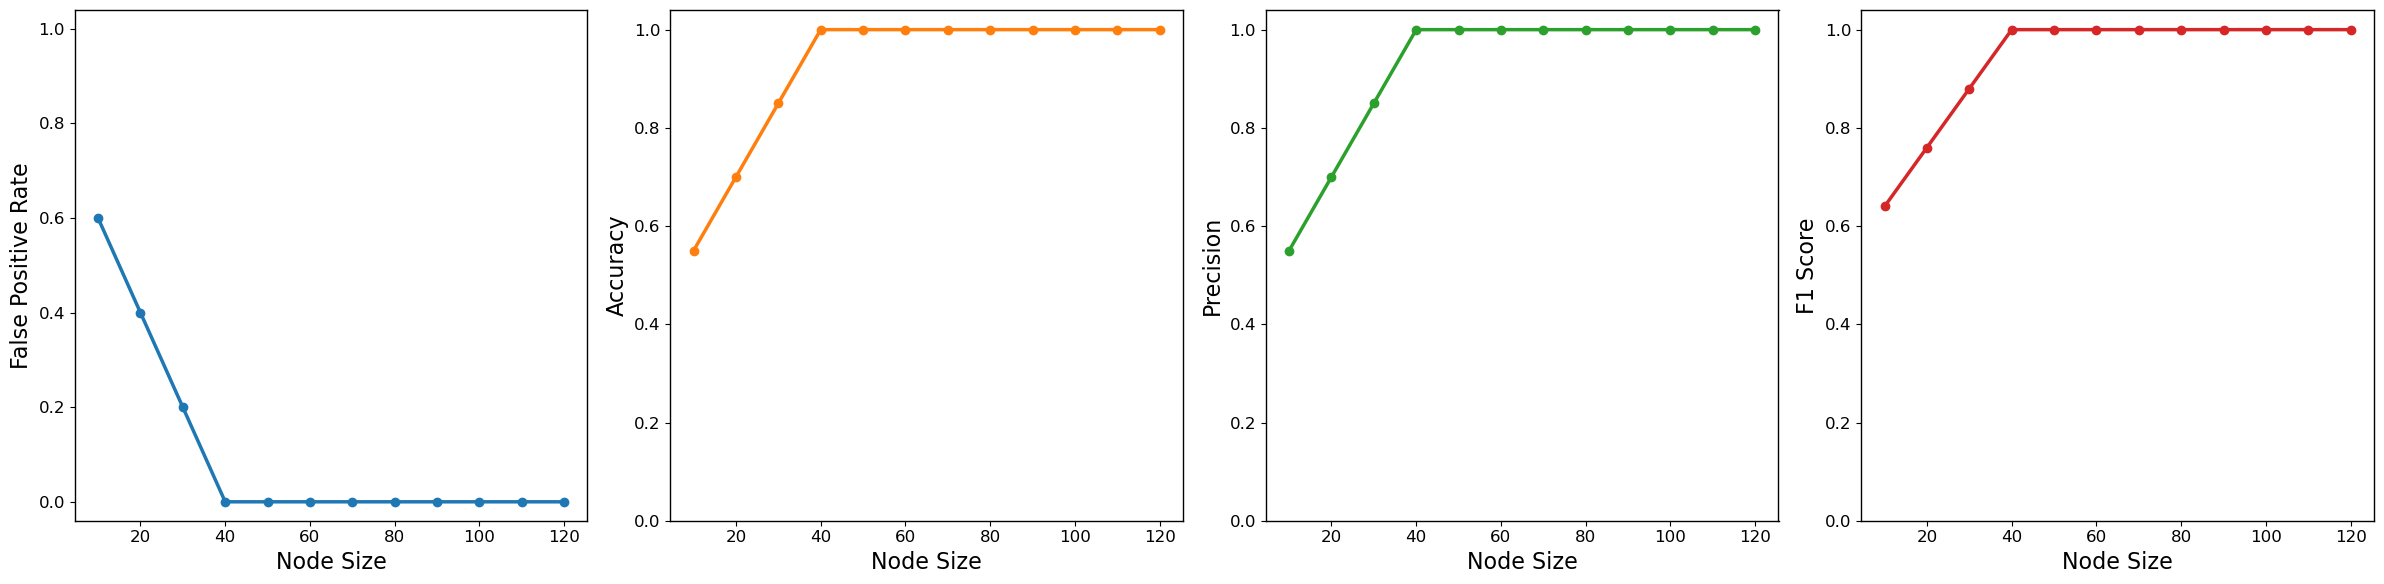

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set plot style
# plt.style.use('seaborn-v0_8')
plt.rcParams.update({
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'lines.linewidth': 2.5
})

# Read data
df = pd.read_csv('scenario1_variable_selection_metrics.csv')

# Calculate average metrics for each node size
avg_metrics = df.groupby('node_size')[['FPR', 'FNR', 
                                              'Accuracy', 'Precision', 'Recall', 'F1', 'AUC']].mean().reset_index()

# Create 1×4 subplots
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Subplot 1: False Positive Rate
axes[0].plot(avg_metrics['node_size'], avg_metrics['FPR'], marker='o', color='tab:blue')
axes[0].set_xlabel('Node Size')
axes[0].set_ylabel('False Positive Rate')
axes[0].set_ylim(-0.04, 1.04)
axes[0].grid(False)
axes[0].set_frame_on(True)
# Set black border for all spines
for spine in ['top', 'bottom', 'left', 'right']:
    axes[0].spines[spine].set_color('black')
    axes[0].spines[spine].set_linewidth(1.0)

# Subplot 2: Accuracy
axes[1].plot(avg_metrics['node_size'], avg_metrics['Accuracy'], marker='o', color='tab:orange')
axes[1].set_xlabel('Node Size')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.04)
axes[1].grid(False)
axes[1].set_frame_on(True)
# Set black border for all spines
for spine in ['top', 'bottom', 'left', 'right']:
    axes[1].spines[spine].set_color('black')
    axes[1].spines[spine].set_linewidth(1.0)

# Subplot 3: Precision
axes[2].plot(avg_metrics['node_size'], avg_metrics['Precision'], marker='o', color='tab:green')
axes[2].set_xlabel('Node Size')
axes[2].set_ylabel('Precision')
axes[2].set_ylim(0, 1.04)
axes[2].grid(False)
axes[2].set_frame_on(True)
# Set black border for all spines
for spine in ['top', 'bottom', 'left', 'right']:
    axes[2].spines[spine].set_color('black')
    axes[2].spines[spine].set_linewidth(1.0)

# Subplot 4: F1 Score
axes[3].plot(avg_metrics['node_size'], avg_metrics['F1'], marker='o', color='tab:red')
axes[3].set_xlabel('Node Size')
axes[3].set_ylabel('F1 Score')
axes[3].set_ylim(0, 1.04)
axes[3].grid(False)
axes[3].set_frame_on(True)
# Set black border for all spines
for spine in ['top', 'bottom', 'left', 'right']:
    axes[3].spines[spine].set_color('black')
    axes[3].spines[spine].set_linewidth(1.0)

plt.tight_layout()
plt.savefig('scenario1_variable_selection_performance.png', dpi=300, bbox_inches='tight')
plt.show()

In [71]:
########################################
# Simulation scenario 2: weak signal simulation
########################################

import numpy as np
import pandas as pd
import time
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
# from SMNR_func import generate_multiplex_data, cross_validate_SMNR, SMNR, SMNR_predict

def weak_signal_simulation(num_nodes, num_strong_signals, num_weak_signals, 
                              num_noises, strong_strengths, weak_strengths, 
                              n_replicates=5, n_folds=3, verbose=False):
    """
    Run weak signal scenario simulation experiment
    
    Parameters:
    num_nodes -- Number of nodes
    num_strong_signals -- Number of strong signal layers
    num_weak_signals -- Number of weak signal layers
    num_noises -- Number of noise layers
    strong_strengths -- List of strong signal strengths (length should be num_strong_signals)
    weak_strengths -- List of weak signal strengths (length should be num_weak_signals)
    n_replicates -- Number of replicates (default 5)
    n_folds -- Number of cross-validation folds (default 3)
    verbose -- Whether to print detailed information (default False)
    
    Returns:
    DataFrame containing results of all replicate experiments
    """
    # 1. Validate input parameters
    if len(strong_strengths) != num_strong_signals:
        raise ValueError(f"strong_strengths length ({len(strong_strengths)}) must equal num_strong_signals ({num_strong_signals})")
    
    if len(weak_strengths) != num_weak_signals:
        raise ValueError(f"weak_strengths length ({len(weak_strengths)}) must equal num_weak_signals ({num_weak_signals})")
    
    # 2. Create result storage structure
    results = pd.DataFrame()
    
    # 3. Construct theta vector
    # Signal layers: each signal layer has two parameters [strength, 0]
    theta = []
    for strength in strong_strengths:
        theta.append(strength)
        theta.append(0.0)
    for strength in weak_strengths:
        theta.append(strength)
        theta.append(0.0)
    # Noise layers: each noise layer has two parameters [0, 0]
    for _ in range(num_noises):
        theta.append(0.0)
        theta.append(0.0)
    
    # 4. Run replicate experiments
    for rep in range(n_replicates):
        if verbose:
            print(f"\n{'='*50}\nReplicate {rep+1}/{n_replicates} | Nodes: {num_nodes} | "
                  f"Strong signals: {num_strong_signals} | Weak signals: {num_weak_signals} | Noise: {num_noises}\n{'='*50}")
        
        # 4.1 Generate simulated data
        seed = 42 + num_nodes + rep
        data = generate_multiplex_data(
            num_nodes=num_nodes,
            num_signals=num_strong_signals+num_weak_signals, 
            num_noises=num_noises, 
            theta=theta,
            edge_factor=10,
            seed=seed,
            use_multiplex_threshold=500
        )
        
        # 4.2 Cross-validation to select optimal lambda and rho
        lambd_values = np.exp(np.linspace(np.log(0.1), np.log(100), 20))
        rho_values = np.exp(np.linspace(np.log(0.1), np.log(100), 20))
        
        cv_results = cross_validate_SMNR(
            data['R_list'], 
            data['A'], 
            data['xi'],
            lambd_values=lambd_values,
            rho_values=rho_values,
            directed=False,
            selfloops=False,
            n_folds=n_folds,
            seed=seed
        )
        
        best_lambda = cv_results['best_lambda']
        best_rho = cv_results['best_rho']
        
        # 4.3 Train model with optimal parameters
        model = SMNR(
            data['R_list'], 
            data['A'], 
            xi=data['xi'],
            lambd=best_lambda,
            rho=best_rho,
            directed=False,
            selfloops=False,
            verbose=False
        )
        
        # 4.4 Prediction and evaluation
        pred_adj = SMNR_predict(
            data['A'], 
            data['R_list'], 
            model['z'],
            directed=False,
            selfloops=False,
            method="approximate"
        )
        
        # Calculate prediction MSE (only non-zero positions)
        ix = mat2vec_ix(data['A'], directed=False, selfloops=False)
        true_values = data['A'][ix]
        pred_values = pred_adj[ix]
        mse = np.mean((true_values - pred_values) ** 2)
        
        # 4.5 Collect results
        result = {
            'node_size': num_nodes,
            'num_strong_signals': num_strong_signals,
            'num_weak_signals': num_weak_signals,
            'num_noises': num_noises,
            'replicate': rep + 1,
            'best_lambda': best_lambda,
            'best_rho': best_rho,
            'mse': mse,
            'true_theta': data['true_theta'],
            'estimated_theta': model['z'],
            'std_errors': model['std_errors'], 
            'p_values': model['p_values'], 
            'conf_intervals': model['conf_intervals'],
            'signal_mask': data['signal_mask']
        }
        
        results = pd.concat([results, pd.DataFrame([result])], ignore_index=True)
    
    return results

def analyze_weak_signal_results(results_df):
    """
    Analyze weak signal experiment results
    
    Parameters:
    results_df -- Result DataFrame returned by weak_signal_simulation
    
    Returns:
    DataFrame containing detailed analysis results
    """
    analysis_results = pd.DataFrame()
    
    for idx, row in results_df.iterrows():
        true_theta = np.array(row['true_theta'])
        est_theta = np.array(row['estimated_theta'])
        signal_mask = np.array(row['signal_mask'])
        
        # 1. Identify signal types
        # Strong signals: theta > 1.0
        strong_signals = (true_theta > 1.0) & signal_mask
        # Weak signals: 0 < theta <= 1.0
        weak_signals = (true_theta > 0) & (true_theta <= 1.0) & signal_mask
        # Noise: theta == 0
        noise = (true_theta == 0) | (~signal_mask)
        
        # 2. Binary classification evaluation (signal vs noise)
        true_labels = np.where((strong_signals | weak_signals), 1, 0)
        pred_labels = np.where(np.abs(est_theta) > 0.001, 1, 0)
        
        # Calculate confusion matrix
        tn, fp, fn, tp = confusion_matrix(true_labels, pred_labels).ravel()
        
        # Calculate classification metrics
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        
        # Calculate AUC
        auc = roc_auc_score(true_labels, np.abs(est_theta))
        
        # 3. Signal detection rate
        strong_detection_rate = np.mean(pred_labels[strong_signals] == 1) if np.any(strong_signals) else np.nan
        weak_detection_rate = np.mean(pred_labels[weak_signals] == 1) if np.any(weak_signals) else np.nan
        noise_false_rate = np.mean(pred_labels[noise] == 1) if np.any(noise) else np.nan
        
        # 4. Parameter estimation bias
        coef_bias = np.mean((est_theta - true_theta) ** 2)
        
        # 5. Collect analysis results
        analysis_row = {
            'node_size': row['node_size'],
            'num_strong_signals': row['num_strong_signals'],
            'num_weak_signals': row['num_weak_signals'],
            'num_noises': row['num_noises'],
            'replicate': row['replicate'],
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1_score,
            'fpr': fpr,
            'fnr': fnr,
            'auc': auc,
            'coef_bias': coef_bias,
            'strong_detection_rate': strong_detection_rate,
            'weak_detection_rate': weak_detection_rate,
            'noise_false_rate': noise_false_rate,
            'mse': row['mse']
        }
        
        analysis_results = pd.concat([analysis_results, pd.DataFrame([analysis_row])], ignore_index=True)
    
    return analysis_results

# =====================
# Scenario Run
# =====================

if __name__ == "__main__":
    # 1. Set experiment parameters
    scenarios = [
        # Setting 1: Small-scale network, few signals and noise
        {'num_nodes': 50, 'num_strong_signals': 10, 'num_weak_signals': 10, 'num_noises': 10,
         'strong_strengths': [i for i in range(2, 11 + 1, 1)], 
         'weak_strengths': [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55]},
        
        # Setting 2: Medium-scale network, more weak signals
        {'num_nodes': 100, 'num_strong_signals': 10, 'num_weak_signals': 20, 'num_noises': 20,
         'strong_strengths': [i for i in range(2, 11 + 1, 1)], 
         'weak_strengths': [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.00]},
        
        # Setting 3: Large-scale network, more noise
        {'num_nodes': 200, 'num_strong_signals': 20, 'num_weak_signals': 20, 'num_noises': 30,
         'strong_strengths': [1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, 10.5, 11], 
         'weak_strengths': [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.00]}
    ]
    
    # 2. Run all experiment scenarios
    all_results = pd.DataFrame()
    
    for scenario in scenarios:
        print(f"\n{'='*50}")
        print(f"Starting weak signal scenario simulation: Nodes={scenario['num_nodes']}, "
              f"Strong signals={scenario['num_strong_signals']}, "
              f"Weak signals={scenario['num_weak_signals']}, "
              f"Noise={scenario['num_noises']}")
        print('='*50)
        
        # Run simulation experiment
        results = weak_signal_simulation(
            num_nodes=scenario['num_nodes'],
            num_strong_signals=scenario['num_strong_signals'],
            num_weak_signals=scenario['num_weak_signals'],
            num_noises=scenario['num_noises'],
            strong_strengths=scenario['strong_strengths'],
            weak_strengths=scenario['weak_strengths'],
            n_replicates=5,
            verbose=True
        )
        
        # Analyze results
        analysis = analyze_weak_signal_results(results)
        
        # Save results
        results.to_csv(f"weak_signal_results_n{scenario['num_nodes']}.csv", index=False)
        analysis.to_csv(f"weak_signal_analysis_n{scenario['num_nodes']}.csv", index=False)
        
        # Aggregate all results
        all_results = pd.concat([all_results, analysis], ignore_index=True)
    
    # 3. Save final results
    all_results.to_csv("all_weak_signal_results.csv", index=False)
    summary.to_csv("weak_signal_summary.csv", index=False)
    
    print("\nWeak signal scenario simulation completed! Results saved to CSV files.")


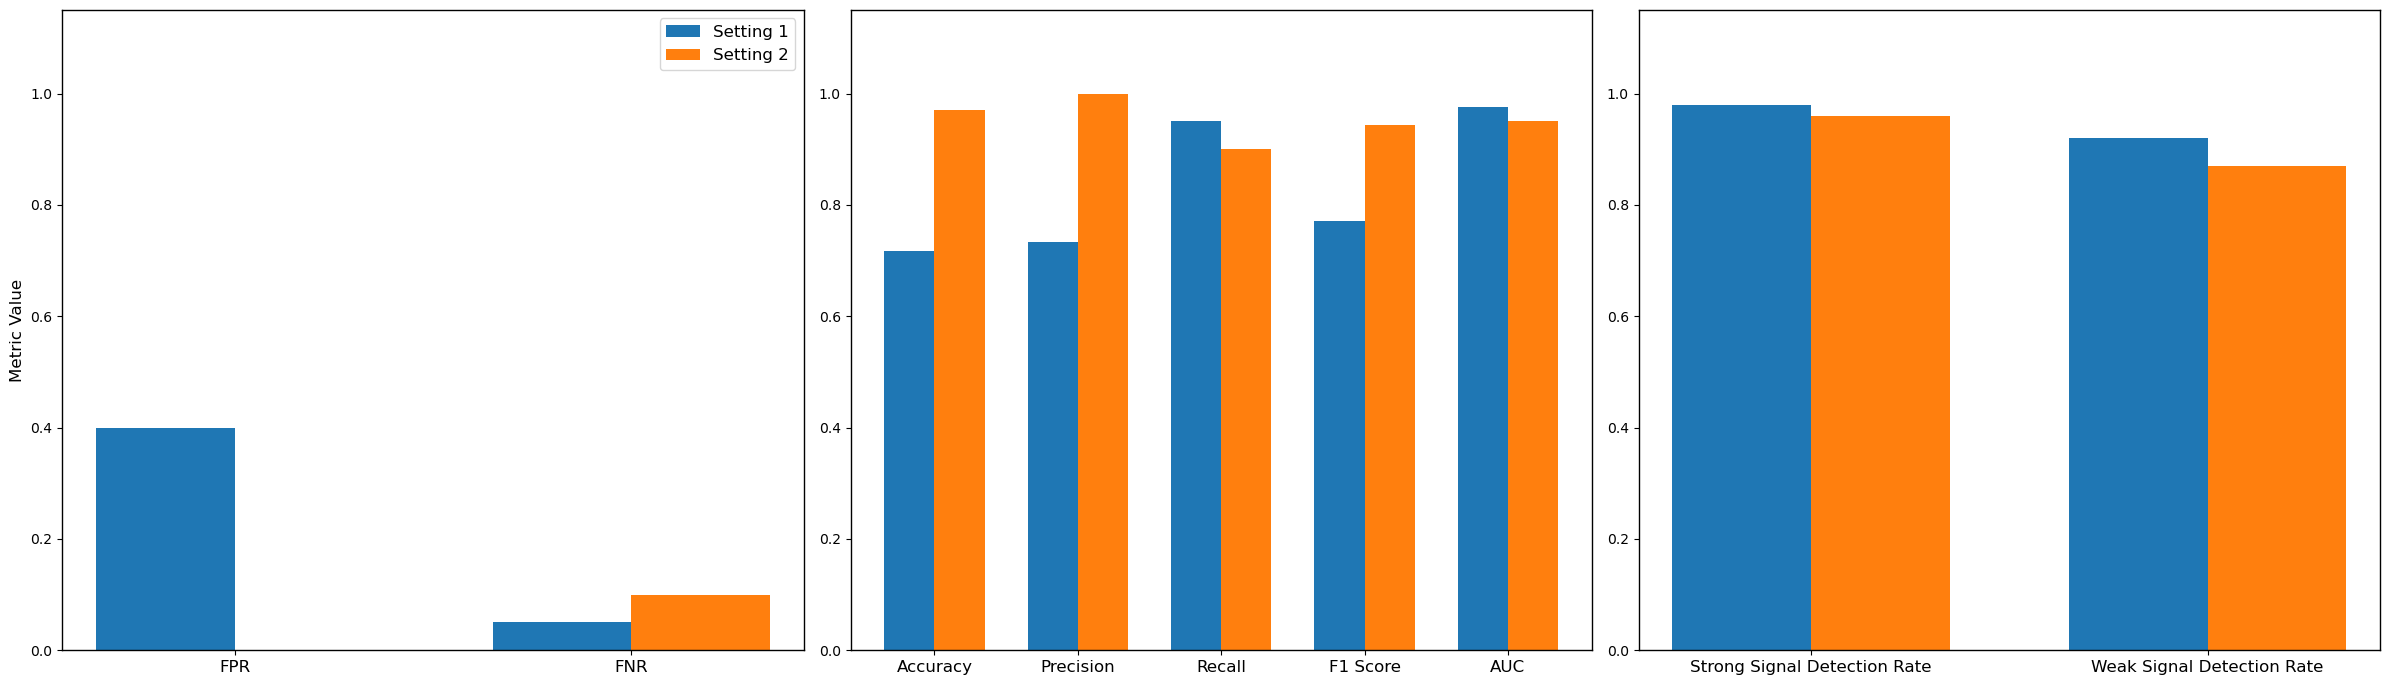

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def analyze_and_visualize(file_path1, file_path2):
    """
    Process simulation data from two settings and generate comparative visualization
    
    Parameters:
    file_path1 (str): Path to first CSV file (Setting 1)
    file_path2 (str): Path to second CSV file (Setting 2)
    """
    # Read data from both files
    df1 = pd.read_csv(file_path1)
    df2 = pd.read_csv(file_path2)
    
    # Add setting identifier
    df1['setting'] = 'Setting 1'
    df2['setting'] = 'Setting 2'
    
    # Combine data from both settings
    combined_df = pd.concat([df1, df2], ignore_index=True)
    
    # Group by setting and calculate mean metrics
    grouped = combined_df.groupby('setting').mean(numeric_only=True).reset_index()
    
    # Define metrics for each subplot
    subplot1_metrics = ['fpr', 'fnr']
    subplot2_metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'auc']
    subplot3_metrics = ['strong_detection_rate', 'weak_detection_rate']
    
    # Metric labels for visualization
    metric_labels = {
        'fpr': 'FPR',
        'fnr': 'FNR',
        'accuracy': 'Accuracy',
        'precision': 'Precision',
        'recall': 'Recall',
        'f1_score': 'F1 Score',
        'auc': 'AUC',
        'strong_detection_rate': 'Strong Signal Detection Rate',
        'weak_detection_rate': 'Weak Signal Detection Rate'
    }
    
    # Colors for different settings
    colors = ['#1f77b4', '#ff7f0e']  # Blue for Setting 1, Orange for Setting 2
    
    # Create figure with three subplots
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    
    # Plot settings
    bar_width = 0.35  # Width of each bar
    setting_labels = ['Setting 1', 'Setting 2']
    
    # Subplot 1: FPR and FNR
    ax1 = axes[0]
    x = np.arange(len(subplot1_metrics))  # x positions for metrics
    
    for i, setting in enumerate(setting_labels):
        setting_data = grouped[grouped['setting'] == setting]
        values = [setting_data[metric].values[0] for metric in subplot1_metrics]
        
        # Position bars for each setting side by side
        ax1.bar(x + i * bar_width, values, bar_width, 
                color=colors[i], label=setting)
        
        # Add value labels on top of bars
        # for j, v in enumerate(values):
        #     ax1.text(x[j] + i * bar_width, v + 0.01, 
        #              f'{v:.3f}', ha='center', va='bottom', fontsize=10)
    
    # Customize subplot 1
    # ax1.set_title('Error Rates', fontsize=16, fontweight='bold')
    ax1.set_xticks(x + bar_width / 2)
    ax1.set_xticklabels([metric_labels[m] for m in subplot1_metrics], fontsize=12)
    ax1.set_ylim(0, 1.15)
    ax1.set_ylabel('Metric Value', fontsize=12)
    # ax1.grid(axis='y', linestyle='--', alpha=0.7)
    ax1.legend(fontsize=12)
    
    # Apply frame with black border
    for spine in ax1.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)
    
    # Subplot 2: Accuracy, Precision, Recall, F1, AUC
    ax2 = axes[1]
    x = np.arange(len(subplot2_metrics))
    
    for i, setting in enumerate(setting_labels):
        setting_data = grouped[grouped['setting'] == setting]
        values = [setting_data[metric].values[0] for metric in subplot2_metrics]
        
        ax2.bar(x + i * bar_width, values, bar_width, 
                color=colors[i], label=setting)
        
        # for j, v in enumerate(values):
        #     ax2.text(x[j] + i * bar_width, v + 0.01, 
        #              f'{v:.3f}', ha='center', va='bottom', fontsize=10)
    
    # Customize subplot 2
    # ax2.set_title('Classification Metrics', fontsize=16, fontweight='bold')
    ax2.set_xticks(x + bar_width / 2)
    ax2.set_xticklabels([metric_labels[m] for m in subplot2_metrics], fontsize=12)
    ax2.set_ylim(0, 1.15)
    # ax2.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Apply frame with black border
    for spine in ax2.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)
    
    # Subplot 3: Detection Rates
    ax3 = axes[2]
    x = np.arange(len(subplot3_metrics))
    
    for i, setting in enumerate(setting_labels):
        setting_data = grouped[grouped['setting'] == setting]
        values = [setting_data[metric].values[0] for metric in subplot3_metrics]
        
        ax3.bar(x + i * bar_width, values, bar_width, 
                color=colors[i], label=setting)
        
        # for j, v in enumerate(values):
        #     ax3.text(x[j] + i * bar_width, v + 0.01, 
        #              f'{v:.3f}', ha='center', va='bottom', fontsize=10)
    
    # Customize subplot 3
    # ax3.set_title('Signal Detection Rates', fontsize=16, fontweight='bold')
    ax3.set_xticks(x + bar_width / 2)
    ax3.set_xticklabels([metric_labels[m] for m in subplot3_metrics], fontsize=12)
    ax3.set_ylim(0, 1.15)
    # ax3.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Apply frame with black border
    for spine in ax3.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)
    
    # Adjust layout and save figure
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)  # Adjust space for main title
    plt.savefig('weak_signal_comparative_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# Usage example
if __name__ == "__main__":
    # Replace with your actual file paths
    file_path1 = "weak_signal_analysis_n50.csv"
    file_path2 = "weak_signal_analysis_n100.csv"
    analyze_and_visualize(file_path1, file_path2)

In [13]:
########################################
# Simulation scenario 3 (scalability simulation): fixed signals and noises & fixed lambda=20 and rho=0.7, but varying node sizes to 1000
########################################

import numpy as np
import pandas as pd
import time
import psutil

# 1. set parameters
custom_theta = [3.0, 0, 2.0, 0, 1.5, 0, 0, 0, 0, 0, 0, 0]
node_sizes = [10, 30, 50, 70, 90, 120, 200, 300, 400, 500, 600, 700, 900, 1000]
num_replicates = 5  # repeat 5 times

# 2. block data scalability simulation
# result saving structure for block data
signal_structure = 'block'
results = {
    'scalability_metrics': pd.DataFrame(),
    'replicate_details': pd.DataFrame()
}

# the main scalability simulation loop for block data
for n in node_sizes:
    print(f"\n{'='*50}\nStarting scalability simulations for node size: {n} | signal structure: {signal_structure}\n{'='*50}")
    
    replicate_metrics = []  # save 5 times' repeating results of current node size
    
    for rep in range(num_replicates):
        print(f"Replicate {rep+1}/{num_replicates} for node size {n} | signal structure: {signal_structure}")
        
        # record the starting time and memory
        start_time = time.time()
        start_mem = psutil.Process().memory_info().rss / (1024 ** 2)  # MB
        
        # generate simulation block data with unique seed
        data_block = generate_multiplex_data(
            num_nodes=n,
            theta=custom_theta,
            edge_factor=10,
            signal_structure=signal_structure,
            seed=42 + n + rep  # unique random seed
        )
        
        # train SMNR with specific tuning parameter
        spec_lambda = 20
        spec_rho = 0.7
        model = SMNR(
            data_block['R_list'], 
            data_block['A'], 
            xi=data_block['xi'],
            lambd=spec_lambda,
            rho=spec_rho,
            tolerance=1e-6,
            max_iter=100,
            directed=False,
            selfloops=False,
            verbose=False
        )
        
        # record end time and memory usage
        end_time = time.time()
        end_mem = psutil.Process().memory_info().rss / (1024 ** 2)  # MB
        
        elapsed_time = end_time - start_time
        mem_usage = end_mem - start_mem
        
        # save detailed replicate information
        rep_detail = {
            'node_size': n,
            'replicate': rep + 1,
            'lambda': spec_lambda,
            'rho': spec_rho,
            'time_sec': elapsed_time,
            'mem_mb': mem_usage
        }
        results['replicate_details'] = pd.concat([
            results['replicate_details'],
            pd.DataFrame([rep_detail])
        ], ignore_index=True)
        
        replicate_metrics.append((elapsed_time, mem_usage))
        print(f"Completed replicate {rep+1} | Time: {elapsed_time:.2f}s | Mem: {mem_usage:.2f}MB")
    
    # calculate average metrics for this node size
    avg_time = np.mean([t for t, _ in replicate_metrics])
    avg_mem = np.mean([m for _, m in replicate_metrics])
    
    scal_metric = {
        'node_size': n,
        'lambda': spec_lambda,
        'rho': spec_rho,
        'avg_time_sec': avg_time,
        'avg_mem_mb': avg_mem,
        'min_time_sec': min([t for t, _ in replicate_metrics]),
        'max_time_sec': max([t for t, _ in replicate_metrics]),
        'min_mem_mb': min([m for _, m in replicate_metrics]),
        'max_mem_mb': max([m for _, m in replicate_metrics])
    }
    results['scalability_metrics'] = pd.concat([
        results['scalability_metrics'],
        pd.DataFrame([scal_metric])
    ], ignore_index=True)
    
    print(f"\nSummary for n={n} | signal structure: {signal_structure} | Avg Time: {avg_time:.2f}s | Avg Mem: {avg_mem:.2f}MB")

# save simulation results into CSV files
results['scalability_metrics'].to_csv(f'scenario4_scalability_metrics_avg_{signal_structure}.csv', index=False)
results['replicate_details'].to_csv(f'scenario4_replicate_details_{signal_structure}.csv', index=False)

print(f"\nScalability simulation for {signal_structure} completed! Results saved to CSV files.")
print(f" - Average metrics: scalability_metrics_avg_{signal_structure}.csv")
print(f" - Detailed replicate data: replicate_details_{signal_structure}.csv")


# 3. small-world data scalability simulation
# result saving structure for small-world data
signal_structure = 'small-world'
results = {
    'scalability_metrics': pd.DataFrame(),
    'replicate_details': pd.DataFrame()
}

# the main scalability simulation loop for small-world data
for n in node_sizes:
    print(f"\n{'='*50}\nStarting scalability simulations for node size: {n} | signal structure: {signal_structure}\n{'='*50}")
    
    replicate_metrics = []  # save 5 times' repeating results of current node size
    
    for rep in range(num_replicates):
        print(f"Replicate {rep+1}/{num_replicates} for node size {n} | signal structure: {signal_structure}")
        
        # record the starting time and memory
        start_time = time.time()
        start_mem = psutil.Process().memory_info().rss / (1024 ** 2)  # MB
        
        # generate simulation small-world data with unique seed
        data_smallworld = generate_multiplex_data(
            num_nodes=n,
            theta=custom_theta,
            edge_factor=10,
            signal_structure=signal_structure,
            small_world_k=4,
            small_world_p=0.15,
            seed=42 + n + rep  # unique random seed
        )
        
        # train SMNR with specific tuning parameter
        spec_lambda = 20
        spec_rho = 0.7
        model = SMNR(
            data_smallworld['R_list'], 
            data_smallworld['A'], 
            xi=data_smallworld['xi'],
            lambd=spec_lambda,
            rho=spec_rho,
            tolerance=1e-6,
            max_iter=100,
            directed=False,
            selfloops=False,
            verbose=False
        )
        
        # record end time and memory usage
        end_time = time.time()
        end_mem = psutil.Process().memory_info().rss / (1024 ** 2)  # MB
        
        elapsed_time = end_time - start_time
        mem_usage = end_mem - start_mem
        
        # save detailed replicate information
        rep_detail = {
            'node_size': n,
            'replicate': rep + 1,
            'lambda': spec_lambda,
            'rho': spec_rho,
            'time_sec': elapsed_time,
            'mem_mb': mem_usage
        }
        results['replicate_details'] = pd.concat([
            results['replicate_details'],
            pd.DataFrame([rep_detail])
        ], ignore_index=True)
        
        replicate_metrics.append((elapsed_time, mem_usage))
        print(f"Completed replicate {rep+1} | Time: {elapsed_time:.2f}s | Mem: {mem_usage:.2f}MB")
    
    # calculate average metrics for this node size
    avg_time = np.mean([t for t, _ in replicate_metrics])
    avg_mem = np.mean([m for _, m in replicate_metrics])
    
    scal_metric = {
        'node_size': n,
        'lambda': spec_lambda,
        'rho': spec_rho,
        'avg_time_sec': avg_time,
        'avg_mem_mb': avg_mem,
        'min_time_sec': min([t for t, _ in replicate_metrics]),
        'max_time_sec': max([t for t, _ in replicate_metrics]),
        'min_mem_mb': min([m for _, m in replicate_metrics]),
        'max_mem_mb': max([m for _, m in replicate_metrics])
    }
    results['scalability_metrics'] = pd.concat([
        results['scalability_metrics'],
        pd.DataFrame([scal_metric])
    ], ignore_index=True)
    
    print(f"\nSummary for n={n} | signal structure: {signal_structure} | Avg Time: {avg_time:.2f}s | Avg Mem: {avg_mem:.2f}MB")

# save simulation results into CSV files
results['scalability_metrics'].to_csv(f'scenario4_scalability_metrics_avg_{signal_structure}.csv', index=False)
results['replicate_details'].to_csv(f'scenario4_replicate_details_{signal_structure}.csv', index=False)

print(f"\nScalability simulation for {signal_structure} completed! Results saved to CSV files.")
print(f" - Average metrics: scalability_metrics_avg_{signal_structure}.csv")
print(f" - Detailed replicate data: replicate_details_{signal_structure}.csv")


# 4. scale-free data scalability simulation
# result saving structure for scale-free data
signal_structure = 'scale-free'
results = {
    'scalability_metrics': pd.DataFrame(),
    'replicate_details': pd.DataFrame()
}

# the main scalability simulation loop for scale-free data
for n in node_sizes:
    print(f"\n{'='*50}\nStarting scalability simulations for node size: {n} | signal structure: {signal_structure}\n{'='*50}")
    
    replicate_metrics = []  # save 5 times' repeating results of current node size
    
    for rep in range(num_replicates):
        print(f"Replicate {rep+1}/{num_replicates} for node size {n} | signal structure: {signal_structure}")
        
        # record the starting time and memory
        start_time = time.time()
        start_mem = psutil.Process().memory_info().rss / (1024 ** 2)  # MB
        
        # generate simulation scale-free data with unique seed
        data_scalefree = generate_multiplex_data(
            num_nodes=n,
            theta=custom_theta,
            edge_factor=10,
            signal_structure=signal_structure,
            scale_free_m=2,
            seed=42 + n + rep  # unique random seed
        )
        
        # train SMNR with specific tuning parameter
        spec_lambda = 20
        spec_rho = 0.7
        model = SMNR(
            data_scalefree['R_list'], 
            data_scalefree['A'], 
            xi=data_scalefree['xi'],
            lambd=spec_lambda,
            rho=spec_rho,
            tolerance=1e-6,
            max_iter=100,
            directed=False,
            selfloops=False,
            verbose=False
        )
        
        # record end time and memory usage
        end_time = time.time()
        end_mem = psutil.Process().memory_info().rss / (1024 ** 2)  # MB
        
        elapsed_time = end_time - start_time
        mem_usage = end_mem - start_mem
        
        # save detailed replicate information
        rep_detail = {
            'node_size': n,
            'replicate': rep + 1,
            'lambda': spec_lambda,
            'rho': spec_rho,
            'time_sec': elapsed_time,
            'mem_mb': mem_usage
        }
        results['replicate_details'] = pd.concat([
            results['replicate_details'],
            pd.DataFrame([rep_detail])
        ], ignore_index=True)
        
        replicate_metrics.append((elapsed_time, mem_usage))
        print(f"Completed replicate {rep+1} | Time: {elapsed_time:.2f}s | Mem: {mem_usage:.2f}MB")
    
    # calculate average metrics for this node size
    avg_time = np.mean([t for t, _ in replicate_metrics])
    avg_mem = np.mean([m for _, m in replicate_metrics])
    
    scal_metric = {
        'node_size': n,
        'lambda': spec_lambda,
        'rho': spec_rho,
        'avg_time_sec': avg_time,
        'avg_mem_mb': avg_mem,
        'min_time_sec': min([t for t, _ in replicate_metrics]),
        'max_time_sec': max([t for t, _ in replicate_metrics]),
        'min_mem_mb': min([m for _, m in replicate_metrics]),
        'max_mem_mb': max([m for _, m in replicate_metrics])
    }
    results['scalability_metrics'] = pd.concat([
        results['scalability_metrics'],
        pd.DataFrame([scal_metric])
    ], ignore_index=True)
    
    print(f"\nSummary for n={n} | signal structure: {signal_structure} | Avg Time: {avg_time:.2f}s | Avg Mem: {avg_mem:.2f}MB")

# save simulation results into CSV files
results['scalability_metrics'].to_csv(f'scenario4_scalability_metrics_avg_{signal_structure}.csv', index=False)
results['replicate_details'].to_csv(f'scenario4_replicate_details_{signal_structure}.csv', index=False)

print(f"\nScalability simulation for {signal_structure} completed! Results saved to CSV files.")
print(f" - Average metrics: scalability_metrics_avg_{signal_structure}.csv")
print(f" - Detailed replicate data: replicate_details_{signal_structure}.csv")


# 5. mixed data scalability simulation
# result saving structure for mixed data
signal_structure = 'mixed'
results = {
    'scalability_metrics': pd.DataFrame(),
    'replicate_details': pd.DataFrame()
}

# the main scalability simulation loop for mixed data
for n in node_sizes:
    print(f"\n{'='*50}\nStarting scalability simulations for node size: {n} | signal structure: {signal_structure}\n{'='*50}")
    
    replicate_metrics = []  # save 5 times' repeating results of current node size
    
    for rep in range(num_replicates):
        print(f"Replicate {rep+1}/{num_replicates} for node size {n} | signal structure: {signal_structure}")
        
        # record the starting time and memory
        start_time = time.time()
        start_mem = psutil.Process().memory_info().rss / (1024 ** 2)  # MB
        
        # generate simulation mixed data with unique seed
        data_mixed = generate_multiplex_data(
            num_nodes=n,
            theta=custom_theta,
            edge_factor=10,
            signal_structure=['block', 'small-world', 'scale-free'],
            scale_free_m=2,
            seed=42 + n + rep  # unique random seed
        )
        
        # train SMNR with specific tuning parameter
        spec_lambda = 20
        spec_rho = 0.7
        model = SMNR(
            data_mixed['R_list'], 
            data_mixed['A'], 
            xi=data_mixed['xi'],
            lambd=spec_lambda,
            rho=spec_rho,
            tolerance=1e-6,
            max_iter=100,
            directed=False,
            selfloops=False,
            verbose=False
        )
        
        # record end time and memory usage
        end_time = time.time()
        end_mem = psutil.Process().memory_info().rss / (1024 ** 2)  # MB
        
        elapsed_time = end_time - start_time
        mem_usage = end_mem - start_mem
        
        # save detailed replicate information
        rep_detail = {
            'node_size': n,
            'replicate': rep + 1,
            'lambda': spec_lambda,
            'rho': spec_rho,
            'time_sec': elapsed_time,
            'mem_mb': mem_usage
        }
        results['replicate_details'] = pd.concat([
            results['replicate_details'],
            pd.DataFrame([rep_detail])
        ], ignore_index=True)
        
        replicate_metrics.append((elapsed_time, mem_usage))
        print(f"Completed replicate {rep+1} | Time: {elapsed_time:.2f}s | Mem: {mem_usage:.2f}MB")
    
    # calculate average metrics for this node size
    avg_time = np.mean([t for t, _ in replicate_metrics])
    avg_mem = np.mean([m for _, m in replicate_metrics])
    
    scal_metric = {
        'node_size': n,
        'lambda': spec_lambda,
        'rho': spec_rho,
        'avg_time_sec': avg_time,
        'avg_mem_mb': avg_mem,
        'min_time_sec': min([t for t, _ in replicate_metrics]),
        'max_time_sec': max([t for t, _ in replicate_metrics]),
        'min_mem_mb': min([m for _, m in replicate_metrics]),
        'max_mem_mb': max([m for _, m in replicate_metrics])
    }
    results['scalability_metrics'] = pd.concat([
        results['scalability_metrics'],
        pd.DataFrame([scal_metric])
    ], ignore_index=True)
    
    print(f"\nSummary for n={n} | signal structure: {signal_structure} | Avg Time: {avg_time:.2f}s | Avg Mem: {avg_mem:.2f}MB")

# save simulation results into CSV files
results['scalability_metrics'].to_csv(f'scenario4_scalability_metrics_avg_{signal_structure}.csv', index=False)
results['replicate_details'].to_csv(f'scenario4_replicate_details_{signal_structure}.csv', index=False)

print(f"\nScalability simulation for {signal_structure} completed! Results saved to CSV files.")
print(f" - Average metrics: scalability_metrics_avg_{signal_structure}.csv")
print(f" - Detailed replicate data: replicate_details_{signal_structure}.csv")



Starting scalability simulations for node size: 10 | signal structure: block
Replicate 1/5 for node size 10 | signal structure: block


C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:279: RuntimeWarning: overflow encountered in multiply
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:283: RuntimeWarning: invalid value encountered in divide
  p_norm = p / p.sum()
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:286: RuntimeWarning: divide by zero encountered in log
  log_lik = np.sum(A_flat * np.log(p_norm))
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:286: RuntimeWarning: invalid value encountered in multiply
  log_lik = np.sum(A_flat * np.log(p_norm))


Completed replicate 1 | Time: 0.44s | Mem: 1.83MB
Replicate 2/5 for node size 10 | signal structure: block
Completed replicate 2 | Time: 0.07s | Mem: 0.01MB
Replicate 3/5 for node size 10 | signal structure: block
Completed replicate 3 | Time: 0.07s | Mem: 0.02MB
Replicate 4/5 for node size 10 | signal structure: block
Completed replicate 4 | Time: 0.07s | Mem: 0.00MB
Replicate 5/5 for node size 10 | signal structure: block
Completed replicate 5 | Time: 0.07s | Mem: 0.01MB

Summary for n=10 | signal structure: block | Avg Time: 0.14s | Avg Mem: 0.37MB

Starting scalability simulations for node size: 30 | signal structure: block
Replicate 1/5 for node size 30 | signal structure: block
Completed replicate 1 | Time: 0.20s | Mem: 0.18MB
Replicate 2/5 for node size 30 | signal structure: block
Completed replicate 2 | Time: 0.22s | Mem: 0.12MB
Replicate 3/5 for node size 30 | signal structure: block
Completed replicate 3 | Time: 0.19s | Mem: 0.00MB
Replicate 4/5 for node size 30 | signal str

C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:282: RuntimeWarning: overflow encountered in multiply
  p = xi_flat * product


Completed replicate 1 | Time: 0.18s | Mem: 0.10MB
Replicate 2/5 for node size 50 | signal structure: block
Completed replicate 2 | Time: 0.16s | Mem: 0.22MB
Replicate 3/5 for node size 50 | signal structure: block
Completed replicate 3 | Time: 0.18s | Mem: 0.00MB
Replicate 4/5 for node size 50 | signal structure: block
Completed replicate 4 | Time: 0.17s | Mem: 0.00MB
Replicate 5/5 for node size 50 | signal structure: block
Completed replicate 5 | Time: 0.17s | Mem: 0.00MB

Summary for n=50 | signal structure: block | Avg Time: 0.17s | Avg Mem: 0.06MB

Starting scalability simulations for node size: 70 | signal structure: block
Replicate 1/5 for node size 70 | signal structure: block
Completed replicate 1 | Time: 0.28s | Mem: 0.21MB
Replicate 2/5 for node size 70 | signal structure: block
Completed replicate 2 | Time: 0.28s | Mem: 0.26MB
Replicate 3/5 for node size 70 | signal structure: block
Completed replicate 3 | Time: 0.28s | Mem: 0.04MB
Replicate 4/5 for node size 70 | signal str

...

Completed replicate 2 | Time: 11.54s | Mem: 0.42MB
Replicate 3/5 for node size 500 | signal structure: scale-free
Completed replicate 3 | Time: 11.43s | Mem: 0.41MB
Replicate 4/5 for node size 500 | signal structure: scale-free
Completed replicate 4 | Time: 11.44s | Mem: 0.15MB
Replicate 5/5 for node size 500 | signal structure: scale-free
Completed replicate 5 | Time: 11.50s | Mem: 0.28MB

Summary for n=500 | signal structure: scale-free | Avg Time: 11.48s | Avg Mem: 2.57MB

Starting scalability simulations for node size: 600 | signal structure: scale-free
Replicate 1/5 for node size 600 | signal structure: scale-free
Completed replicate 1 | Time: 21.55s | Mem: 16.21MB
Replicate 2/5 for node size 600 | signal structure: scale-free
Completed replicate 2 | Time: 21.60s | Mem: 0.48MB
Replicate 3/5 for node size 600 | signal structure: scale-free
Completed replicate 3 | Time: 21.68s | Mem: 0.02MB
Replicate 4/5 for node size 600 | signal structure: scale-free
Completed replicate 4 | Time: 

C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:279: RuntimeWarning: overflow encountered in multiply
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:283: RuntimeWarning: invalid value encountered in divide
  p_norm = p / p.sum()
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:286: RuntimeWarning: divide by zero encountered in log
  log_lik = np.sum(A_flat * np.log(p_norm))
C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:286: RuntimeWarning: invalid value encountered in multiply
  log_lik = np.sum(A_flat * np.log(p_norm))


Completed replicate 3 | Time: 0.08s | Mem: 0.00MB
Replicate 4/5 for node size 10 | signal structure: mixed
Completed replicate 4 | Time: 0.07s | Mem: 0.00MB
Replicate 5/5 for node size 10 | signal structure: mixed
Completed replicate 5 | Time: 0.06s | Mem: 0.00MB

Summary for n=10 | signal structure: mixed | Avg Time: 0.07s | Avg Mem: -1.53MB

Starting scalability simulations for node size: 30 | signal structure: mixed
Replicate 1/5 for node size 30 | signal structure: mixed


C:\Users\hensh\AppData\Local\Temp\ipykernel_11028\173039272.py:282: RuntimeWarning: overflow encountered in multiply
  p = xi_flat * product


Completed replicate 1 | Time: 0.19s | Mem: 0.00MB
Replicate 2/5 for node size 30 | signal structure: mixed
Completed replicate 2 | Time: 0.19s | Mem: 0.00MB
Replicate 3/5 for node size 30 | signal structure: mixed
Completed replicate 3 | Time: 0.19s | Mem: 0.00MB
Replicate 4/5 for node size 30 | signal structure: mixed
Completed replicate 4 | Time: 0.18s | Mem: 0.00MB
Replicate 5/5 for node size 30 | signal structure: mixed
Completed replicate 5 | Time: 0.19s | Mem: 0.00MB

Summary for n=30 | signal structure: mixed | Avg Time: 0.19s | Avg Mem: 0.00MB

Starting scalability simulations for node size: 50 | signal structure: mixed
Replicate 1/5 for node size 50 | signal structure: mixed
Completed replicate 1 | Time: 0.18s | Mem: 0.09MB
Replicate 2/5 for node size 50 | signal structure: mixed
Completed replicate 2 | Time: 0.15s | Mem: 0.21MB
Replicate 3/5 for node size 50 | signal structure: mixed
Completed replicate 3 | Time: 0.18s | Mem: 0.00MB
Replicate 4/5 for node size 50 | signal str

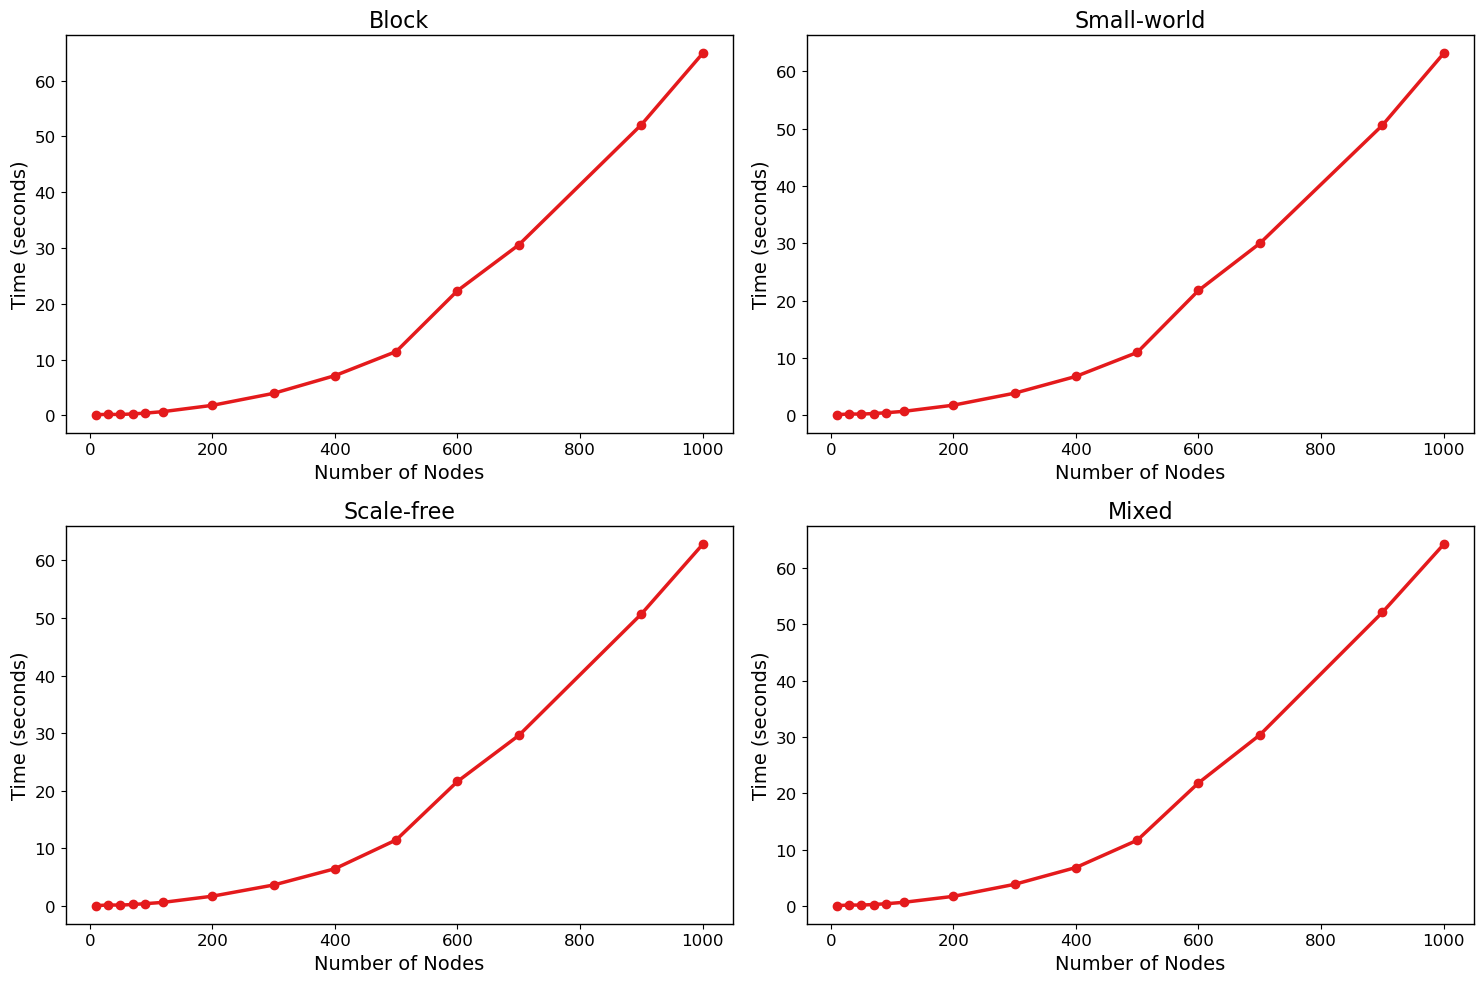

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.gridspec import GridSpec

# set drawing style
# sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12
})

def plot_scalability(scalability_df1, scalability_df2, scalability_df3, scalability_df4):
    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(2, 2, figure=fig)
    
    # 1. time scalability graph for block data
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(scalability_df1['node_size'], scalability_df1['avg_time_sec'], 'o-', color='#E41A1C', linewidth=2.5)
    ax1.set_xlabel('Number of Nodes')
    ax1.set_ylabel('Time (seconds)')
    ax1.set_title('Block')
    ax1.grid(False)
    ax1.set_frame_on(True)
    # Set black border for all spines
    for spine in ['top', 'bottom', 'left', 'right']:
        ax1.spines[spine].set_color('black')
        ax1.spines[spine].set_linewidth(1.0)
    
    # 2. time scalability graph for small-world data
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(scalability_df2['node_size'], scalability_df2['avg_time_sec'], 'o-', color='#E41A1C', linewidth=2.5)
    ax2.set_xlabel('Number of Nodes')
    ax2.set_ylabel('Time (seconds)')
    ax2.set_title('Small-world')
    ax2.grid(False)
    ax2.set_frame_on(True)
    # Set black border for all spines
    for spine in ['top', 'bottom', 'left', 'right']:
        ax2.spines[spine].set_color('black')
        ax2.spines[spine].set_linewidth(1.0)

    # 3. time scalability graph for scale-free data
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(scalability_df3['node_size'], scalability_df3['avg_time_sec'], 'o-', color='#E41A1C', linewidth=2.5)
    ax3.set_xlabel('Number of Nodes')
    ax3.set_ylabel('Time (seconds)')
    ax3.set_title('Scale-free')
    ax3.grid(False)
    ax3.set_frame_on(True)
    # Set black border for all spines
    for spine in ['top', 'bottom', 'left', 'right']:
        ax3.spines[spine].set_color('black')
        ax3.spines[spine].set_linewidth(1.0)
    
    # 4. time scalability graph for mixed data
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(scalability_df4['node_size'], scalability_df4['avg_time_sec'], 'o-', color='#E41A1C', linewidth=2.5)
    ax4.set_xlabel('Number of Nodes')
    ax4.set_ylabel('Time (seconds)')
    ax4.set_title('Mixed')
    ax4.grid(False)
    ax4.set_frame_on(True)
    # Set black border for all spines
    for spine in ['top', 'bottom', 'left', 'right']:
        ax4.spines[spine].set_color('black')
        ax4.spines[spine].set_linewidth(1.0)
    
    plt.tight_layout()
    plt.savefig('scenario4_scalability_analysis.png', dpi=300)
    plt.show()
    plt.close()

# load data
block_scal_df = pd.read_csv('scenario4_scalability_metrics_avg_block.csv')
smallworld_scal_df = pd.read_csv('scenario4_scalability_metrics_avg_small-world.csv')
scalefree_scal_df = pd.read_csv('scenario4_scalability_metrics_avg_scale-free.csv')
mixed_scal_df = pd.read_csv('scenario4_scalability_metrics_avg_mixed.csv')

# build scalability vilualization
plot_scalability(block_scal_df, smallworld_scal_df, scalefree_scal_df, mixed_scal_df)


C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:283: RuntimeWarning: invalid value encountered in divide
  p_norm = p / p.sum()


Starting 400x5=2000 CV evaluations


C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:283: RuntimeWarning: invalid value encountered in divide
  p_norm = p / p.sum()
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:283: RuntimeWarning: invalid value encou

(1/400) λ=0.1000, ρ=0.1000, Val MSE=0.2029


C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:283: RuntimeWarning: invalid value encountered in divide
  p_norm = p / p.sum()
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:283: RuntimeWarning: invalid value encou

...

(399/400) λ=20.0000, ρ=15.1329, Val MSE=0.1938


C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarni

(400/400) λ=20.0000, ρ=20.0000, Val MSE=0.1741

Training final model with λ=1.6258, ρ=0.1322
Iter 1: Obj=nan, Diff=0.402090
Iter 2: Obj=2969.1727, Diff=0.460925
Iter 3: Obj=2916.2410, Diff=0.186470
Iter 4: Obj=2878.6640, Diff=0.145757
Iter 5: Obj=2850.3985, Diff=0.119271
Iter 6: Obj=2828.2731, Diff=0.100632
Iter 7: Obj=2810.4359, Diff=0.086805
Iter 8: Obj=2795.7236, Diff=0.076150
Iter 9: Obj=2783.3645, Diff=0.067697
Iter 10: Obj=2772.8252, Diff=0.060834
Iter 11: Obj=2763.7240, Diff=0.055156
Iter 12: Obj=2755.7801, Diff=0.050387
Iter 13: Obj=2748.7822, Diff=0.046327
Iter 14: Obj=2742.5681, Diff=0.042832
Iter 15: Obj=2737.0110, Diff=0.039793
Iter 16: Obj=2732.0102, Diff=0.037129
Iter 17: Obj=2727.4851, Diff=0.034775
Iter 18: Obj=2723.3698, Diff=0.032681
Iter 19: Obj=2719.6103, Diff=0.030808
Iter 20: Obj=2716.1618, Diff=0.029122
Iter 21: Obj=2712.9866, Diff=0.027598
Iter 22: Obj=2710.0532, Diff=0.026214
Iter 23: Obj=2707.3346, Diff=0.024952
Iter 24: Obj=2704.8077, Diff=0.023797
Iter 25: O

C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:283: RuntimeWarning: invalid value encountered in divide
  p_norm = p / p.sum()


Iter 174: Obj=2646.5690, Diff=0.002207
Iter 175: Obj=2646.5108, Diff=0.002190
Iter 176: Obj=2646.4532, Diff=0.002174
Iter 177: Obj=2646.3963, Diff=0.002158
Iter 178: Obj=2646.3400, Diff=0.002142
Iter 179: Obj=2646.2844, Diff=0.002127
Iter 180: Obj=2646.2295, Diff=0.002111
Iter 181: Obj=2646.1752, Diff=0.002096
Iter 182: Obj=2646.1215, Diff=0.002081
Iter 183: Obj=2646.0685, Diff=0.002066
Iter 184: Obj=2646.0160, Diff=0.002051
Iter 185: Obj=2645.9642, Diff=0.002036
Iter 186: Obj=2645.9129, Diff=0.002022
Iter 187: Obj=2645.8623, Diff=0.002008
Iter 188: Obj=2645.8122, Diff=0.001994
Iter 189: Obj=2645.7626, Diff=0.001980
Iter 190: Obj=2645.7136, Diff=0.001966
Iter 191: Obj=2645.6652, Diff=0.001953
Iter 192: Obj=2645.6173, Diff=0.001939
Iter 193: Obj=2645.5699, Diff=0.001926
Iter 194: Obj=2645.5230, Diff=0.001913
Iter 195: Obj=2645.4766, Diff=0.001900
Iter 196: Obj=2645.4308, Diff=0.001887
Iter 197: Obj=2645.3854, Diff=0.001874
Iter 198: Obj=2645.3405, Diff=0.001862
Iter 199: Obj=2645.2961, 

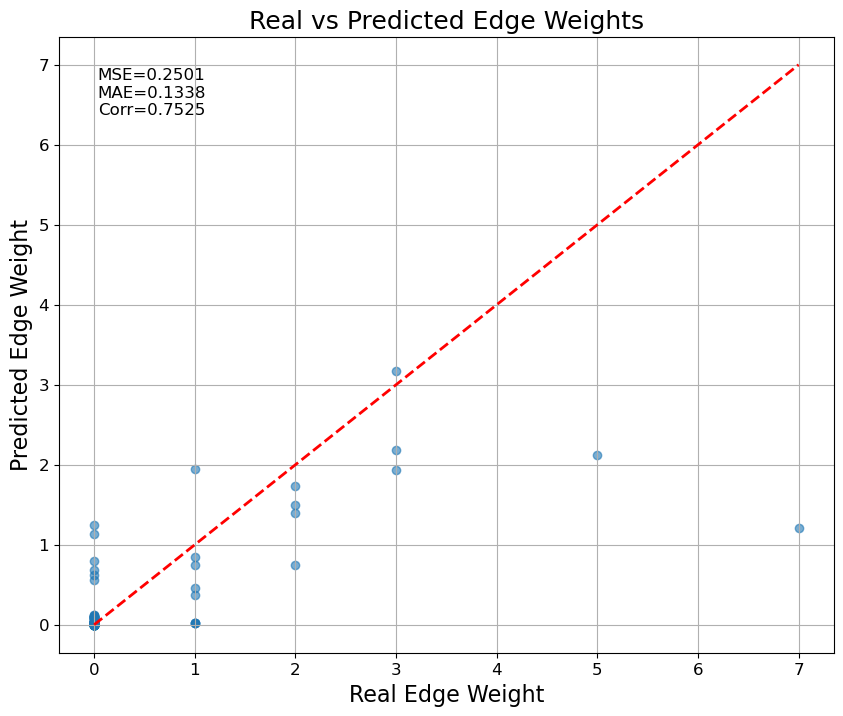

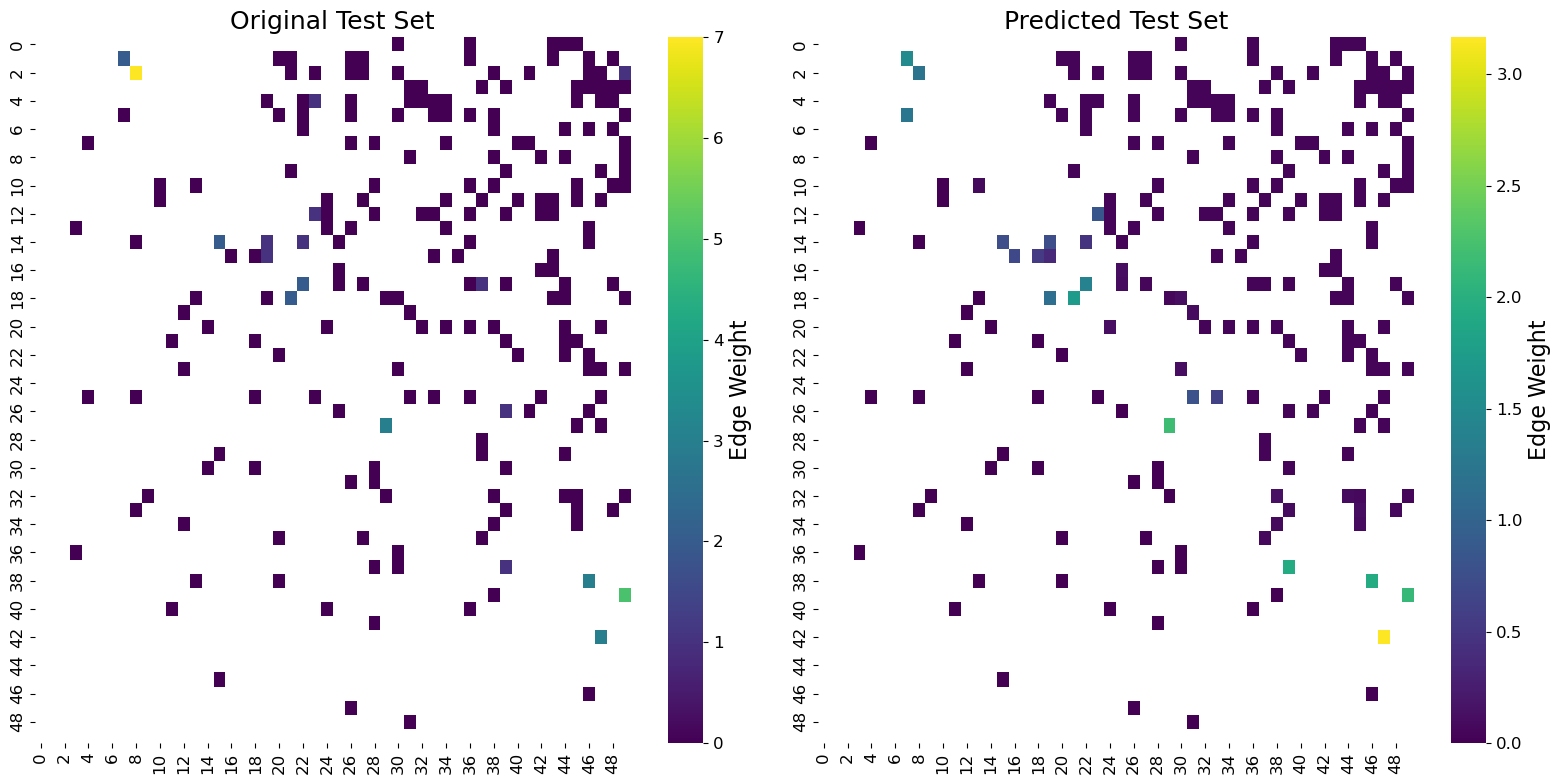

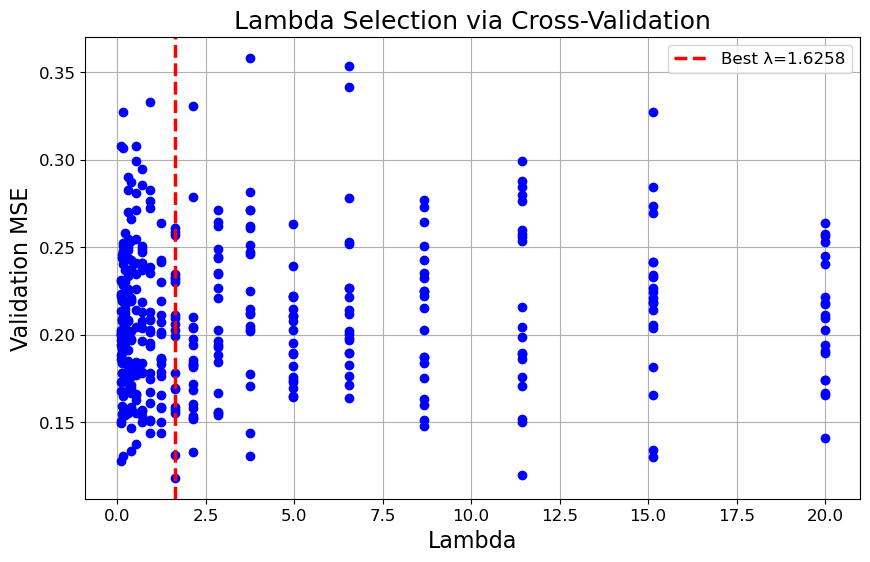

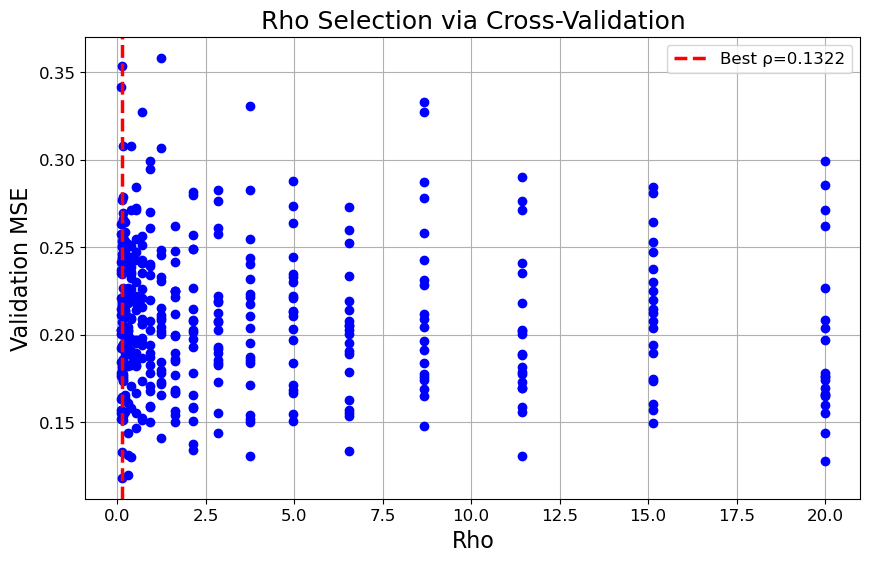

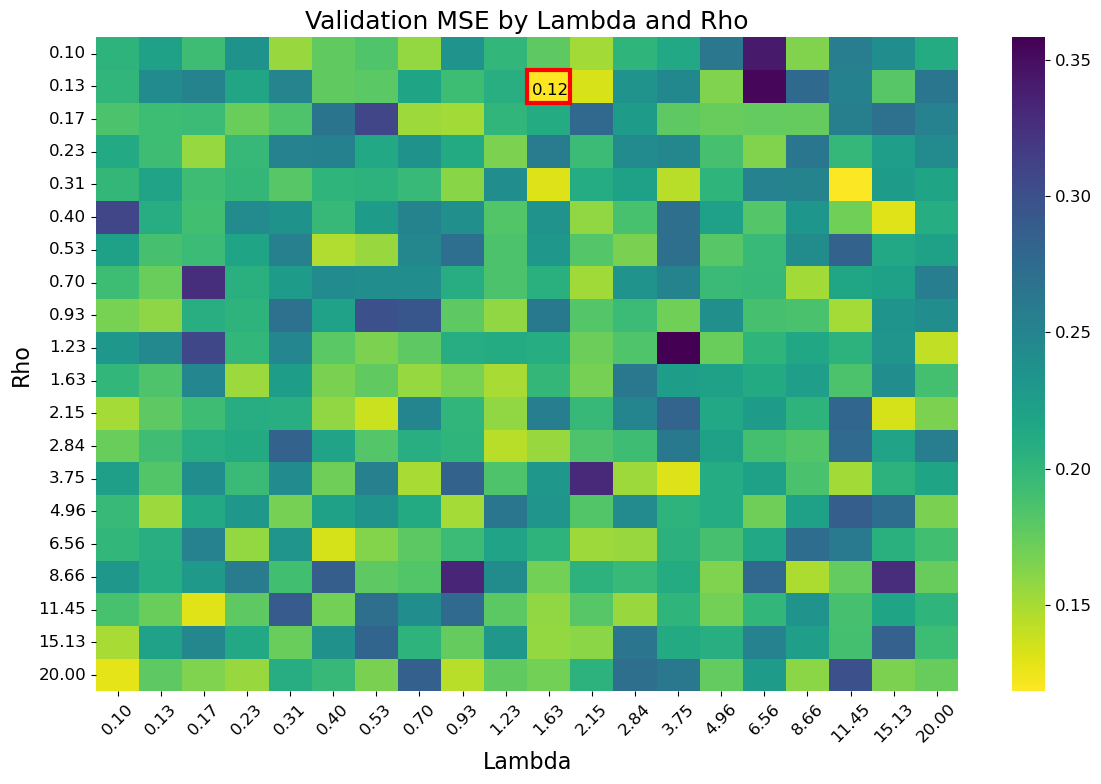

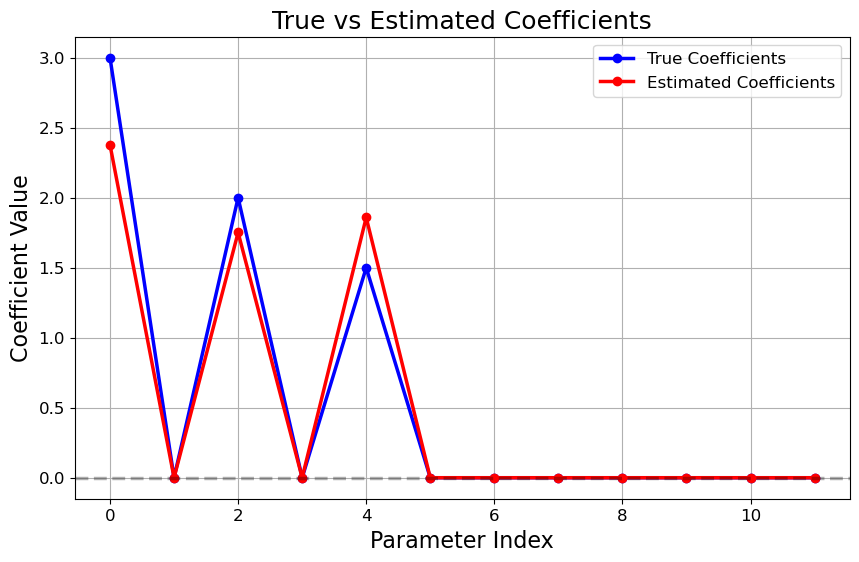

  theta = 2.3777 ± 0.2922 ***
  p-value = 0.0000
  95% CI = [1.8049, 2.9505]
  theta = 0.0000 ± 2.7507 
  p-value = 1.0000
  95% CI = [-5.3913, 5.3913]
  theta = 1.7517 ± 0.2263 ***
  p-value = 0.0000
  95% CI = [1.3081, 2.1953]
  theta = 0.0000 ± 2.7507 
  p-value = 1.0000
  95% CI = [-5.3913, 5.3913]
  theta = 1.8588 ± 0.2956 ***
  p-value = 0.0000
  95% CI = [1.2794, 2.4382]
  theta = 0.0000 ± 2.7507 
  p-value = 1.0000
  95% CI = [-5.3913, 5.3913]
  theta = 0.0000 ± 2.7507 
  p-value = 1.0000
  95% CI = [-5.3913, 5.3913]
  theta = 0.0000 ± 2.7507 
  p-value = 1.0000
  95% CI = [-5.3913, 5.3913]
  theta = 0.0000 ± 2.7507 
  p-value = 1.0000
  95% CI = [-5.3913, 5.3913]
  theta = 0.0000 ± 2.7507 
  p-value = 1.0000
  95% CI = [-5.3913, 5.3913]
  theta = 0.0000 ± 2.7507 
  p-value = 1.0000
  95% CI = [-5.3913, 5.3913]
  theta = 0.0000 ± 2.7507 
  p-value = 1.0000
  95% CI = [-5.3913, 5.3913]
Starting 400x5=2000 CV evaluations


C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:283: RuntimeWarning: invalid value encountered in divide
  p_norm = p / p.sum()
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:283: RuntimeWarning: invalid value encou

(1/400) λ=0.1000, ρ=0.1000, Val MSE=23.5201


C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:283: RuntimeWarning: invalid value encountered in divide
  p_norm = p / p.sum()
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:283: RuntimeWarning: invalid value encou

(2/400) λ=0.1000, ρ=0.1322, Val MSE=12.6730


...

(399/400) λ=20.0000, ρ=15.1329, Val MSE=1.0091


C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarni

(400/400) λ=20.0000, ρ=20.0000, Val MSE=12.2423

Training final model with λ=2.1487, ρ=0.1322
Iter 1: Obj=nan, Diff=1.097783
Iter 2: Obj=2114.6352, Diff=0.318682
Iter 3: Obj=2100.5116, Diff=0.087258
Iter 4: Obj=2094.7566, Diff=0.058079
Iter 5: Obj=2092.4124, Diff=0.044919
Iter 6: Obj=2091.7902, Diff=0.037564
Iter 7: Obj=2092.1490, Diff=0.032860
Iter 8: Obj=2093.1107, Diff=0.029559
Iter 9: Obj=2094.4626, Diff=0.027085
Iter 10: Obj=2096.0754, Diff=0.025138
Iter 11: Obj=2097.8666, Diff=0.023549
Iter 12: Obj=2099.7812, Diff=0.022217
Iter 13: Obj=2101.7811, Diff=0.021075
Iter 14: Obj=2103.8395, Diff=0.020081
Iter 15: Obj=2105.9370, Diff=0.019202
Iter 16: Obj=2108.0592, Diff=0.018417
Iter 17: Obj=2110.1954, Diff=0.017710
Iter 18: Obj=2112.3375, Diff=0.017067
Iter 19: Obj=2114.4793, Diff=0.016479
Iter 20: Obj=2116.6160, Diff=0.015938
Iter 21: Obj=2118.7440, Diff=0.015438
Iter 22: Obj=2120.8605, Diff=0.014973
Iter 23: Obj=2122.9631, Diff=0.014540
Iter 24: Obj=2125.0502, Diff=0.014135
Iter 25: 

C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:283: RuntimeWarning: invalid value encountered in divide
  p_norm = p / p.sum()


Iter 160: Obj=1826.9060, Diff=0.003672
Iter 161: Obj=1826.8054, Diff=0.003653
Iter 162: Obj=1826.7058, Diff=0.003634
Iter 163: Obj=1826.6070, Diff=0.003616
Iter 164: Obj=1826.5092, Diff=0.003598
Iter 165: Obj=1826.4122, Diff=0.003580
Iter 166: Obj=1826.3160, Diff=0.003562
Iter 167: Obj=1826.2208, Diff=0.003544
Iter 168: Obj=1826.1263, Diff=0.003527
Iter 169: Obj=1826.0327, Diff=0.003509
Iter 170: Obj=1825.9399, Diff=0.003492
Iter 171: Obj=1825.8480, Diff=0.003475
Iter 172: Obj=1825.7568, Diff=0.003458
Iter 173: Obj=1825.6664, Diff=0.003441
Iter 174: Obj=1825.5768, Diff=0.003425
Iter 175: Obj=1825.4880, Diff=0.003408
Iter 176: Obj=1825.3999, Diff=0.003392
Iter 177: Obj=1825.3125, Diff=0.003376
Iter 178: Obj=1825.2259, Diff=0.003360
Iter 179: Obj=1825.1401, Diff=0.003344
Iter 180: Obj=1825.0549, Diff=0.003328
Iter 181: Obj=1824.9705, Diff=0.003312
Iter 182: Obj=1824.8868, Diff=0.003297
Iter 183: Obj=1824.8037, Diff=0.003281
Iter 184: Obj=1824.7214, Diff=0.003266
Iter 185: Obj=1824.6397, 

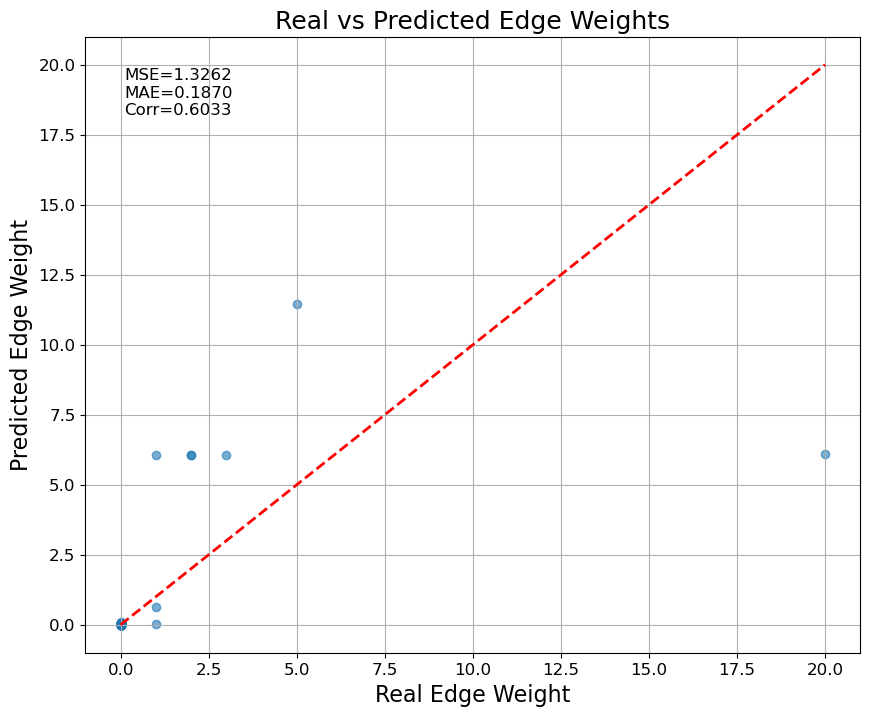

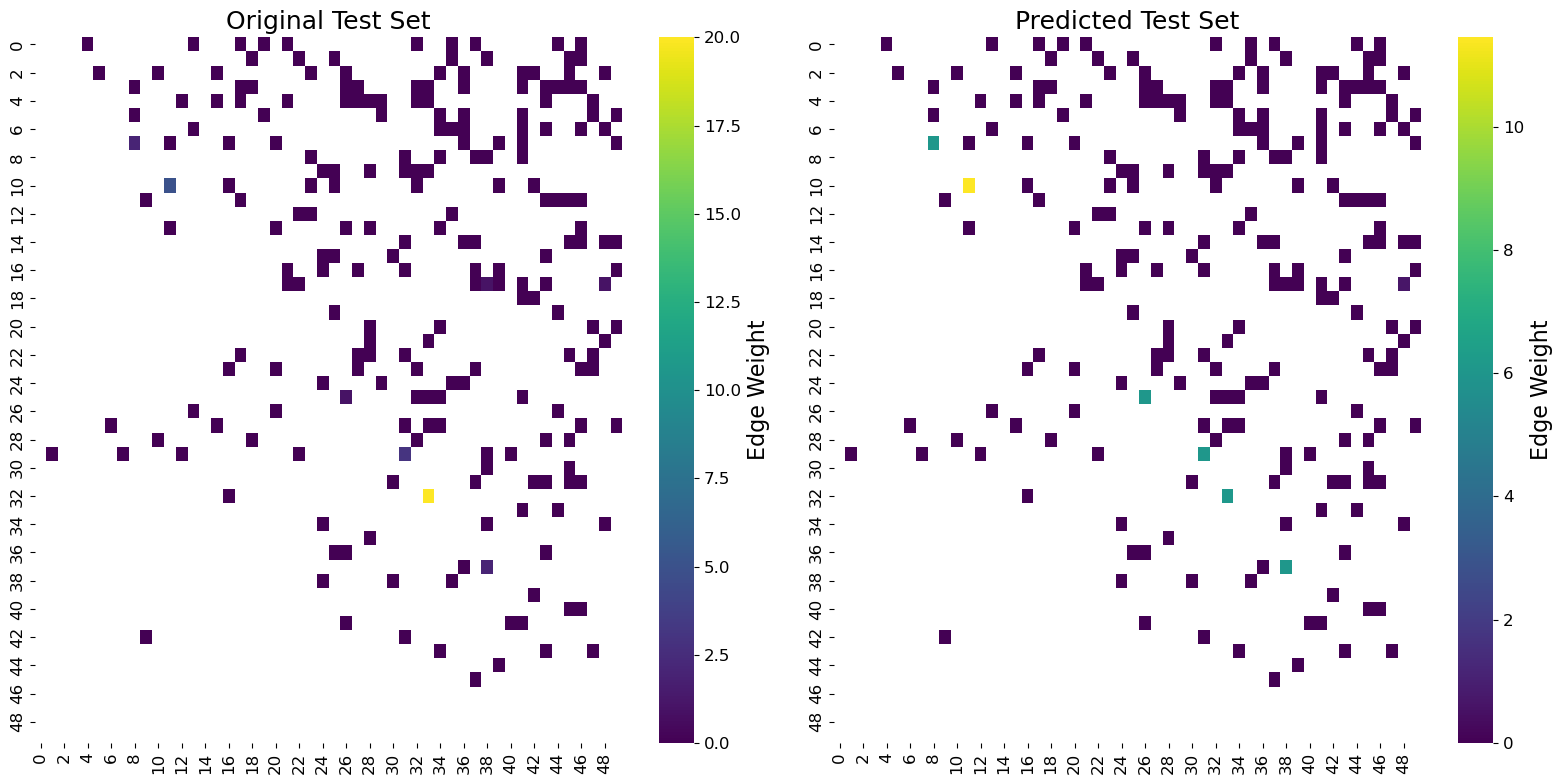

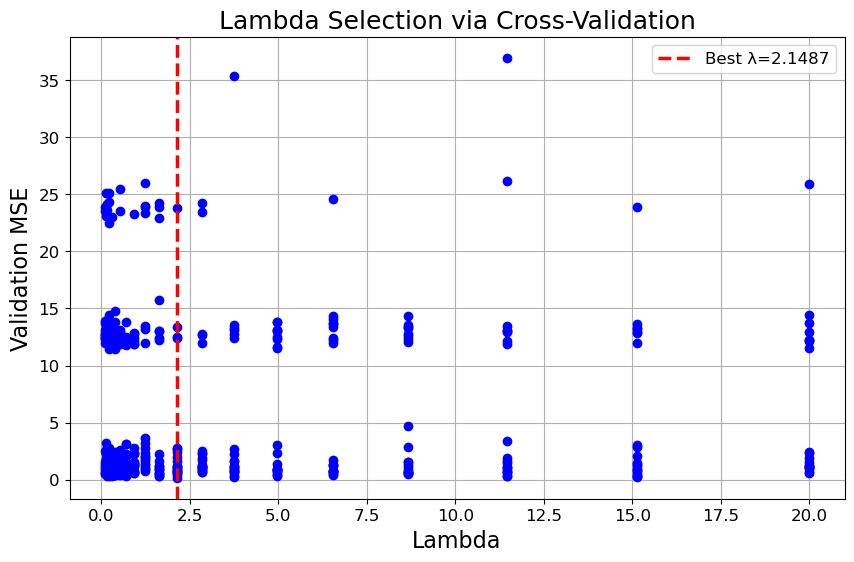

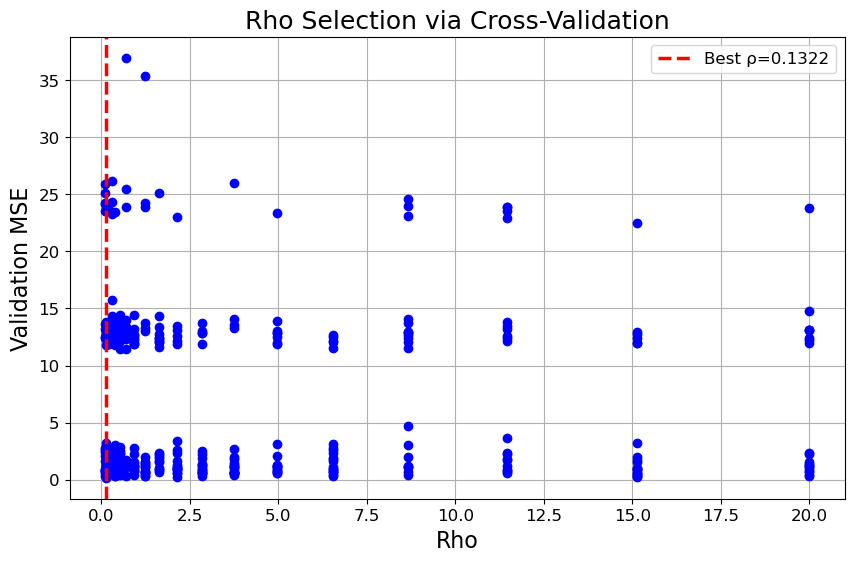

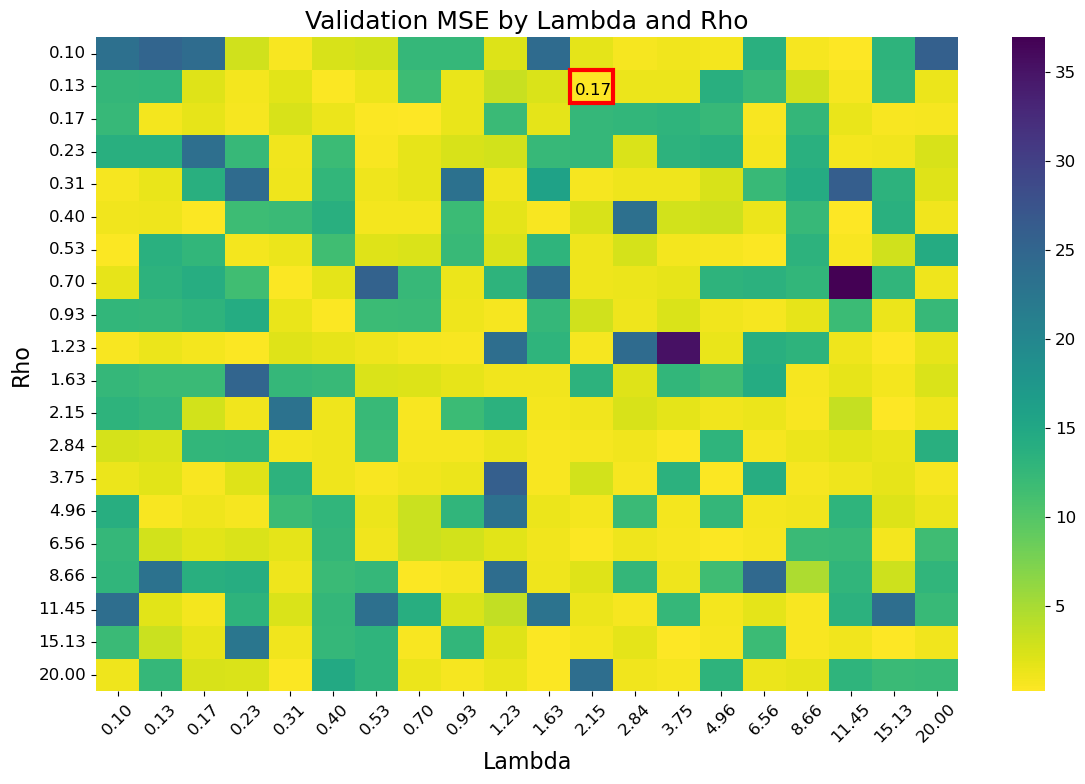

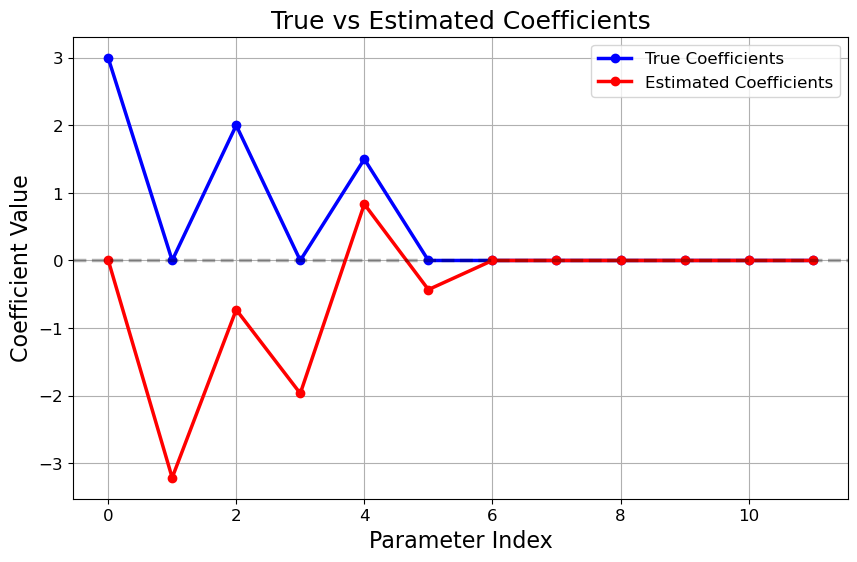

  theta = 0.0093 ± 0.1331 
  p-value = 0.9443
  95% CI = [-0.2516, 0.2702]
  theta = -3.2143 ± 0.3966 ***
  p-value = 0.0000
  95% CI = [-3.9917, -2.4370]
  theta = -0.7282 ± 0.1507 ***
  p-value = 0.0000
  95% CI = [-1.0236, -0.4329]
  theta = -1.9670 ± 0.3295 ***
  p-value = 0.0000
  95% CI = [-2.6129, -1.3212]
  theta = 0.8339 ± 0.2084 ***
  p-value = 0.0001
  95% CI = [0.4255, 1.2423]
  theta = -0.4311 ± 0.1804 *
  p-value = 0.0168
  95% CI = [-0.7846, -0.0776]
  theta = 0.0000 ± 2.7507 
  p-value = 1.0000
  95% CI = [-5.3913, 5.3913]
  theta = 0.0000 ± 2.7507 
  p-value = 1.0000
  95% CI = [-5.3913, 5.3913]
  theta = 0.0000 ± 2.7507 
  p-value = 1.0000
  95% CI = [-5.3913, 5.3913]
  theta = 0.0000 ± 2.7507 
  p-value = 1.0000
  95% CI = [-5.3913, 5.3913]
  theta = 0.0000 ± 2.7507 
  p-value = 1.0000
  95% CI = [-5.3913, 5.3913]
  theta = 0.0000 ± 2.7507 
  p-value = 1.0000
  95% CI = [-5.3913, 5.3913]
Starting 400x5=2000 CV evaluations


C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:286: RuntimeWarning: divide by zero encountered in log
  log_lik = np.sum(A_flat * np.log(p_norm))
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:286: RuntimeWarning: invalid value encountered in multiply
  log_lik = np.sum(A_flat * np.log(p_norm))
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:282: RuntimeWarning: invalid value encountered in multiply
  p = xi_flat * product
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  w

(1/400) λ=0.1000, ρ=0.1000, Val MSE=6.6632


C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:286: RuntimeWarning: divide by zero encountered in log
  log_lik = np.sum(A_flat * np.log(p_norm))
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:286: RuntimeWarning: invalid value encountered in multiply
  log_lik = np.sum(A_flat * np.log(p_norm))
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:282: RuntimeWarning: invalid value encountered in multiply
  p = xi_flat * product
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  w

(2/400) λ=0.1000, ρ=0.1322, Val MSE=0.3829


...

(399/400) λ=20.0000, ρ=15.1329, Val MSE=0.5775


C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:286: RuntimeWarning: divide by zero encountered in log
  log_lik = np.sum(A_flat * np.log(p_norm))
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:286: RuntimeWarning: invalid value encountered in multiply
  log_lik = np.sum(A_flat * np.log(p_norm))
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:286: RuntimeWarning: divide by zero encountered in log
  log_lik = np.sum(A_flat * np.log(p_norm))
C:\Users\hensh\AppData\Local\Temp\ipykernel_6717

(400/400) λ=20.0000, ρ=20.0000, Val MSE=0.8201

Training final model with λ=15.1329, ρ=6.5555
Iter 1: Obj=nan, Diff=0.700067
Iter 2: Obj=nan, Diff=0.234701
Iter 3: Obj=nan, Diff=0.069964
Iter 4: Obj=nan, Diff=0.050782
Iter 5: Obj=nan, Diff=0.040043
Iter 6: Obj=nan, Diff=0.033088
Iter 7: Obj=nan, Diff=0.028172
Iter 8: Obj=nan, Diff=0.024495
Iter 9: Obj=nan, Diff=0.021641
Iter 10: Obj=nan, Diff=0.019372
Iter 11: Obj=nan, Diff=0.017544
Iter 12: Obj=nan, Diff=0.016063
Iter 13: Obj=nan, Diff=0.014866
Iter 14: Obj=nan, Diff=0.014102
Iter 15: Obj=nan, Diff=0.013367
Iter 16: Obj=nan, Diff=0.012692
Iter 17: Obj=nan, Diff=0.012083
Iter 18: Obj=nan, Diff=0.011537
Iter 19: Obj=nan, Diff=0.011046
Iter 20: Obj=nan, Diff=0.010605
Iter 21: Obj=nan, Diff=0.010207
Iter 22: Obj=nan, Diff=0.009851
Iter 23: Obj=nan, Diff=0.009531
Iter 24: Obj=nan, Diff=0.009244
Iter 25: Obj=nan, Diff=0.008989
Iter 26: Obj=nan, Diff=0.008763
Iter 27: Obj=nan, Diff=0.008563
Iter 28: Obj=nan, Diff=0.008387
Iter 29: Obj=nan, D

C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:286: RuntimeWarning: divide by zero encountered in log
  log_lik = np.sum(A_flat * np.log(p_norm))
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:286: RuntimeWarning: invalid value encountered in multiply
  log_lik = np.sum(A_flat * np.log(p_norm))


Iter 171: Obj=nan, Diff=0.001606
Iter 172: Obj=nan, Diff=0.001645
Iter 173: Obj=nan, Diff=0.001685
Iter 174: Obj=nan, Diff=0.001726
Iter 175: Obj=nan, Diff=0.001767
Iter 176: Obj=nan, Diff=0.001808
Iter 177: Obj=nan, Diff=0.001849
Iter 178: Obj=nan, Diff=0.001890
Iter 179: Obj=nan, Diff=0.001931
Iter 180: Obj=nan, Diff=0.001972
Iter 181: Obj=nan, Diff=0.002012
Iter 182: Obj=nan, Diff=0.002052
Iter 183: Obj=nan, Diff=0.002092
Iter 184: Obj=nan, Diff=0.002131
Iter 185: Obj=nan, Diff=0.002169
Iter 186: Obj=nan, Diff=0.002207
Iter 187: Obj=nan, Diff=0.002244
Iter 188: Obj=nan, Diff=0.002280
Iter 189: Obj=nan, Diff=0.002316
Iter 190: Obj=nan, Diff=0.002350
Iter 191: Obj=nan, Diff=0.002384
Iter 192: Obj=nan, Diff=0.002416
Iter 193: Obj=nan, Diff=0.002448
Iter 194: Obj=nan, Diff=0.002479
Iter 195: Obj=nan, Diff=0.002509
Iter 196: Obj=nan, Diff=0.002538
Iter 197: Obj=nan, Diff=0.002565
Iter 198: Obj=nan, Diff=0.002592
Iter 199: Obj=nan, Diff=0.002617
Iter 200: Obj=nan, Diff=0.002642
Iter 201: 

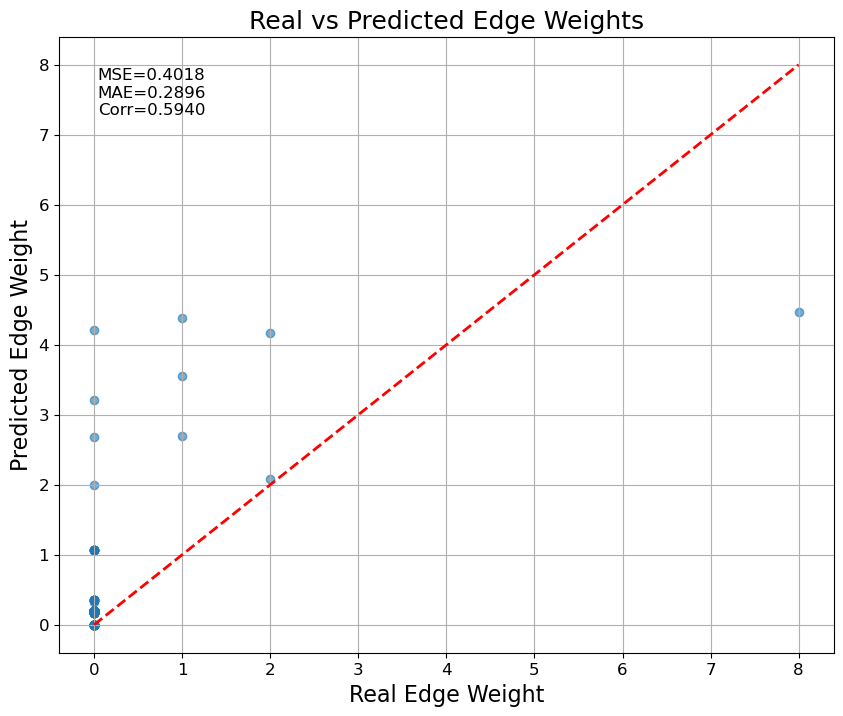

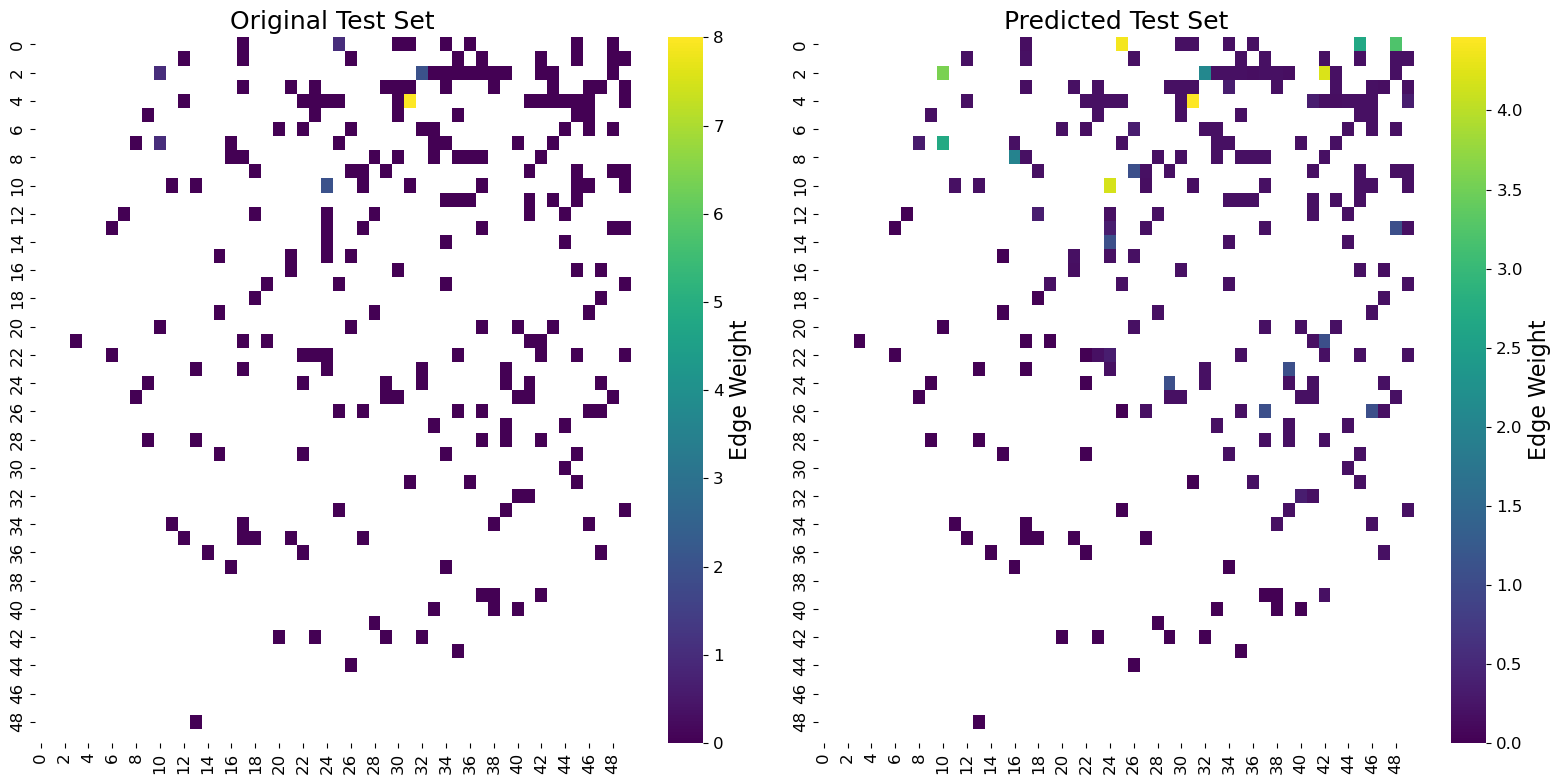

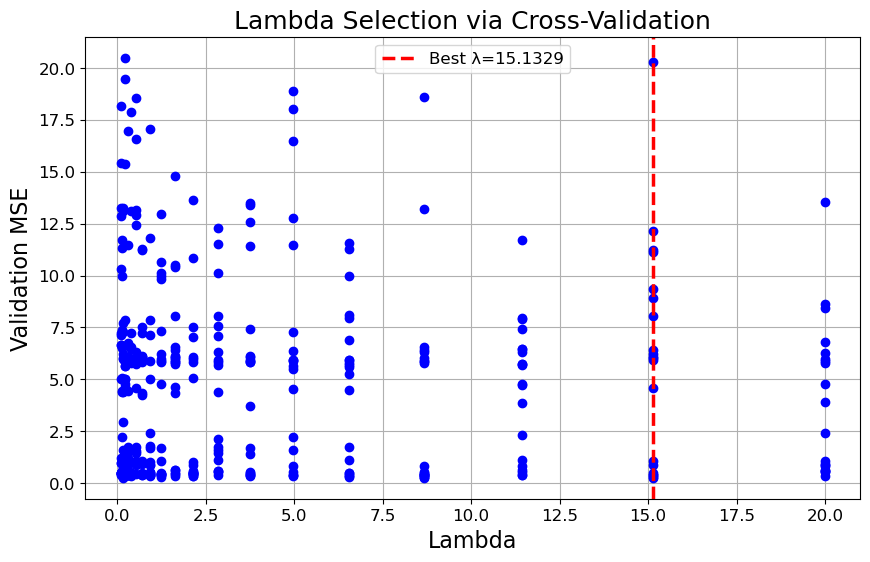

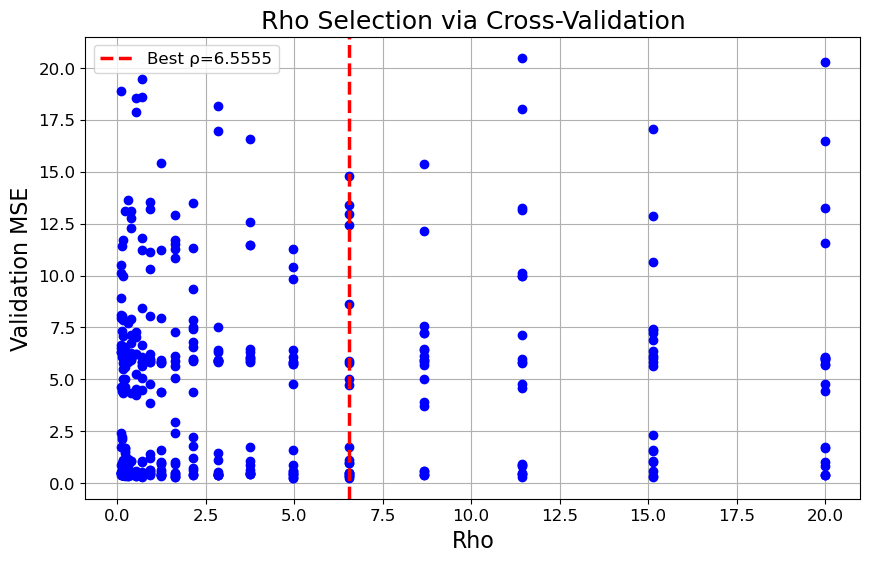

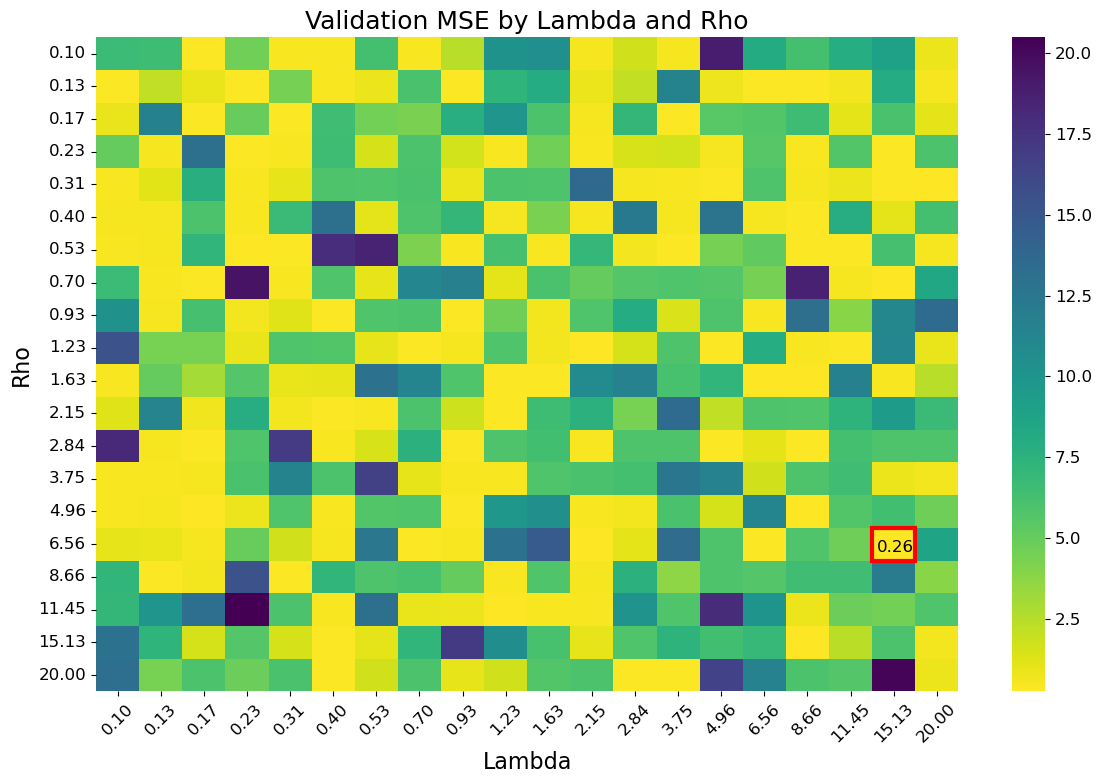

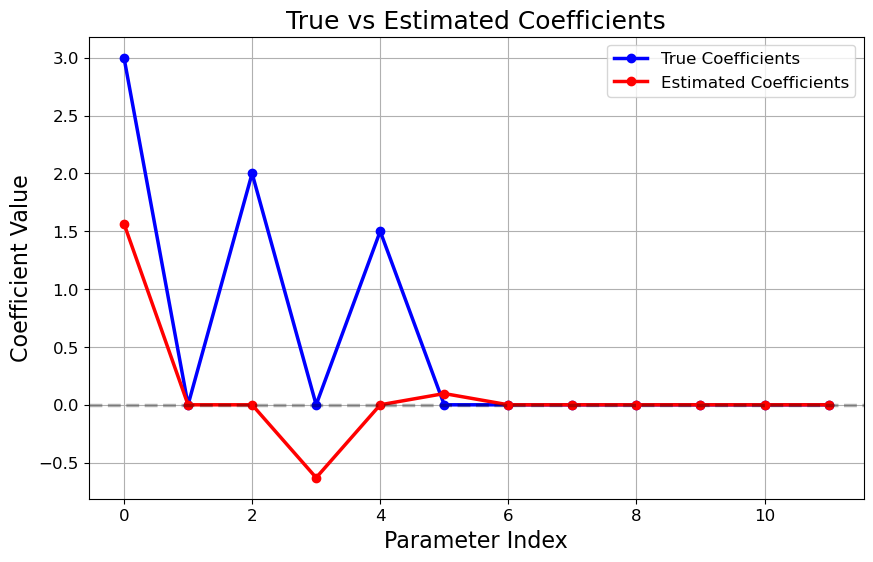

  theta = 1.5649 ± 0.2020 ***
  p-value = 0.0000
  95% CI = [1.1690, 1.9608]
  theta = 0.0000 ± 0.3247 
  p-value = 1.0000
  95% CI = [-0.6364, 0.6364]
  theta = 0.0000 ± 0.2007 
  p-value = 1.0000
  95% CI = [-0.3933, 0.3933]
  theta = -0.6304 ± 0.2864 *
  p-value = 0.0277
  95% CI = [-1.1917, -0.0690]
  theta = 0.0000 ± 0.2310 
  p-value = 1.0000
  95% CI = [-0.4528, 0.4528]
  theta = 0.0971 ± 0.2473 
  p-value = 0.6945
  95% CI = [-0.3875, 0.5817]
  theta = 0.0000 ± 0.3906 
  p-value = 1.0000
  95% CI = [-0.7655, 0.7655]
  theta = 0.0000 ± 0.3906 
  p-value = 1.0000
  95% CI = [-0.7655, 0.7655]
  theta = 0.0000 ± 0.3906 
  p-value = 1.0000
  95% CI = [-0.7655, 0.7655]
  theta = 0.0000 ± 0.3906 
  p-value = 1.0000
  95% CI = [-0.7655, 0.7655]
  theta = 0.0000 ± 0.3906 
  p-value = 1.0000
  95% CI = [-0.7655, 0.7655]
  theta = 0.0000 ± 0.3906 
  p-value = 1.0000
  95% CI = [-0.7655, 0.7655]
Starting 400x5=2000 CV evaluations


C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:283: RuntimeWarning: invalid value encountered in divide
  p_norm = p / p.sum()
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:283: RuntimeWarning: invalid value encou

(1/400) λ=0.1000, ρ=0.1000, Val MSE=0.1606


C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:283: RuntimeWarning: invalid value encountered in divide
  p_norm = p / p.sum()
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:279: RuntimeWarning: overflow encountered in power
  product *= R_safe ** theta[i]
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:283: RuntimeWarning: invalid value encou

(2/400) λ=0.1000, ρ=0.1322, Val MSE=0.2485


...

(398/400) λ=20.0000, ρ=11.4503, Val MSE=0.1457


C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarni

(399/400) λ=20.0000, ρ=15.1329, Val MSE=0.3778


C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarning: Asymmetric adjacency matrix for undirected graph. Symmetrizing...
  warnings.warn("Asymmetric adjacency matrix for undirected graph. Symmetrizing...")
C:\Users\hensh\AppData\Local\Temp\ipykernel_67172\173039272.py:64: UserWarni

(400/400) λ=20.0000, ρ=20.0000, Val MSE=0.1951

Training final model with λ=8.6638, ρ=8.6638
Iter 1: Obj=5582.2567, Diff=0.479027
Iter 2: Obj=3081.2525, Diff=0.390317
Iter 3: Obj=3038.3046, Diff=0.189495
Iter 4: Obj=3006.1066, Diff=0.148146
Iter 5: Obj=2971.2603, Diff=0.120298
Iter 6: Obj=2873.1734, Diff=0.100423
Iter 7: Obj=2855.0784, Diff=0.087259
Iter 8: Obj=2840.3228, Diff=0.076128
Iter 9: Obj=2828.0927, Diff=0.067224
Iter 10: Obj=2817.8138, Diff=0.059960
Iter 11: Obj=2809.0697, Diff=0.053941
Iter 12: Obj=2801.5515, Diff=0.048886
Iter 13: Obj=2795.0256, Diff=0.044594
Iter 14: Obj=2789.3124, Diff=0.040914
Iter 15: Obj=2784.2720, Diff=0.037734
Iter 16: Obj=2779.7938, Diff=0.034964
Iter 17: Obj=2775.7895, Diff=0.032537
Iter 18: Obj=2772.1879, Diff=0.030399
Iter 19: Obj=2768.9309, Diff=0.028504
Iter 20: Obj=2765.9707, Diff=0.026820
Iter 21: Obj=2763.2679, Diff=0.025315
Iter 22: Obj=2760.7895, Diff=0.023966
Iter 23: Obj=2758.5077, Diff=0.022753
Iter 24: Obj=2756.3993, Diff=0.021659
Iter

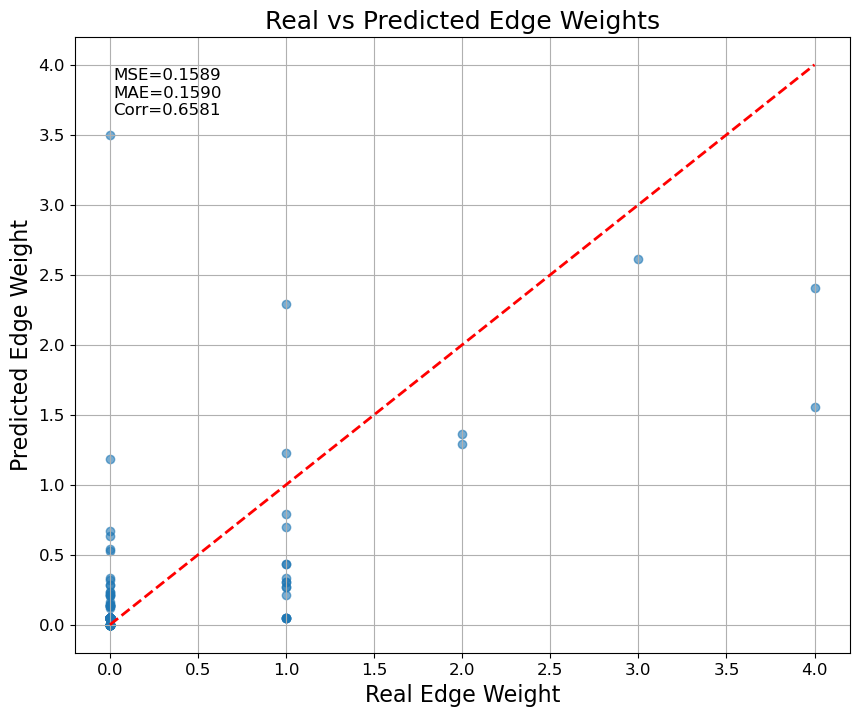

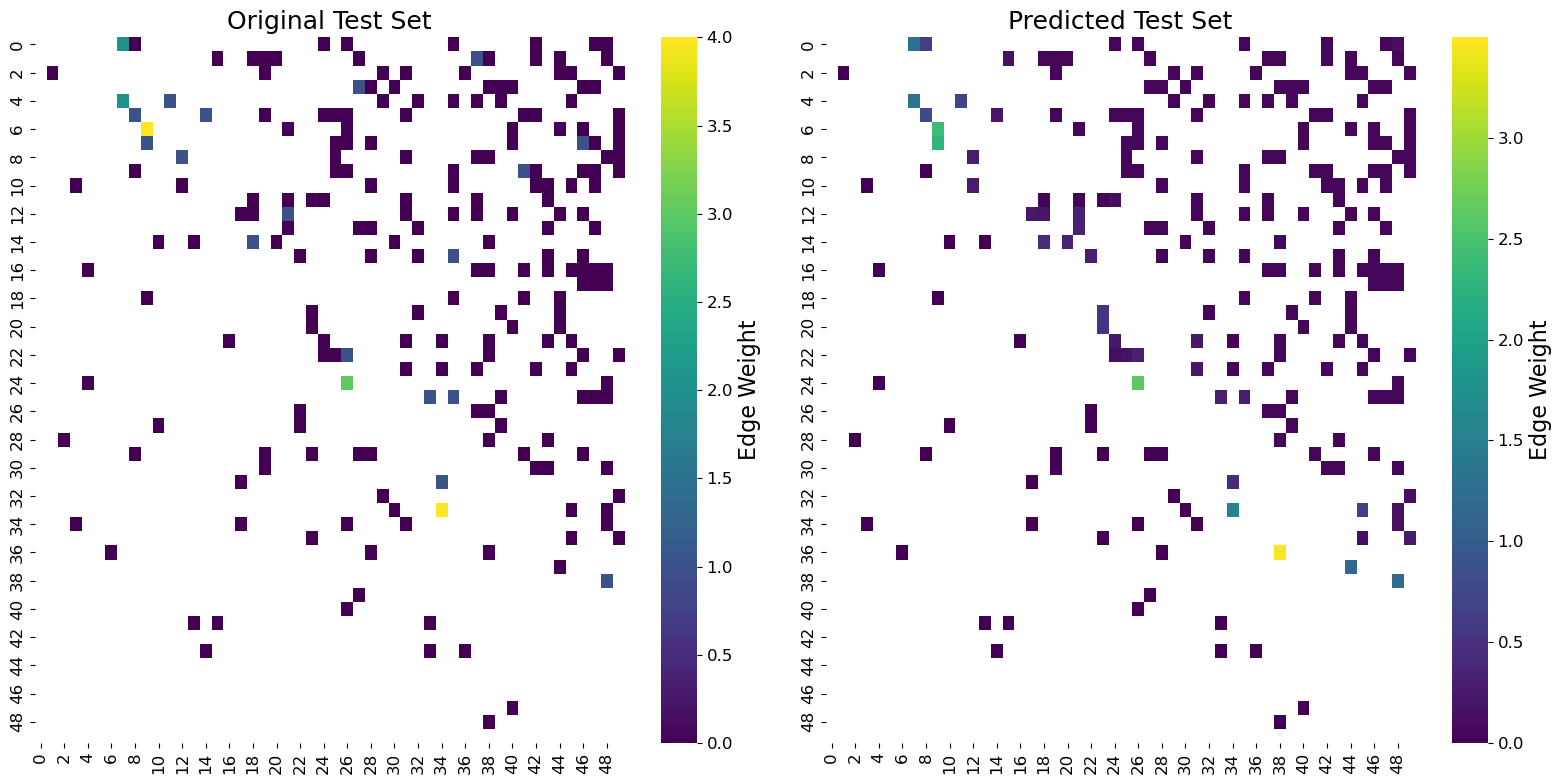

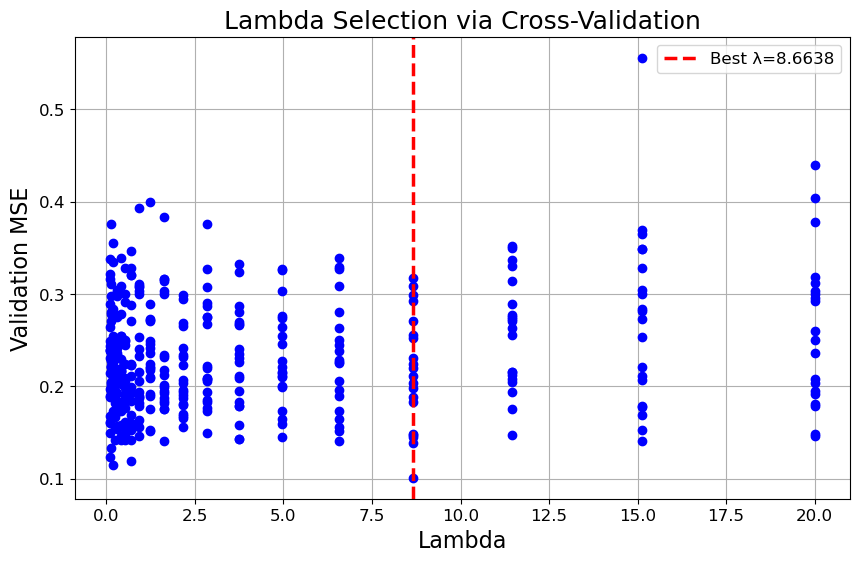

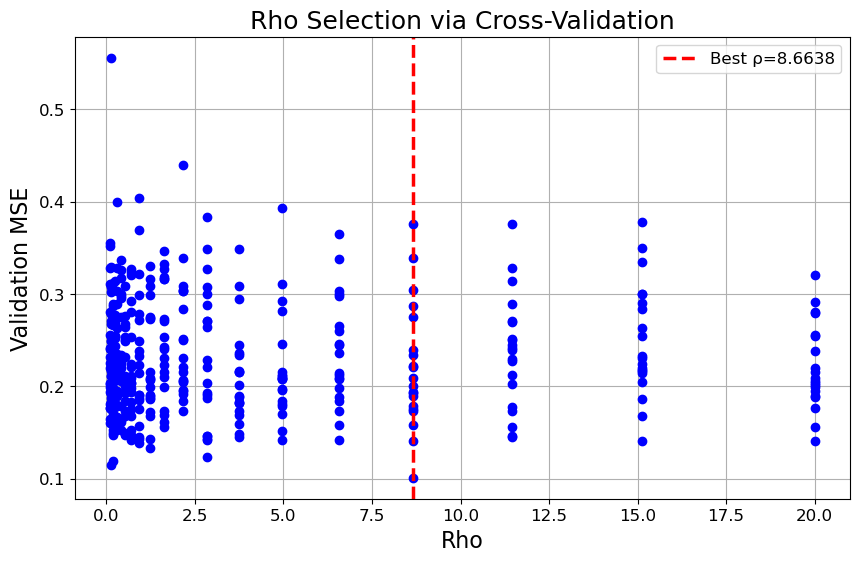

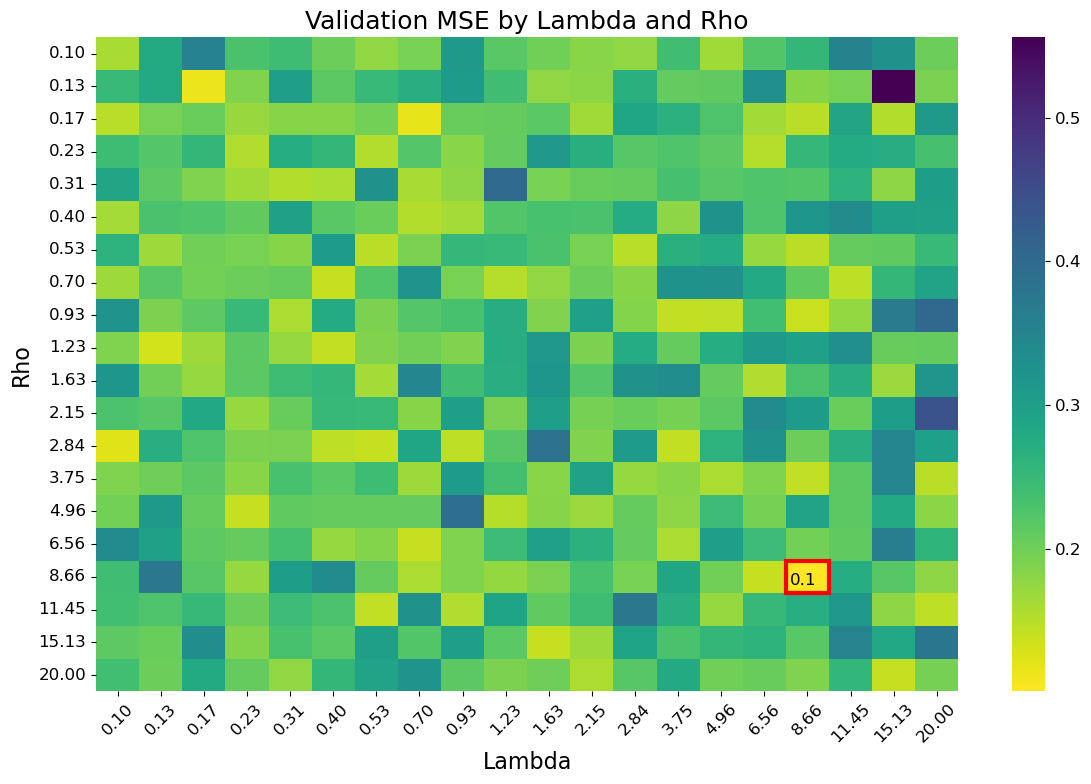

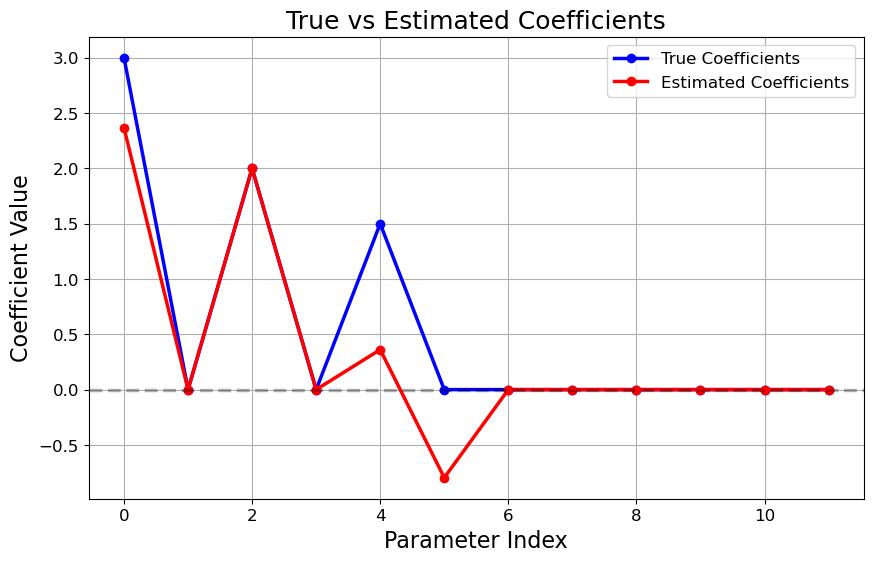

  theta = 2.3660 ± 0.1669 ***
  p-value = 0.0000
  95% CI = [2.0388, 2.6931]
  theta = 0.0000 ± 0.3397 
  p-value = 1.0000
  95% CI = [-0.6659, 0.6659]
  theta = 2.0011 ± 0.1751 ***
  p-value = 0.0000
  95% CI = [1.6579, 2.3443]
  theta = 0.0000 ± 0.3397 
  p-value = 1.0000
  95% CI = [-0.6659, 0.6659]
  theta = 0.3614 ± 0.1672 *
  p-value = 0.0307
  95% CI = [0.0337, 0.6890]
  theta = -0.7964 ± 0.1298 ***
  p-value = 0.0000
  95% CI = [-1.0509, -0.5420]
  theta = 0.0000 ± 0.3397 
  p-value = 1.0000
  95% CI = [-0.6659, 0.6659]
  theta = 0.0000 ± 0.3397 
  p-value = 1.0000
  95% CI = [-0.6659, 0.6659]
  theta = 0.0000 ± 0.3397 
  p-value = 1.0000
  95% CI = [-0.6659, 0.6659]
  theta = 0.0000 ± 0.3397 
  p-value = 1.0000
  95% CI = [-0.6659, 0.6659]
  theta = 0.0000 ± 0.3397 
  p-value = 1.0000
  95% CI = [-0.6659, 0.6659]
  theta = 0.0000 ± 0.3397 
  p-value = 1.0000
  95% CI = [-0.6659, 0.6659]


In [101]:
########################################
# Simulation scenario 4: edge prediction simulation
########################################

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
import copy
import itertools

def hide_edges(adj, hide_ratio=0.2, directed=False, selfloops=False):
    """
    Hide a certain proportion of edges in the adjacency matrix to create training and test sets
    
    Parameters:
    adj (ndarray): Original adjacency matrix
    hide_ratio (float): Proportion of edges to hide (0-1)
    directed (bool): Whether the graph is directed
    selfloops (bool): Whether to include self-loops
    
    Returns:
    dict: Contains training adjacency matrix, test mask, and test values
    """
    # Get indices of test edges
    ix = mat2vec_ix(adj, directed, selfloops)
    
    # Extract row and column indices of test edges
    edge_indices = np.where(ix)
    n_edges = len(edge_indices[0])
    
    # Randomly select edges to hide
    n_hide = int(n_edges * hide_ratio)
    hide_row_idx = np.random.choice(n_edges, n_hide, replace=False)
    hide_col_idx = np.random.choice(n_edges, n_hide, replace=False)
    
    # Create test mask
    test_mask = np.zeros_like(adj, dtype=bool)
    test_mask[edge_indices[0][hide_row_idx], edge_indices[1][hide_col_idx]] = True
    
    # Save true values of test edges
    test_values = adj[test_mask].copy()
    
    # Create training adjacency matrix (set hidden positions to 0)
    train_adj = adj.copy()
    train_adj[test_mask] = 0
    
    return {
        'train_adj': train_adj,
        'test_mask': test_mask,
        'test_values': test_values
    }

def edge_prediction(R_list, adj, xi=None, 
                    lambd_values=None, rho_values=None,
                    hide_ratio=0.2, directed=False, selfloops=False, 
                    n_folds=5, verbose=False):
    """
    Missing edge prediction process based on SMNR with dual parameter optimization
    
    Parameters:
    R_list (list): List of relation layers
    adj (ndarray): Complete adjacency matrix
    xi (ndarray): Combination matrix (optional)
    lambd_values (list): Candidate lambda sequence
    rho_values (list): Candidate rho sequence
    hide_ratio (float): Proportion of edges to hide (0-1)
    directed (bool): Whether the graph is directed
    selfloops (bool): Whether to include self-loops
    n_folds (int): Number of cross-validation folds
    verbose (bool): Whether to print progress
    
    Returns:
    dict: Contains prediction results and performance metrics
    """
    # Set default parameter sequences (log scale)
    if lambd_values is None:
        lambd_values = np.exp(np.linspace(np.log(0.1), np.log(20), 20))
    if rho_values is None:
        rho_values = np.exp(np.linspace(np.log(0.1), np.log(20), 20))
    
    # Hide edges to create test set
    hidden_data = hide_edges(adj, hide_ratio, directed, selfloops)
    train_adj = hidden_data['train_adj']
    test_mask = hidden_data['test_mask']
    test_values = hidden_data['test_values']
    
    # Compute combination matrix (if not provided)
    if xi is None:
        xi = compute_xi(train_adj, directed, selfloops)
    
    # Cross-validation to select best lambda and rho
    param_grid = list(itertools.product(lambd_values, rho_values))
    cv_results = {
        'params': param_grid,
        'mse': np.zeros(len(param_grid)),
        'lambda': [p[0] for p in param_grid],
        'rho': [p[1] for p in param_grid]
    }
    
    if verbose:
        print(f"Starting {len(param_grid)}x{n_folds}={len(param_grid)*n_folds} CV evaluations")
    
    best_mse = float('inf')
    best_params = (0, 0)
    
    for idx, (lambd, rho) in enumerate(param_grid):
        fold_mses = np.zeros(n_folds)
        
        for fold in range(n_folds):
            # Further split training set into validation set
            fold_hidden = hide_edges(train_adj, 0.2, directed, selfloops)
            fold_train_adj = fold_hidden['train_adj']
            fold_valid_mask = fold_hidden['test_mask']
            fold_valid_values = fold_hidden['test_values']
            
            # Compute combination matrix (using training set)
            fold_xi = compute_xi(fold_train_adj, directed, selfloops)
            
            # Train model with current parameters
            model = SMNR(
                R_list, 
                fold_train_adj, 
                xi=fold_xi,
                lambd=lambd,
                rho=rho,
                tolerance=1e-3,
                directed=directed,
                selfloops=selfloops,
                verbose=False
            )
            
            # Predict
            pred_adj = SMNR_predict(
                fold_train_adj,
                R_list,
                model['z'],
                directed=directed,
                selfloops=selfloops,
                method="exact"
            )
            
            # Calculate validation set MSE
            fold_mses[fold] = mean_squared_error(
                fold_valid_values, 
                pred_adj[fold_valid_mask]
            )
            
            # Free memory
            del model, pred_adj
        
        # Average MSE as performance for current parameters
        avg_mse = np.mean(fold_mses)
        cv_results['mse'][idx] = avg_mse
        
        # Track best parameters
        if avg_mse < best_mse:
            best_mse = avg_mse
            best_params = (lambd, rho)
        
        if verbose:
            print(f"({idx+1}/{len(param_grid)}) λ={lambd:.4f}, ρ={rho:.4f}, Val MSE={avg_mse:.4f}")
    
    # Unpack best parameters
    best_lambda, best_rho = best_params
    
    # Train final model with best parameters and full training set
    if verbose:
        print(f"\nTraining final model with λ={best_lambda:.4f}, ρ={best_rho:.4f}")
    
    model = SMNR(
        R_list, 
        train_adj, 
        xi=xi,
        lambd=best_lambda,
        rho=best_rho,
        directed=directed,
        selfloops=selfloops,
        verbose=verbose
    )
    
    # Final prediction
    final_pred = SMNR_predict(
        train_adj,
        R_list,
        model['z'],
        directed=directed,
        selfloops=selfloops,
        method="exact"  # Use exact method for final prediction
    )
    
    # Calculate test set performance
    pred_values = final_pred[test_mask]
    test_mse = mean_squared_error(test_values, pred_values)
    test_mae = mean_absolute_error(test_values, pred_values)
    correlation, _ = pearsonr(test_values, pred_values)
    
    # Create full prediction matrix (including known edges)
    full_pred = final_pred.copy()
    full_pred[~test_mask] = adj[~test_mask]  # Keep true values for known edges
    
    return {
        'best_model': model,
        'predictions': full_pred,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'correlation': correlation,
        'best_lambda': best_lambda,
        'best_rho': best_rho,
        'cv_results': cv_results,
        'test_mask': test_mask
    }

def plot_param_selection(results, signal_structure):
    """
    Visualize parameter selection results with heatmap
    
    Parameters:
    results (dict): Return value of edge_prediction function
    """
    cv = results['cv_results']
    
    # Create MSE matrix for heatmap
    lambdas = sorted(set(cv['lambda']))
    rhos = sorted(set(cv['rho']))
    mse_matrix = np.full((len(rhos), len(lambdas)), np.nan)
    
    for i, rho in enumerate(rhos):
        for j, lambd in enumerate(lambdas):
            idx = next((k for k, p in enumerate(cv['params']) if p == (lambd, rho)), None)
            if idx is not None:
                mse_matrix[i, j] = cv['mse'][idx]
    
    # Plot heatmap
    plt.figure(figsize=(12, 8))
    ax = sns.heatmap(
        mse_matrix, 
        annot=False, fmt=".2f",
        xticklabels=[f"{x:.2f}" for x in lambdas],
        yticklabels=[f"{y:.2f}" for y in rhos],
        cmap="viridis_r"
    )
    plt.title(f"Validation MSE by Lambda and Rho")
    plt.xlabel("Lambda")
    plt.ylabel("Rho")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Mark best parameter combination
    best_lambda_idx = lambdas.index(results['best_lambda'])
    best_rho_idx = rhos.index(results['best_rho'])
    ax.text(best_lambda_idx+0.10, best_rho_idx+0.75, round(mse_matrix[best_rho_idx, best_lambda_idx], 2))
    ax.add_patch(plt.Rectangle(
        (best_lambda_idx, best_rho_idx), 1, 1, 
        fill=False, edgecolor='red', linewidth=3)
    )
    
    plt.tight_layout()
    plt.savefig(f"Edge_Pred_validation_MSE_n{results['test_mask'].shape[0]}_{signal_structure}.png", dpi=300)
    plt.show()

def plot_prediction_results(results, adj, signal_structure):
    """
    Visualize prediction results
    
    Parameters:
    results (dict): Return value of edge_prediction function
    adj (ndarray): Original adjacency matrix
    """
    # Extract predicted and true values
    pred_values = results['predictions'][results['test_mask']]
    true_values = adj[results['test_mask']]
    
    # 1. Scatter plot of true vs predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(true_values, pred_values, alpha=0.6)
    plt.plot([min(true_values), max(true_values)], 
             [min(true_values), max(true_values)], 
             'r--', lw=2)
    plt.title(f"Real vs Predicted Edge Weights")
    plt.xlabel("Real Edge Weight")
    plt.ylabel("Predicted Edge Weight")
    plt.grid(True)
    plt.text(0.05, 0.95, 
             f"MSE={results['test_mse']:.4f}\nMAE={results['test_mae']:.4f}\nCorr={results['correlation']:.4f}", 
             transform=plt.gca().transAxes, verticalalignment='top')
    plt.savefig(f'Edge_Pred_Real_vs_Predicted_n{adj.shape[0]}_{signal_structure}.png', dpi=300)
    plt.show()
    
    # 2. Heatmap comparison of adjacency matrices
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Original test matrix
    sns.heatmap(adj, ax=axes[0], cmap='viridis', 
                cbar_kws={'label': 'Edge Weight'}, 
                mask=~results['test_mask'])
    axes[0].set_title("Original Test Set")
    
    # Predicted test matrix
    sns.heatmap(results['predictions'], ax=axes[1], cmap='viridis', 
                cbar_kws={'label': 'Edge Weight'},
                mask=~results['test_mask'])
    axes[1].set_title("Predicted Test Set")
    
    plt.tight_layout()
    plt.savefig(f'Edge_Pred_Test_Set_Matrix_n{adj.shape[0]}_{signal_structure}.png', dpi=300)
    plt.show()
    
    # 3. Lambda selection curve
    plt.figure(figsize=(10, 6))
    plt.plot(results['cv_results']['lambda'], results['cv_results']['mse'], 'bo')
    plt.axvline(x=results['best_lambda'], color='r', linestyle='--', 
                label=f'Best λ={results["best_lambda"]:.4f}')
    # plt.xscale('log')
    plt.xlabel("Lambda")
    plt.ylabel("Validation MSE")
    plt.title("Lambda Selection via Cross-Validation")
    plt.legend()
    plt.grid(True)
    plt.savefig(f'Edge_Pred_Lambda_Selection_via_CV_n{adj.shape[0]}_{signal_structure}.png', dpi=300)
    plt.show()

    # 4. Rho selection curve
    plt.figure(figsize=(10, 6))
    plt.plot(results['cv_results']['rho'], results['cv_results']['mse'], 'bo')
    plt.axvline(x=results['best_rho'], color='r', linestyle='--', 
                label=f'Best ρ={results["best_rho"]:.4f}')
    # plt.xscale('log')
    plt.xlabel("Rho")
    plt.ylabel("Validation MSE")
    plt.title("Rho Selection via Cross-Validation")
    plt.legend()
    plt.grid(True)
    plt.savefig(f'Edge_Pred_Rho_Selection_via_CV_n{adj.shape[0]}_{signal_structure}.png', dpi=300)
    plt.show()
    
    # 5. Parameter selection heatmap
    plot_param_selection(results, signal_structure)

if __name__ == "__main__":
    # Base settings
    true_theta = [3.0, 0, 2.0, 0, 1.5, 0] + [0] * 6  # 3 signal layers + 3 noise layers
    num_nodes = 50

    # 1. Simulation of block data prediction
    signal_structure = 'block'
    
    data_block = generate_multiplex_data(
        num_nodes=num_nodes,
        theta=true_theta,
        edge_factor=10,
        signal_structure=signal_structure,
        seed=42
    )

    # Run edge prediction process
    pred_results = edge_prediction(
        R_list=data_block['R_list'],
        adj=data_block['A'],
        hide_ratio=0.2,  # Hide 20% of edges
        directed=False,
        selfloops=False,
        verbose=True
    )

    # Print result summary
    print(f"\n{'='*50}")
    print("Edge Prediction Results Summary for Block Data")
    print(f"{'='*50}")
    print(f"Best lambda: {pred_results['best_lambda']:.4f}")
    print(f"Best rho: {pred_results['best_rho']:.4f}")
    print(f"Test MSE: {pred_results['test_mse']:.4f}")
    print(f"Test MAE: {pred_results['test_mae']:.4f}")
    print(f"Correlation: {pred_results['correlation']:.4f}")
    print(f"Number of non-zero coefficients: {np.sum(np.abs(pred_results['best_model']['z']) > 0.01)}")
    print(f"{'='*50}\n")

    # Visualize results
    plot_prediction_results(pred_results, data_block['A'], signal_structure)

    # Compare true parameters with estimated parameters
    true_coef = np.array(true_theta)
    est_coef = pred_results['best_model']['z']

    plt.figure(figsize=(10, 6))
    plt.plot(range(len(true_coef)), true_coef, 'bo-', label='True Coefficients')
    plt.plot(range(len(est_coef)), est_coef, 'ro-', label='Estimated Coefficients')
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    plt.xlabel("Parameter Index")
    plt.ylabel("Coefficient Value")
    plt.title("True vs Estimated Coefficients")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"Edge_Pred_True_vs_Estimated_Coefficients_n{num_nodes}_{signal_structure}.png", dpi=300)
    plt.show()

    for i, (theta_est, std_err, p_val, ci) in enumerate(zip(
        pred_results['best_model']['z'], pred_results['best_model']['std_errors'], 
        pred_results['best_model']['p_values'], pred_results['best_model']['conf_intervals']
    )):
        sig_star = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        print(f"  theta = {theta_est:.4f} ± {std_err:.4f} {sig_star}")
        print(f"  p-value = {p_val:.4f}")
        print(f"  95% CI = [{ci[0]:.4f}, {ci[1]:.4f}]")


    # 2. Simulation of small-world data prediction
    signal_structure = 'small-world'
    
    data_smallworld = generate_multiplex_data(
        num_nodes=num_nodes,
        theta=true_theta,
        edge_factor=10,
        signal_structure=signal_structure,
        small_world_k=4,
        small_world_p=0.15,
        seed=42
    )

    # Run edge prediction process
    pred_results = edge_prediction(
        R_list=data_smallworld['R_list'],
        adj=data_smallworld['A'],
        hide_ratio=0.2,  # Hide 20% of edges
        directed=False,
        selfloops=False,
        verbose=True
    )

    # Print result summary
    print(f"\n{'='*50}")
    print("Edge Prediction Results Summary for Small-world Data")
    print(f"{'='*50}")
    print(f"Best lambda: {pred_results['best_lambda']:.4f}")
    print(f"Best rho: {pred_results['best_rho']:.4f}")
    print(f"Test MSE: {pred_results['test_mse']:.4f}")
    print(f"Test MAE: {pred_results['test_mae']:.4f}")
    print(f"Correlation: {pred_results['correlation']:.4f}")
    print(f"Number of non-zero coefficients: {np.sum(np.abs(pred_results['best_model']['z']) > 0.01)}")
    print(f"{'='*50}\n")

    # Visualize results
    plot_prediction_results(pred_results, data_smallworld['A'], signal_structure)

    # Compare true parameters with estimated parameters
    true_coef = np.array(true_theta)
    est_coef = pred_results['best_model']['z']

    plt.figure(figsize=(10, 6))
    plt.plot(range(len(true_coef)), true_coef, 'bo-', label='True Coefficients')
    plt.plot(range(len(est_coef)), est_coef, 'ro-', label='Estimated Coefficients')
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    plt.xlabel("Parameter Index")
    plt.ylabel("Coefficient Value")
    plt.title("True vs Estimated Coefficients")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"Edge_Pred_True_vs_Estimated_Coefficients_n{num_nodes}_{signal_structure}.png", dpi=300)
    plt.show()

    for i, (theta_est, std_err, p_val, ci) in enumerate(zip(
        pred_results['best_model']['z'], pred_results['best_model']['std_errors'], 
        pred_results['best_model']['p_values'], pred_results['best_model']['conf_intervals']
    )):
        sig_star = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        print(f"  theta = {theta_est:.4f} ± {std_err:.4f} {sig_star}")
        print(f"  p-value = {p_val:.4f}")
        print(f"  95% CI = [{ci[0]:.4f}, {ci[1]:.4f}]")


    # 3. Simulation of scale-free data prediction
    signal_structure = 'scale-free'
    
    data_scalefree = generate_multiplex_data(
        num_nodes=num_nodes,
        theta=true_theta,
        edge_factor=10,
        signal_structure=signal_structure,
        scale_free_m=2,
        seed=42
    )

    # Run edge prediction process
    pred_results = edge_prediction(
        R_list=data_scalefree['R_list'],
        adj=data_scalefree['A'],
        hide_ratio=0.2,  # Hide 20% of edges
        directed=False,
        selfloops=False,
        verbose=True
    )

    # Print result summary
    print(f"\n{'='*50}")
    print("Edge Prediction Results Summary for Scale-free Data")
    print(f"{'='*50}")
    print(f"Best lambda: {pred_results['best_lambda']:.4f}")
    print(f"Best rho: {pred_results['best_rho']:.4f}")
    print(f"Test MSE: {pred_results['test_mse']:.4f}")
    print(f"Test MAE: {pred_results['test_mae']:.4f}")
    print(f"Correlation: {pred_results['correlation']:.4f}")
    print(f"Number of non-zero coefficients: {np.sum(np.abs(pred_results['best_model']['z']) > 0.01)}")
    print(f"{'='*50}\n")

    # Visualize results
    plot_prediction_results(pred_results, data_scalefree['A'], signal_structure)

    # Compare true parameters with estimated parameters
    true_coef = np.array(true_theta)
    est_coef = pred_results['best_model']['z']

    plt.figure(figsize=(10, 6))
    plt.plot(range(len(true_coef)), true_coef, 'bo-', label='True Coefficients')
    plt.plot(range(len(est_coef)), est_coef, 'ro-', label='Estimated Coefficients')
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    plt.xlabel("Parameter Index")
    plt.ylabel("Coefficient Value")
    plt.title("True vs Estimated Coefficients")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"Edge_Pred_True_vs_Estimated_Coefficients_n{num_nodes}_{signal_structure}.png", dpi=300)
    plt.show()

    for i, (theta_est, std_err, p_val, ci) in enumerate(zip(
        pred_results['best_model']['z'], pred_results['best_model']['std_errors'], 
        pred_results['best_model']['p_values'], pred_results['best_model']['conf_intervals']
    )):
        sig_star = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        print(f"  theta = {theta_est:.4f} ± {std_err:.4f} {sig_star}")
        print(f"  p-value = {p_val:.4f}")
        print(f"  95% CI = [{ci[0]:.4f}, {ci[1]:.4f}]")


    # 4. Simulation of mixed data prediction
    signal_structure = 'mixed'
    
    data_mixed = generate_multiplex_data(
        num_nodes=num_nodes,
        theta=true_theta,
        edge_factor=10,
        signal_structure=['block', 'small-world', 'scale-free'],
        small_world_k=4,
        small_world_p=0.20,
        scale_free_m=3,
        seed=42
    )

    # Run edge prediction process
    pred_results = edge_prediction(
        R_list=data_mixed['R_list'],
        adj=data_mixed['A'],
        hide_ratio=0.2,  # Hide 20% of edges
        directed=False,
        selfloops=False,
        verbose=True
    )

    # Print result summary
    print(f"\n{'='*50}")
    print("Edge Prediction Results Summary for Fixed Data")
    print(f"{'='*50}")
    print(f"Best lambda: {pred_results['best_lambda']:.4f}")
    print(f"Best rho: {pred_results['best_rho']:.4f}")
    print(f"Test MSE: {pred_results['test_mse']:.4f}")
    print(f"Test MAE: {pred_results['test_mae']:.4f}")
    print(f"Correlation: {pred_results['correlation']:.4f}")
    print(f"Number of non-zero coefficients: {np.sum(np.abs(pred_results['best_model']['z']) > 0.01)}")
    print(f"{'='*50}\n")

    # Visualize results
    plot_prediction_results(pred_results, data_mixed['A'], signal_structure)

    # Compare true parameters with estimated parameters
    true_coef = np.array(true_theta)
    est_coef = pred_results['best_model']['z']

    plt.figure(figsize=(10, 6))
    plt.plot(range(len(true_coef)), true_coef, 'bo-', label='True Coefficients')
    plt.plot(range(len(est_coef)), est_coef, 'ro-', label='Estimated Coefficients')
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    plt.xlabel("Parameter Index")
    plt.ylabel("Coefficient Value")
    plt.title("True vs Estimated Coefficients")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"Edge_Pred_True_vs_Estimated_Coefficients_n{num_nodes}_{signal_structure}.png", dpi=300)
    plt.show()

    for i, (theta_est, std_err, p_val, ci) in enumerate(zip(
        pred_results['best_model']['z'], pred_results['best_model']['std_errors'], 
        pred_results['best_model']['p_values'], pred_results['best_model']['conf_intervals']
    )):
        sig_star = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        print(f"  theta = {theta_est:.4f} ± {std_err:.4f} {sig_star}")
        print(f"  p-value = {p_val:.4f}")
        print(f"  95% CI = [{ci[0]:.4f}, {ci[1]:.4f}]")

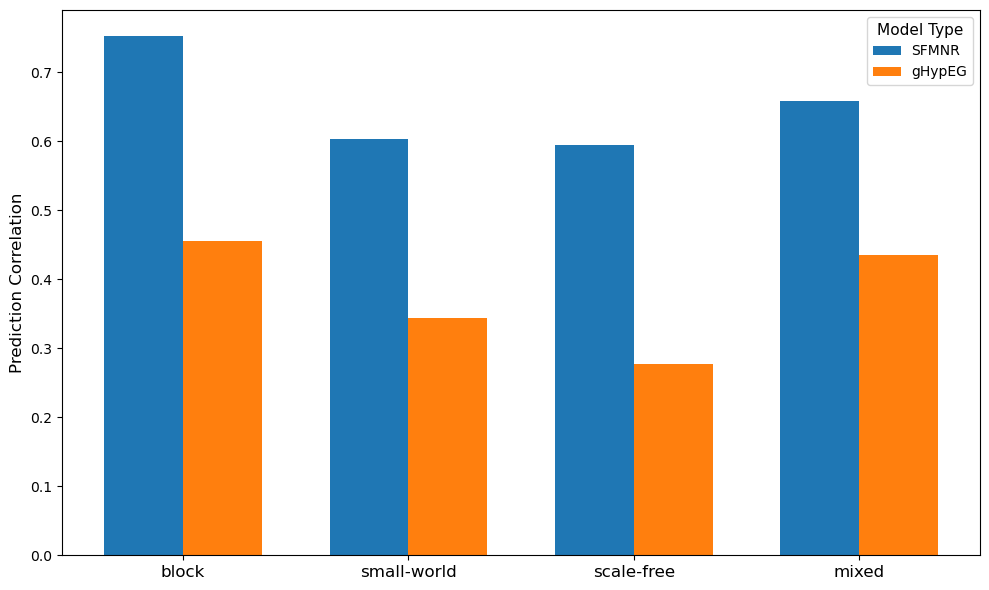

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def visualize_pred_correlation(file_path, output_filename):
    """
    Visualize edge prediction correlation results using grouped bar charts
    
    Parameters:
    file_path (str): Path to CSV file containing results data
    output_filename (str): Filename to save the generated plot
    """
    # Read data from CSV file
    df = pd.read_csv(file_path)
    
    # Prepare data for plotting
    data_types = df['data_type'].unique()
    model_types = df['model_type'].unique()
    
    # Define positions for bars
    x = np.arange(len(data_types))
    bar_width = 0.35
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Journal-quality colors (blue and orange)
    colors = ['#1f77b4', '#ff7f0e']  # SMNR: blue, gHypEG: orange
    
    # Plot bars for each model type
    for i, model in enumerate(model_types):
        model_data = df[df['model_type'] == model]
        # Ensure data is in correct order
        ordered_data = [model_data[model_data['data_type'] == dt]['pred_correlation'].values[0] 
                        for dt in data_types]
        ax.bar(x + i * bar_width, ordered_data, bar_width, 
               color=colors[i], label=model)
    
    # Add labels and title
    # ax.set_xlabel('Network Type', fontsize=12)
    ax.set_ylabel('Prediction Correlation', fontsize=12)
    
    # Set x-axis ticks and labels
    ax.set_xticks(x + bar_width/2)
    ax.set_xticklabels(data_types, fontsize=12)
    
    # Add grid and legend
    # ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend(title='Model Type', fontsize=10, title_fontsize=11)
    
    # Adjust layout and save figure
    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()

# Usage example
if __name__ == "__main__":
    # Replace with your actual file path
    input_file = "edge_prediction_correlation.csv"
    output_file = "edge_prediction_corrlation.png"
    visualize_pred_correlation(input_file, output_file)

SMNR Hyperparameter Sensitivity Analysis
Generating synthetic multiplex network...
Starting grid search over 20 x 20 = 400 configurations...
Progress: 400/400 | λ=100.0000, ρ=100.0000
Sensitivity analysis completed.


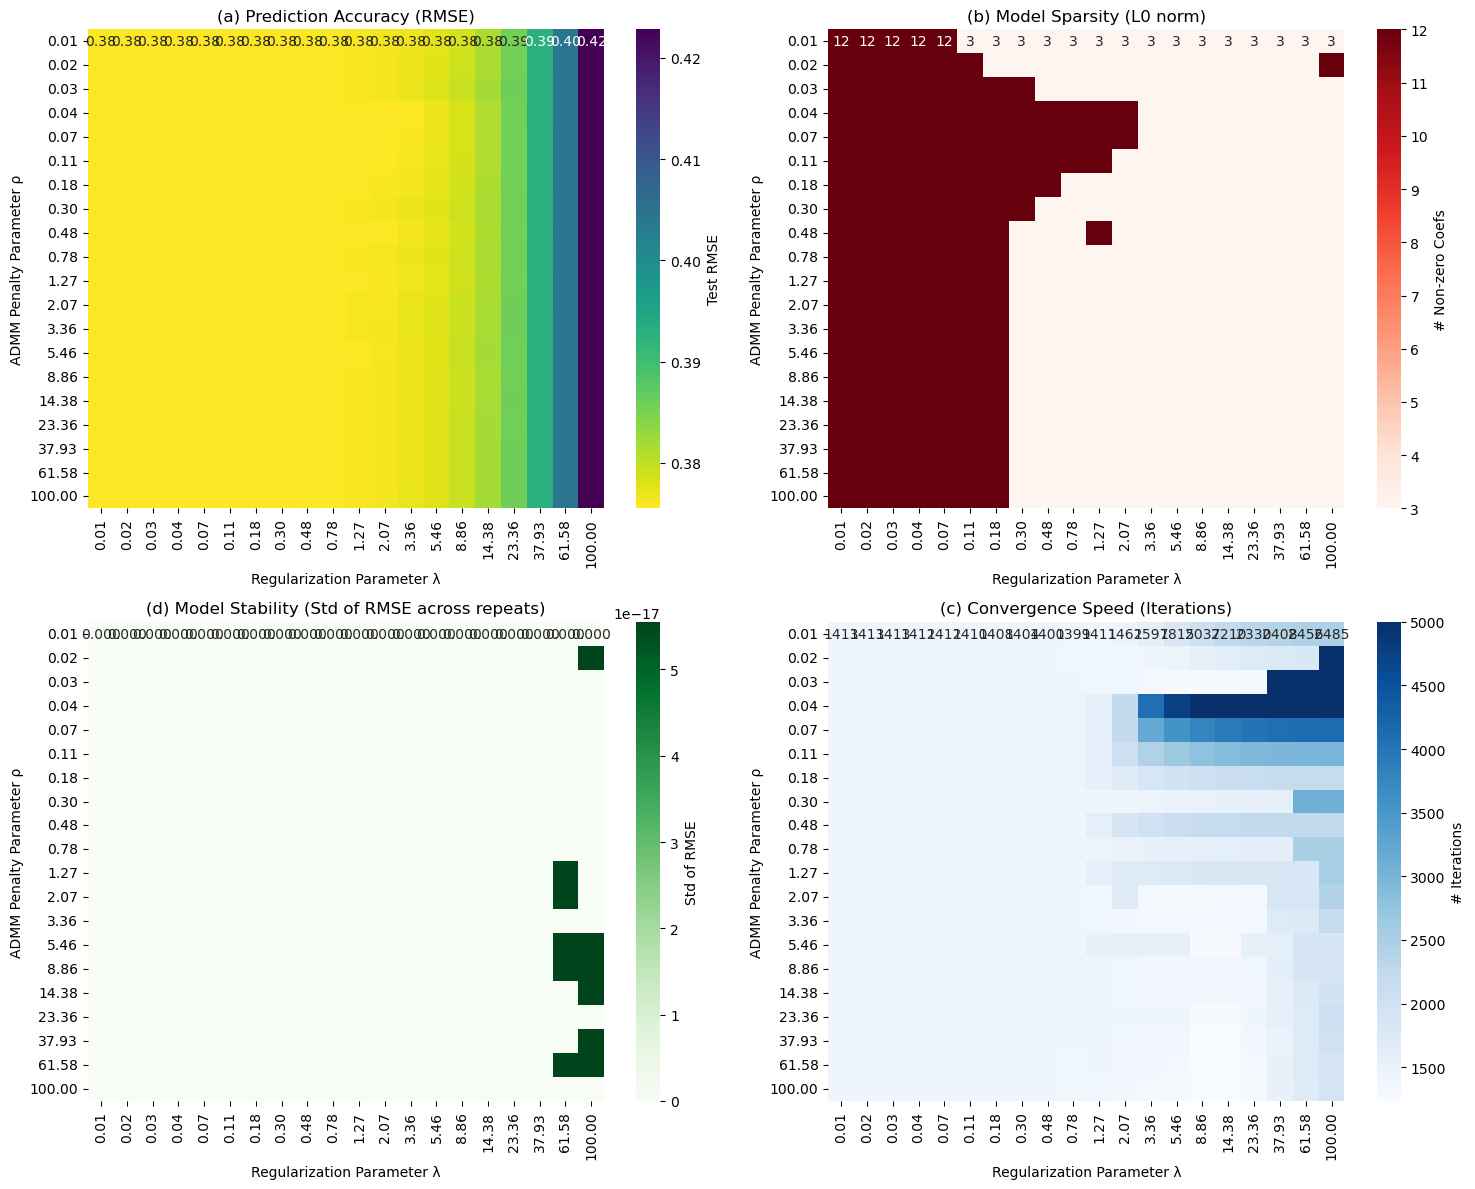

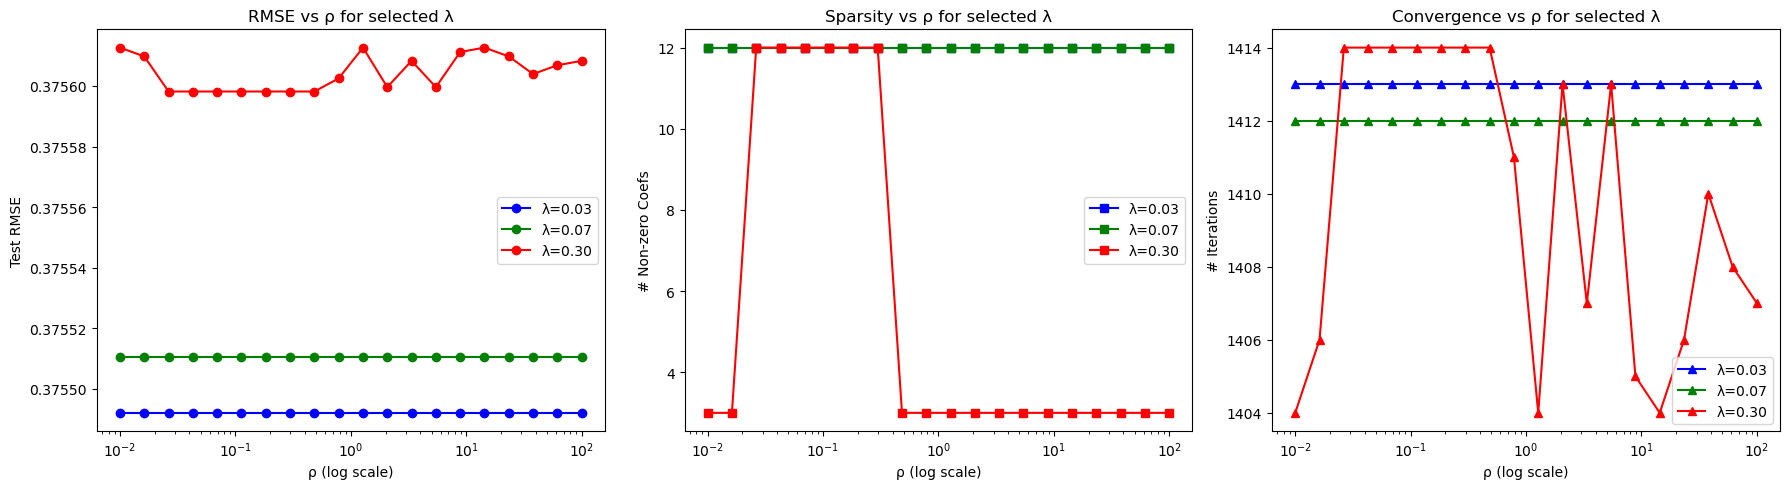


Summary Statistics for Paper:
Optimal Parameters: λ=0.0100, ρ=61.5848 (Min RMSE=0.3755)
RMSE range: [0.3755, 0.4228]
Sparsity range: [3, 12]
Iteration range: [1235, 5000]


In [67]:
"""
Hyperparameter Sensitivity Analysis for SMNR
--------------------------------------------
This script evaluates the impact of the regularization parameter lambda (λ)
and the ADMM penalty parameter rho (ρ) on model performance in terms of:
1. Prediction accuracy (RMSE on test set)
2. Model sparsity (number of non-zero coefficients)
3. Convergence speed (number of iterations to converge)
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from itertools import product
import time
import warnings
warnings.filterwarnings('ignore')


def hide_edges(adj, hide_ratio=0.2, directed=False, selfloops=False):
    """
    Hide a certain proportion of edges in the adjacency matrix to create training and test sets
    
    Parameters:
    adj (ndarray): Original adjacency matrix
    hide_ratio (float): Proportion of edges to hide (0-1)
    directed (bool): Whether the graph is directed
    selfloops (bool): Whether to include self-loops
    
    Returns:
    dict: Contains training adjacency matrix, test mask, and test values
    """
    # Get indices of test edges
    ix = mat2vec_ix(adj, directed, selfloops)
    
    # Extract row and column indices of test edges
    edge_indices = np.where(ix)
    n_edges = len(edge_indices[0])
    
    # Randomly select edges to hide
    n_hide = int(n_edges * hide_ratio)
    hide_row_idx = np.random.choice(n_edges, n_hide, replace=False)
    hide_col_idx = np.random.choice(n_edges, n_hide, replace=False)
    
    # Create test mask
    test_mask = np.zeros_like(adj, dtype=bool)
    test_mask[edge_indices[0][hide_row_idx], edge_indices[1][hide_col_idx]] = True
    
    # Save true values of test edges
    test_values = adj[test_mask].copy()
    
    # Create training adjacency matrix (set hidden positions to 0)
    train_adj = adj.copy()
    train_adj[test_mask] = 0
    
    return {
        'train_adj': train_adj,
        'test_mask': test_mask,
        'test_values': test_values
    }

def sensitivity_analysis(num_nodes=80, n_repeats=3, test_ratio=0.2):
    """
    Conduct a systematic sensitivity analysis for lambda and rho.

    Parameters:
    -----------
    num_nodes : int
        Number of nodes in the synthetic network.
    n_repeats : int
        Number of repeated runs for each parameter configuration to average out randomness.
    test_ratio : float
        Proportion of edges held out for testing.

    Returns:
    --------
    results : dict
        Contains averaged metrics for each (lambda, rho) pair.
    """
    # Define parameter grids (log-scale)
    lambd_values = np.logspace(-2, 2, 20)  # [0.01, 0.1, 1, 10, 50, 100]
    rho_values = np.logspace(-2, 2, 20)    # [0.01, 0.1, 1, 10, 50, 100]
    
    # Fixed true parameters (3 signal layers, 3 noise layers)
    true_theta = [3.0, 0, 2.0, 0, 1.5, 0] + [0] * 6
    n_layers = len(true_theta)
    
    # Store results
    results = {
        'lambda': lambd_values,
        'rho': rho_values,
        'rmse': np.zeros((len(rho_values), len(lambd_values))),
        'sparsity': np.zeros((len(rho_values), len(lambd_values))),
        'iterations': np.zeros((len(rho_values), len(lambd_values))),
        'stability_rmse': np.zeros((len(rho_values), len(lambd_values))),  # Std across repeats
    }
    
    # Generate a fixed base dataset for consistency
    print("Generating synthetic multiplex network...")
    data = generate_multiplex_data(
        num_nodes=num_nodes,
        theta=true_theta,
        edge_factor=10,
        signal_structure='block',
        seed=42
    )
    A_full = data['A']
    R_list = data['R_list']
    xi = data['xi']
    
    # Hide edges for prediction task
    hidden = hide_edges(A_full, hide_ratio=test_ratio, directed=False, selfloops=False)
    A_train = hidden['train_adj']
    test_mask = hidden['test_mask']
    test_values = hidden['test_values']
    
    # Recompute xi based on training set
    xi_train = compute_xi(A_train, directed=False, selfloops=False)
    
    print(f"Starting grid search over {len(lambd_values)} x {len(rho_values)} = {len(lambd_values)*len(rho_values)} configurations...")
    
    total_combos = len(list(product(range(len(lambd_values)), range(len(rho_values)))))
    count = 0
    
    for i, rho in enumerate(rho_values):
        for j, lambd in enumerate(lambd_values):
            count += 1
            print(f"\rProgress: {count}/{total_combos} | λ={lambd:.4f}, ρ={rho:.4f}", end="")
            
            rmse_list = []
            sparsity_list = []
            iter_list = []
            
            for rep in range(n_repeats):
                try:
                    # Train SMNR with current parameters
                    model = SMNR(
                        R_list=R_list,
                        A=A_train,
                        xi=xi_train,
                        lambd=lambd,
                        rho=rho,
                        tolerance=1e-4,
                        max_iter=5000,
                        directed=False,
                        selfloops=False,
                        verbose=False
                    )
                    
                    # Predict on test edges
                    pred_full = SMNR_predict(
                        train_adj=A_train,
                        test_R_list=R_list,
                        est_coef=model['z'],
                        directed=False,
                        selfloops=False,
                        method="exact"
                    )
                    
                    # Extract test predictions
                    pred_test = pred_full[test_mask]
                    
                    # Compute RMSE
                    rmse = np.sqrt(mean_squared_error(test_values, pred_test))
                    rmse_list.append(rmse)
                    
                    # Compute sparsity (number of non-zero coefficients)
                    sparsity = np.sum(np.abs(model['z']) > 1e-3)
                    sparsity_list.append(sparsity)
                    
                    # Store number of iterations
                    iter_list.append(model['n_iter'])
                    
                except Exception as e:
                    # Handle convergence failures or errors
                    print(f"Warning: Failed for λ={lambd}, ρ={rho} (Rep {rep}): {str(e)[:50]}")
                    rmse_list.append(np.nan)
                    sparsity_list.append(np.nan)
                    iter_list.append(np.nan)
            
            # Average results across repeats
            results['rmse'][i, j] = np.nanmean(rmse_list)
            results['sparsity'][i, j] = np.nanmean(sparsity_list)
            results['iterations'][i, j] = np.nanmean(iter_list)
            results['stability_rmse'][i, j] = np.nanstd(rmse_list)
    
    print("\nSensitivity analysis completed.")
    return results, A_full, R_list

def plot_sensitivity_results(results):
    """
    Generate heatmaps and line plots for the sensitivity analysis.
    """
    lambdas = results['lambda']
    rhos = results['rho']
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Prediction Accuracy (RMSE) Heatmap
    ax1 = axes[0, 0]
    sns.heatmap(results['rmse'], ax=ax1, cmap='viridis_r', 
                xticklabels=[f"{l:.2f}" for l in lambdas],
                yticklabels=[f"{r:.2f}" for r in rhos],
                annot=True, fmt='.2f', cbar_kws={'label': 'Test RMSE'})
    ax1.set_xlabel('Regularization Parameter λ')
    ax1.set_ylabel('ADMM Penalty Parameter ρ')
    ax1.set_title('(a) Prediction Accuracy (RMSE)')

    # 2. Sparsity (Non-zero coefficients) Heatmap
    ax2 = axes[0, 1]
    sns.heatmap(results['sparsity'], ax=ax2, cmap='Reds',
                xticklabels=[f"{l:.2f}" for l in lambdas],
                yticklabels=[f"{r:.2f}" for r in rhos],
                annot=True, fmt='.0f', cbar_kws={'label': '# Non-zero Coefs'})
    ax2.set_xlabel('Regularization Parameter λ')
    ax2.set_ylabel('ADMM Penalty Parameter ρ')
    ax2.set_title('(b) Model Sparsity (L0 norm)')

    # 3. Robustness (Std of RMSE across repeats)
    ax3 = axes[1, 0]
    sns.heatmap(results['stability_rmse'], ax=ax3, cmap='Greens',
                xticklabels=[f"{l:.2f}" for l in lambdas],
                yticklabels=[f"{r:.2f}" for r in rhos],
                annot=True, fmt='.3f', cbar_kws={'label': 'Std of RMSE'})
    ax3.set_xlabel('Regularization Parameter λ')
    ax3.set_ylabel('ADMM Penalty Parameter ρ')
    ax3.set_title('(c) Model Stability (Std of RMSE across repeats)')
    
    # 4. Convergence Speed (Iterations) Heatmap
    ax4 = axes[1, 1]
    sns.heatmap(results['iterations'], ax=ax4, cmap='Blues',
                xticklabels=[f"{l:.2f}" for l in lambdas],
                yticklabels=[f"{r:.2f}" for r in rhos],
                annot=True, fmt='.0f', cbar_kws={'label': '# Iterations'})
    ax4.set_xlabel('Regularization Parameter λ')
    ax4.set_ylabel('ADMM Penalty Parameter ρ')
    ax4.set_title('(d) Convergence Speed (Iterations)')
    
    plt.tight_layout()
    plt.savefig('./SMNR_simulation_results/SMNR_sensitivity_analysis.pdf', dpi=300)
    plt.savefig('./SMNR_simulation_results/SMNR_sensitivity_analysis.png', dpi=500)
    plt.show()
    
    # Additional line plots for specific lambda slices (to see rho effect clearly)
    fig2, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    # Select representative lambdas
    rep_lambdas = [lambdas[2], lambdas[4], lambdas[7]]  # e.g., small, medium, large
    colors = ['blue', 'green', 'red']
    
    for idx, lam in enumerate(rep_lambdas):
        lam_idx = np.where(lambdas == lam)[0][0]
        rmse_slice = results['rmse'][:, lam_idx]
        sparsity_slice = results['sparsity'][:, lam_idx]
        iter_slice = results['iterations'][:, lam_idx]
        
        axs[0].plot(rhos, rmse_slice, marker='o', color=colors[idx], label=f'λ={lam:.2f}')
        axs[1].plot(rhos, sparsity_slice, marker='s', color=colors[idx], label=f'λ={lam:.2f}')
        axs[2].plot(rhos, iter_slice, marker='^', color=colors[idx], label=f'λ={lam:.2f}')
    
    axs[0].set_xlabel('ρ (log scale)')
    axs[0].set_ylabel('Test RMSE')
    axs[0].set_title('RMSE vs ρ for selected λ')
    axs[0].legend()
    axs[0].set_xscale('log')
    
    axs[1].set_xlabel('ρ (log scale)')
    axs[1].set_ylabel('# Non-zero Coefs')
    axs[1].set_title('Sparsity vs ρ for selected λ')
    axs[1].legend()
    axs[1].set_xscale('log')
    
    axs[2].set_xlabel('ρ (log scale)')
    axs[2].set_ylabel('# Iterations')
    axs[2].set_title('Convergence vs ρ for selected λ')
    axs[2].legend()
    axs[2].set_xscale('log')
    
    plt.tight_layout()
    plt.savefig('./SMNR_simulation_results/SMNR_sensitivity_lineplots.pdf', dpi=300)
    plt.savefig('./SMNR_simulation_results/SMNR_sensitivity_lineplots.png', dpi=500)
    plt.show()

if __name__ == "__main__":
    # Run sensitivity analysis
    print("="*60)
    print("SMNR Hyperparameter Sensitivity Analysis")
    print("="*60)
    
    # Use moderate network size to balance computation and insight
    res, A, R = sensitivity_analysis(num_nodes=80, n_repeats=5)
    
    # Generate publication-quality figures
    plot_sensitivity_results(res)
    
    # Print summary statistics for the paper
    print("\n" + "="*60)
    print("Summary Statistics for Paper:")
    print("="*60)
    
    # Find optimal parameters based on RMSE
    min_rmse_idx = np.unravel_index(np.nanargmin(res['rmse']), res['rmse'].shape)
    best_rho = res['rho'][min_rmse_idx[0]]
    best_lambda = res['lambda'][min_rmse_idx[1]]
    min_rmse = res['rmse'][min_rmse_idx]
    
    print(f"Optimal Parameters: λ={best_lambda:.4f}, ρ={best_rho:.4f} (Min RMSE={min_rmse:.4f})")
    print(f"RMSE range: [{np.nanmin(res['rmse']):.4f}, {np.nanmax(res['rmse']):.4f}]")
    print(f"Sparsity range: [{np.nanmin(res['sparsity']):.0f}, {np.nanmax(res['sparsity']):.0f}]")
    print(f"Iteration range: [{np.nanmin(res['iterations']):.0f}, {np.nanmax(res['iterations']):.0f}]")